# 12. Macro Financial Conditions Index and Macro-Regime Allocation

**Main things we build in this project:**

- A real-time macro signal stack where every raw macro series is transformed into a comparable stress-oriented signal.
- A set of economic blocks for **inflation**, **policy/rates**, **growth**, **labor**, **housing**, **external trade**, and **macro breadth/conflict**.
- Several Financial Conditions Index models: an economic-weighted index, a PCA index, a supervised PLS index, a stress-probability index, and a blended index.
- A validation layer that checks whether tighter financial conditions actually line up with future equity stress, higher future volatility, and worse drawdowns.
- A sector-regime study that connects macro conditions to sector behavior instead of treating sector rotation as pure momentum.
- A macro-gated allocation strategy where the FCI changes the risky/defensive split and macro blocks change which sectors are preferred.
- A secondary Canada implementation through the library, using Canadian macro data and Canadian sector ETFs.

This project is mainly about **turning macro data into a tradable state variable**. A single inflation number or unemployment number doesn't tell us enough by itself. Markets react to combinations: inflation plus policy, growth plus labor, housing plus rates, domestic demand plus external demand, and whether stress is narrow or spreading across the system.

A Financial Conditions Index, or FCI, tries to compress that large macro state into a smaller signal. In this project, higher FCI values mean **tighter / more stressful conditions**. Lower values mean easier conditions, stronger risk support, or at least less macro pressure. The important part is that we don't use one black-box index only. We build the index from interpretable blocks first, then compare several ways of combining those blocks.

The goal is to make the macro signal teachable, testable, and usable.


## 1) The Macro Object We Want to Build

The object we want is a monthly signal that summarizes how difficult the economic environment is for risk assets. We can write the raw macro panel as:

$$
X_t = \begin{bmatrix}x_{1,t} & x_{2,t} & \cdots & x_{N,t}\end{bmatrix}
$$

where each $x_{i,t}$ is one raw macro series at month $t$. One series might be CPI inflation, another might be the unemployment rate, another might be industrial production, and another might be a yield or policy rate.

The problem is that these variables live in different units. CPI might be an index, fed funds is a percentage rate, jobless claims are people, oil is dollars per barrel, and a confidence survey may have its own scale. We can’t average them directly. We first need to transform each series into a common language.

That common language is a **real-time z-score**:

$$
z_{i,t}=\frac{x_{i,t}-\bar{x}_{i,t}^{\text{expanding}}}{s_{i,t}^{\text{expanding}}}
$$

Here $\bar{x}_{i,t}^{\text{expanding}}$ is the mean of series $i$ using only data available up to month $t$, and $s_{i,t}^{\text{expanding}}$ is the corresponding expanding standard deviation. A value of $z_{i,t}=2$ means the current observation is about two historical standard deviations above its own past normal level.

The real-time part matters. We don't compute the mean and standard deviation using the full sample, because that would let the future define the past. A macro index built for trading has to use information that would've been known at the time.


### Macro Transmission Into Asset Prices

A macro variable matters for a portfolio only if it changes cash flows, discount rates, risk premia, or liquidity. A simple present-value formula makes this connection clear:

$$
P_t=\sum_{h=1}^{\infty}\frac{E_t[CF_{t+h}]}{(1+r_{f,t,h}+\lambda_{t,h})^h}
$$

where $P_t$ is the asset price, $CF_{t+h}$ is the future cash flow, $r_{f,t,h}$ is the risk-free discount rate for horizon $h$, and $\lambda_{t,h}$ is the risk premium investors demand for bearing uncertainty. Macro conditions enter both the numerator and the denominator.

Inflation and policy mainly push through the denominator. Higher inflation can raise expected policy rates and bond yields, so $r_f$ rises. Recession risk and credit stress mainly push through both parts: expected cash flows fall and the risk premium $\lambda$ rises. Labor and housing affect consumer income, credit losses, and domestic demand. External trade affects exporters, commodities, the dollar, and global earnings.

This is why the project doesn't treat macro data as decoration. The FCI is a way to summarize whether the macro environment is raising the discount-rate burden, weakening cash-flow expectations, or increasing the required risk premium.


### Stress Orientation

After standardization, we also need a sign convention. In this project, **higher means more stress**.

That convention is straightforward for variables like unemployment, jobless claims, inflation pressure, and policy rates. Higher values usually mean more macro pressure. For variables like industrial production, retail sales, payroll growth, housing activity, and confidence surveys, the direction is reversed. Higher growth is good, so lower growth is the stressful state.

For a raw series where high values are stressful, we keep the sign:

$$
s_{i,t}=z_{i,t}
$$

For a raw series where low values are stressful, we flip it:

$$
s_{i,t}=-z_{i,t}
$$

The final $s_{i,t}$ is a stress-oriented macro signal. This lets us compare inflation, labor, housing, and growth in the same direction.

A useful example is industrial production. If industrial production is far above its historical expanding mean, the raw z-score is positive. But strong production isn't recession stress, so the stress signal is negative. If production collapses during a recession, the raw z-score becomes negative and the stress signal becomes positive. That positive value then lines up with other stress variables like rising claims or falling surveys.


### A Small Numerical Example of Stress Orientation

Suppose an industrial production series has an expanding mean of 100 and an expanding standard deviation of 5. If the latest value is 110, the raw z-score is:

$$
z_t=\frac{110-100}{5}=2
$$

But industrial production being two standard deviations above normal is usually not recession stress. For a growth variable, we flip the sign:

$$
s_t^{growth}=-2
$$

Now suppose a few months later industrial production falls to 90. The raw z-score is:

$$
z_t=\frac{90-100}{5}=-2
$$

After the sign flip:

$$
s_t^{growth}=2
$$

That positive value now means growth stress. The same stress orientation lets us average growth weakness with labor weakness, housing weakness, and policy pressure. Without the sign convention, the FCI would mix variables where positive means good with variables where positive means bad, and the index would become economically confused.


## 2) Setup and Reused Data Layer

The first code cells load the scientific Python stack, the project library, and the plotting settings. This part doesn't need heavy interpretation. The important thing is that the project works at two frequencies:

- **Monthly macro frequency**, where the raw economic indicators are transformed into macro signals and FCI models.
- **Daily or monthly market frequency**, where ETF prices are used for allocation and performance testing.

For reproducibility, the data should be understood through the repo’s data-generation folders, not as isolated final files. Check the relevant folders inside the repo’s [data folder](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data). For this project, the important folders are the ones corresponding to the US macro factors, NFCI, sector ETFs, core cross-asset ETFs, Canadian macro factors, Canadian sector ETFs, and international hedging ETFs.

The sector and cross-asset ETF data has already appeared earlier in the series, so we keep it short here. The new and important part is the macro panel: what each group measures, how it becomes a stress signal, and how those signals are turned into regimes.


In [14]:
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from scipy.stats import spearmanr
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.portfolio import make_rebalance_dates, prices_to_returns
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.portfolio.selection import build_metrics_table, build_trade_table, calc_drawdown
from quantfinlab.risk import drawdown_series
from quantfinlab.fixed_income.term_models import estimate_pca_curve
from quantfinlab.plotting.portfolio import plot_strategy_nav, plot_strategy_drawdowns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
          "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
if cycler is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})


In [15]:
factor_path = "../data/us_macro_factors.csv"
etf_paths = ["../data/sector_etfs.csv", "../data/core_cross_asset_etfs.csv"]
nfci_path = "../data/nfci.csv"
rf_annual = 0.04
rf_monthly = (1.0 + rf_annual) ** (1.0 / 12.0) - 1.0


In [16]:
macro_factors = pd.read_csv(factor_path, parse_dates=["date"]).set_index("date")
macro_factors = macro_factors.sort_index()
macro_factors.index = macro_factors.index.to_period("M").to_timestamp("M")
macro_factors = macro_factors.groupby(macro_factors.index).last()
macro_factors = macro_factors.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
minimum_visible_date = macro_factors.index.min()
factor_availability = pd.DataFrame({
    "first_date": macro_factors.apply(pd.Series.first_valid_index),
    "last_date": macro_factors.apply(pd.Series.last_valid_index),
    "observations": macro_factors.notna().sum(),
    "available_share": macro_factors.notna().mean(),
}).sort_values(["first_date", "observations"])
display(pd.DataFrame({"start": [macro_factors.index.min()], "end": [macro_factors.index.max()], "rows": [len(macro_factors)], "factors": [macro_factors.shape[1]]}))
display(factor_availability.head(20))


,start,end,rows,factors
0,1990-01-31,2026-01-31,433,56


,first_date,last_date,observations,available_share
exp_exports_goods_services,1990-01-31,2014-03-31,291,0.672055
imp_imports_goods_services,1990-01-31,2014-03-31,291,0.672055
cnci_oecd_consumer_confidence,1990-01-31,2024-03-31,411,0.949192
bsi_oecd_business_confidence,1990-01-31,2024-03-31,411,0.949192
cpc_core_cpi,1990-01-31,2026-01-31,433,1.000000
cpc_pce_price,1990-01-31,2026-01-31,433,1.000000
cpc_core_pce,1990-01-31,2026-01-31,433,1.000000
ppi_all_commodities,1990-01-31,2026-01-31,433,1.000000
ppi_final_demand,1990-01-31,2026-01-31,433,1.000000
ipp_import_price_all,1990-01-31,2026-01-31,433,1.000000


The raw macro factor panel runs from **January 1990 to January 2026**, with **433 monthly rows** and **56 macro factors**. That is a long enough span to include the early 1990s cycle, the dot-com recession, the 2008 crisis, the COVID shock, the 2022 inflation/rate shock, and the post-2023 normalization period.

The availability table tells us that not every series has the same sample. Some external trade series end in 2014. Some OECD survey series end in 2024. Many core macro series, such as CPI/PCE, PPI, import prices, oil, fed funds, and Treasury yields, run through 2026. This is why the project later builds block-level averages and coverage checks rather than requiring every raw input to be present at every date.

This is realistic macro data behavior. Macro datasets are messy because agencies revise series, discontinue series, add new survey formats, and report different variables at different frequencies. The goal isn’t to force a perfectly rectangular panel; the goal is to build a robust index that can still work when some inputs are unavailable.


### Timing, Revisions, and Real-Time Discipline

Macro data has a timing problem that price data usually doesn't have. Many macro variables are released with delays, then revised later. A payroll number, CPI print, GDP estimate, or retail-sales value may be different in the first release than in the final database. This project doesn't fully reconstruct historical release calendars, but it still keeps an important real-time discipline: transformations use expanding history and allocation features are shifted before trading.

The expanding z-score prevents future distribution information from entering past signals. The one-month shift before allocation prevents the strategy from using a same-month macro reading as if it were known at the rebalance. That is a practical compromise for a notebook project.

A fully production-grade macro strategy would go further. It would use vintage macro data, release timestamps, nowcasting rules, and publication lags. But even without that, the project is much safer than computing full-sample z-scores and immediately trading same-month signals.

This timing discipline is why the strategy interpretation is more credible. The FCI isn't just a historical chart; it is built in a way that approximates how a real investor could've used the information.


## 3) Real-Time Standardization Functions

Before building the macro blocks, we define a small transformation toolkit.

The most important function is the expanding z-score. For a series $x_t$, the expanding mean and variance at time $t$ are:

$$
\bar{x}_t=\frac{1}{t}\sum_{j=1}^{t}x_j
$$

$$
s_t^2=\frac{1}{t-1}\sum_{j=1}^{t}(x_j-\bar{x}_t)^2
$$

The standardized value is:

$$
z_t=\frac{x_t-\bar{x}_t}{s_t}
$$

The implementation requires a minimum number of observations before the score is trusted. In this project the main US run uses a 60-month warmup, so the first valid score needs about five years of history. The score is also clipped, usually inside $[-5,5]$, because macro outliers can otherwise dominate an average. A pandemic collapse or oil shock is real information, but a single extreme value shouldn't numerically drown every other variable in the block.

Two additional operations matter:

- **Level pressure**, where we standardize the level of a variable.
- **Impulse pressure**, where we standardize the recent change.

For a three-month change:

$$
\Delta_3 x_t=x_t-x_{t-3}
$$

and its stress score is the expanding z-score of $\Delta_3 x_t$, possibly with a sign flip. This is how we separate a variable being high from a variable getting worse quickly.


### Level, Impulse, Acceleration, and Diffusion

Many macro regimes are defined by both level and speed. Inflation at 4% is different if it is falling from 8% versus rising from 2%. Growth that is weak but improving is different from growth that is strong but decelerating fast.

That is why we build several signal types:

| Signal type | Mathematical object | Economic meaning |
|---|---|---|
| **Level** | $z(x_t)$ | Is the variable high or low relative to its own history? |
| **Impulse** | $z(x_t-x_{t-3})$ | Has the variable moved unusually over the last three months? |
| **Acceleration** | $z((x_t-x_{t-3})-(x_{t-3}-x_{t-6}))$ | Is the recent change itself speeding up or cooling? |
| **Diffusion** | share of variables above a stress threshold | Is stress broad across many indicators or concentrated in a few? |

The diffusion idea is especially important. A single inflation series can spike because of one component. A broad inflation regime means many price measures are elevated together. Formally, if we have $N$ stress-oriented indicators inside a group, the diffusion share is:

$$
d_t=\frac{1}{N_t}\sum_{i=1}^{N_t}\mathbf{1}\{s_{i,t}>c\}
$$

where $c$ is the threshold, here around $0.5$, and $N_t$ is the number of available series at month $t$. The diffusion share is then standardized through time. High diffusion means stress is not just intense; it is broad.


In [17]:
def expanding_zscore(series, min_obs=60, clip=5.0):
    series = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    mean = series.expanding(min_periods=min_obs).mean()
    std = series.expanding(min_periods=min_obs).std(ddof=1).replace(0.0, np.nan)
    z = (series - mean) / std
    return z.clip(-clip, clip) if clip is not None else z

def prefix_cols(data, prefixes):
    prefixes = tuple(prefixes)
    return [col for col in data.columns if col.startswith(prefixes)]

def mean_z(data, columns, min_obs=60, sign=1.0):
    if len(columns) == 0:
        return pd.Series(np.nan, index=data.index)
    z = data[columns].apply(lambda s: expanding_zscore(s, min_obs=min_obs))
    return sign * z.mean(axis=1, skipna=True)

def change_z(data, columns, periods=3, min_obs=60, sign=1.0):
    if len(columns) == 0:
        return pd.Series(np.nan, index=data.index)
    z = data[columns].diff(periods).apply(lambda s: expanding_zscore(s, min_obs=min_obs))
    return sign * z.mean(axis=1, skipna=True)

def stress_share(data, columns, min_obs=60, threshold=0.5, sign=1.0):
    if len(columns) == 0:
        return pd.Series(np.nan, index=data.index)
    z = data[columns].apply(lambda s: expanding_zscore(s, min_obs=min_obs))
    events = sign * z > threshold
    share = events.where(z.notna()).mean(axis=1, skipna=True)
    return expanding_zscore(share, min_obs=min_obs)

def plot_signal_group(data, title, ncols=2):
    cols = list(data.columns)
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 2.6 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(cols):
        series = data[col].loc[data.index >= minimum_visible_date].dropna()
        series.plot(ax=axes[i], lw=1.2, color=colors[i % len(colors)])
        axes[i].axhline(0.0, color="black", lw=0.7, alpha=0.4)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel("")
        axes[i].grid(True, alpha=0.25)
    for ax in axes[len(cols):]:
        ax.set_axis_off()
    fig.suptitle(title, y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()
    return fig, axes


## 4) Macro Factor Groups

The macro panel is divided into economically meaningful groups. This grouping is one of the most important design choices in the project because the later FCI is only as good as the information blocks that enter it.

The groups are:

| Group | Examples of raw variables | Stress interpretation |
|---|---|---|
| **Inflation** | CPI, core CPI, PCE, core PCE, PPI, import/export prices, WTI oil | Inflation pressure, cost pressure, price shocks |
| **Policy and rates** | Fed funds, short rates, Treasury yields, curve variables | Monetary tightness and rate pressure |
| **Growth** | GDP, industrial production, retail sales, PMIs, ISM, leading indicators | Recession and demand stress when growth weakens |
| **Labor** | unemployment, jobless claims, payrolls, hours worked | Labor-market cooling and recession confirmation |
| **Housing** | permits, starts, sales, prices, builders’ survey | Rate-sensitive domestic demand stress |
| **External trade** | exports, imports, trade/current account balances | Global demand and external vulnerability |
| **Surveys** | consumer confidence, business confidence, sentiment surveys | Soft-data warnings and expectations pressure |

The design uses both hard data and soft data. Hard data, like payrolls or industrial production, is slower but concrete. Soft data, like surveys, often moves earlier but can be noisy. Combining both helps the index respond to regime changes without letting one noisy survey dominate the whole system.


### The Macro Blocks as a Regime Map

Before we build the first block, it helps to think of the seven blocks as a regime map rather than a list of variables.

Inflation and policy describe the **nominal pressure** side of the economy. Growth, labor, and housing describe the **real activity** side. External trade adds the global demand and currency-sensitive side. Macro breadth/conflict describes whether the pressure is localized or spreading.

A few common macro regimes can be described in this block language:

| Regime | Inflation block | Policy block | Growth/labor blocks | Market interpretation |
|---|---:|---:|---:|---|
| Goldilocks | low | low | low stress | equities supported, rates less threatening |
| Classic recession | low or falling | falling | high stress | bonds may help, defensives usually improve |
| Inflation shock | high | rising/high | mixed | commodities may help, bonds can fail |
| Stagflation | high | high | high stress | difficult for both equities and bonds |
| Liquidity crisis | mixed | high or unstable | rising stress | risky assets and credit usually reprice |

This framing is important because the strategy later doesn't only ask whether conditions are tight. It also asks what kind of tightness we have.


In [18]:
min_obs = 60
inflation_cols = prefix_cols(macro_factors, ("cpi", "cpc", "ppi", "ipp", "rmp", "cpu"))
policy_cols = prefix_cols(macro_factors, ("inrt", "fdrh", "fdph", "gvbg"))
growth_cols = prefix_cols(macro_factors, ("gdp", "inp", "rsa", "rsl", "pmmn", "pmsr", "pmcp", "ism", "isnf", "clin", "ldii", "ivp"))
labor_unemployment_cols = prefix_cols(macro_factors, ("unrt",))
labor_claims_cols = prefix_cols(macro_factors, ("injc", "ctcl"))
labor_jobs_cols = prefix_cols(macro_factors, ("nfp", "adpe", "emch", "emci", "whs", "avwh"))
housing_cols = prefix_cols(macro_factors, ("hbp", "hsp", "hos", "hoe", "hon", "hop", "nhp", "nahb", "psi", "s20"))
external_demand_cols = prefix_cols(macro_factors, ("exp", "imp"))
external_balance_cols = prefix_cols(macro_factors, ("trbn", "crab"))
survey_cols = prefix_cols(macro_factors, ("cnci", "cncr", "cnrm", "cnry", "umcc", "bsi", "zwi", "zwe", "sntx", "cct", "cit"))


## 5) Inflation Pressure Signals

Inflation enters asset pricing through several channels at once.

First, it changes the **discount rate** because central banks raise policy rates when inflation is above target. Second, it changes **real purchasing power** and can compress household demand. Third, it changes **profit margins** because firms may face higher input costs before they can pass those costs through to consumers. Fourth, it changes the bond-equity correlation structure because bonds stop behaving like a clean recession hedge when inflation is the shock.

The inflation block uses several dimensions:

$$
I_t^{level}=\frac{1}{N_t}\sum_{i\in\mathcal{I}_t} z(x_{i,t})
$$

where $\mathcal{I}_t$ is the available set of inflation-related variables. This is the average standardized inflation level.

The impulse component is:

$$
I_t^{impulse}=\frac{1}{N_t}\sum_{i\in\mathcal{I}_t} z(x_{i,t}-x_{i,t-3})
$$

and the acceleration component is:

$$
I_t^{accel}=\frac{1}{N_t}\sum_{i\in\mathcal{I}_t} z((x_{i,t}-x_{i,t-3})-(x_{i,t-3}-x_{i,t-6}))
$$

The level tells us whether inflation is high. The impulse tells us whether inflation has recently moved upward. The acceleration tells us whether the inflation impulse is speeding up.


### Why Inflation Needs More Than One Measure

Inflation is not one object. CPI, core CPI, PCE, core PCE, PPI, import prices, export prices, and oil all measure different parts of the price system.

CPI is closer to the household cost-of-living basket. PCE is closer to the Federal Reserve's preferred consumption deflator. Core versions remove food and energy to reduce noise, but they can lag energy-driven shocks. PPI measures producer input and output prices, so it can show cost pressure before it appears in consumer prices. Import prices connect inflation to the dollar and global supply chains. Oil captures a high-volatility but economically important input cost.

A broad inflation block prevents one inflation measure from dominating the story. If oil spikes but core inflation is stable, the diffusion component won't confirm broad pressure. If CPI, core CPI, PCE, PPI, import prices, and oil all move together, diffusion rises and the FCI treats the inflation regime as more serious.

For asset allocation, broad inflation is more dangerous than narrow inflation. Narrow inflation can rotate between sectors. Broad inflation can force central bank tightening and change the entire discount-rate environment.


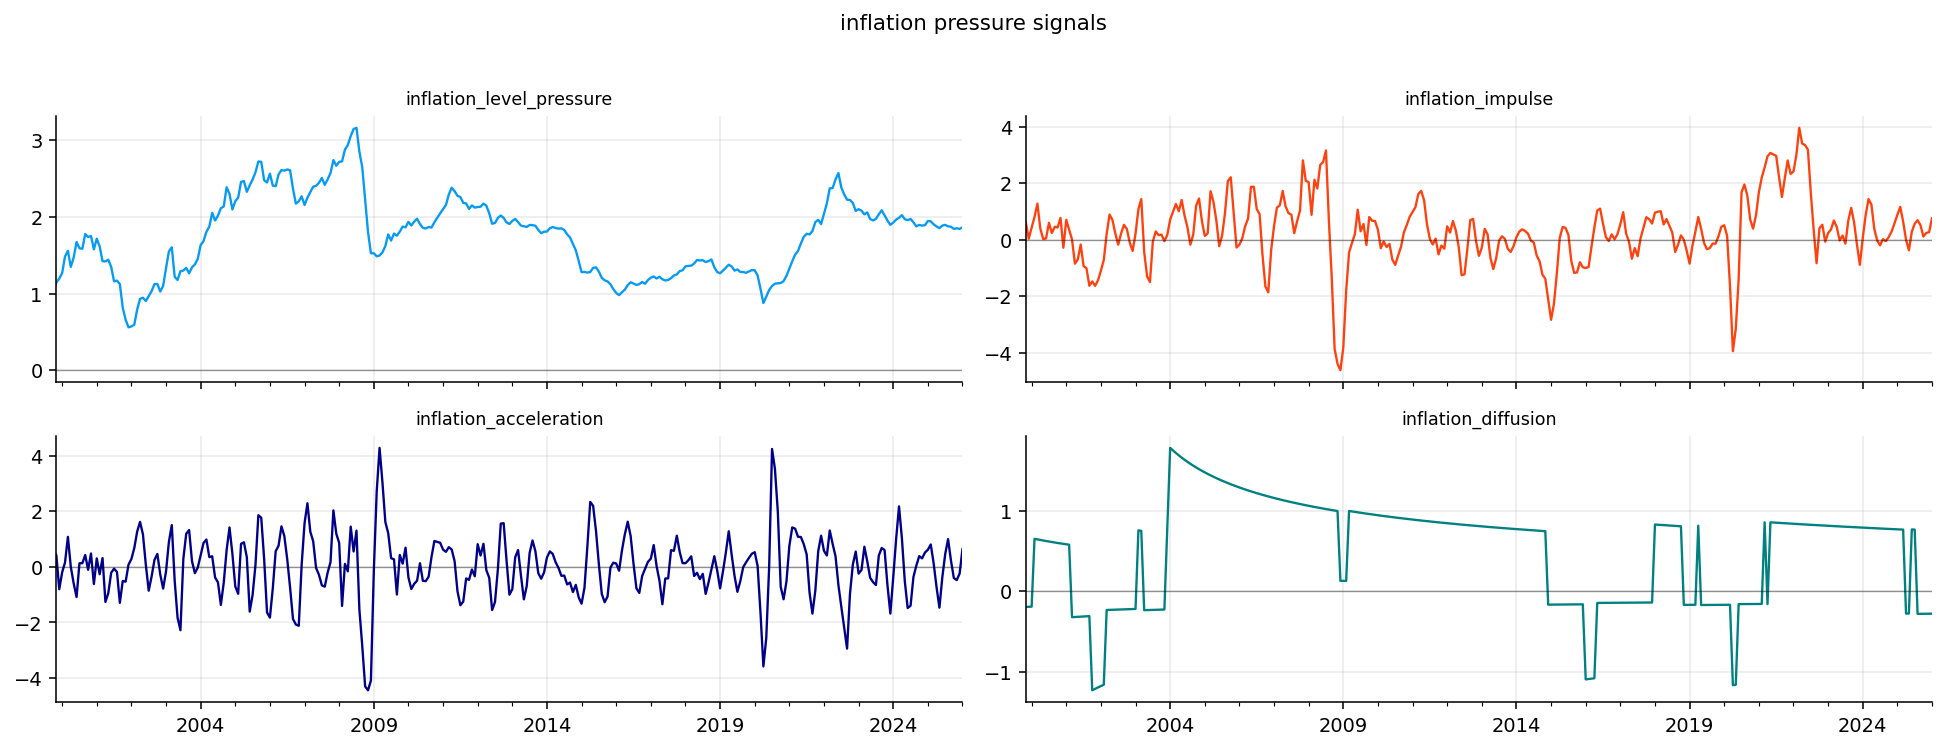

,inflation_level_pressure,inflation_impulse,inflation_acceleration,inflation_diffusion
date,,,,
2025-09-30,1.871905,0.521357,0.232770,-0.280186
2025-10-31,1.843487,0.115857,-0.399261,-0.279780
2025-11-30,1.851715,0.238564,-0.472732,-0.279375
2025-12-31,1.844230,0.270325,-0.238794,-0.278972
2026-01-31,1.862841,0.764842,0.648218,-0.278571


In [19]:
inflation_signals = pd.DataFrame(index=macro_factors.index)
inflation_signals["inflation_level_pressure"] = mean_z(macro_factors, inflation_cols, min_obs=min_obs)
inflation_signals["inflation_impulse"] = change_z(macro_factors, inflation_cols, periods=3, min_obs=min_obs)
inflation_accel = macro_factors[inflation_cols].diff(3).diff(3)
inflation_signals["inflation_acceleration"] = inflation_accel.apply(lambda s: expanding_zscore(s, min_obs=min_obs)).mean(axis=1, skipna=True)
inflation_signals["inflation_diffusion"] = stress_share(macro_factors, inflation_cols, min_obs=min_obs, threshold=0.5)
plot_signal_group(inflation_signals, "inflation pressure signals")
display(inflation_signals.tail())


From the inflation plots, the strongest inflation-pressure episode is clearly the post-2021 inflation shock. The level pressure rises sharply and stays elevated for a long period, which matches the broad macro story after the pandemic: supply bottlenecks, energy pressure, fiscal demand, and later tighter labor markets.

The latest table is also informative. In January 2026, **inflation level pressure is about 1.86**, which means inflation-related variables are still high relative to their own history. The latest **inflation impulse is about 0.76**, and **inflation acceleration is about 0.65**, so the latest reading is not just a high-level story. There is also some renewed upward movement in the inflation block.

The diffusion component is negative at about **-0.28**. That tells us the pressure is not broad in the same way it was during the worst part of the 2021–2022 inflation episode. This distinction matters for markets. A high inflation level with low diffusion can mean inflation remains sticky in some components, while a high level with high diffusion signals a more dangerous broad price regime.


### Inflation Regime Interpretation for Assets

Inflation affects sectors differently.

Energy and materials may benefit when inflation is commodity-driven because their revenues are directly linked to commodity prices. Gold can benefit when inflation reduces confidence in real purchasing power or when real rates are low. Financials can benefit from higher rates if the yield curve and credit cycle remain healthy, but they can suffer if policy tightening damages loan growth or credit quality.

Growth stocks usually dislike inflation-driven rate shocks because their valuations depend more heavily on long-dated expected cash flows. A higher discount rate hurts those distant cash flows more. If we write a simplified long-duration equity valuation as:

$$
P_t\approx\frac{CF_{t+H}}{(1+r)^H}
$$

then a change in $r$ has a larger price effect when $H$ is large. That is the duration logic behind growth-stock sensitivity to rates.

This is why the inflation block later supports inflation beneficiaries but penalizes some rate-sensitive sectors through the policy block. The model separates inflation pressure from policy pressure because markets don't react to inflation alone. They react to inflation plus the central bank response.


## 6) Policy and Rate Pressure

Policy pressure measures the tightness of monetary conditions. The central bank affects markets through the short rate, but the market also prices policy through Treasury yields and the yield curve. A higher policy-rate block generally means financing is more expensive and duration-sensitive assets face more pressure.

The basic policy tightness signal is an average of standardized rate-related variables:

$$
P_t^{tight}=\frac{1}{N_t}\sum_{i\in\mathcal{P}_t} z(r_{i,t})
$$

where $r_{i,t}$ includes short rates, policy rates, and government bond yields. Higher values mean rates are high relative to history.

The policy shock signal measures rapid movement:

$$
P_t^{shock}=\frac{1}{N_t}\sum_{i\in\mathcal{P}_t} z(r_{i,t}-r_{i,t-3})
$$

This captures the market impact of a fast policy move. A rate level can be high but stable. A rate shock means investors are being forced to reprice discount rates quickly.

The real-rate squeeze combines policy pressure with inflation impulse:

$$
\text{real\_rate\_squeeze}_t=P_t^{tight}-I_t^{impulse}
$$

When this is high, policy is tight relative to recent inflation momentum. When it is low or negative, inflation is moving faster than the policy block, so real tightening may be less forceful.


### Policy Catch-Up Risk

The policy catch-up component tries to detect periods where inflation is high but policy has not fully caught up. It is based on the positive gap:

$$
g_t=\max(I_t^{level}-P_t^{tight},0)
$$

and then this gap is standardized:

$$
\text{catchup}_t=z(g_t)
$$

The logic is simple. If inflation pressure is high and policy tightness is still low, the market may eventually price future hikes or a delayed tightening campaign. That is a dangerous setup for long-duration bonds and expensive growth equities.

The latest policy table shows a different situation from the 2022 tightening shock. Policy tightness is only around **0.28**, policy shock is slightly negative, and policy catch-up risk is around **-0.81**. This says rate pressure is no longer in the active shock phase. The latest stress is more about inflation still being elevated than about policy rapidly tightening.

That difference matters for sector interpretation. If policy pressure were strongly positive, rate-sensitive assets like utilities, real estate, and long-duration growth would face a direct discount-rate headwind. With policy pressure easing, the macro issue becomes more about sticky inflation and whether growth can absorb it.


### Real Rates and the Policy Transmission Channel

A policy rate is a nominal rate. What matters for spending and investment is often the real rate, roughly nominal rate minus expected inflation:

$$
r_t^{real}\approx i_t-\pi_t^e
$$

where $i_t$ is the nominal policy rate and $\pi_t^e$ is expected inflation. When real rates rise, borrowing becomes expensive after inflation, and financial conditions tighten. Housing, private investment, leveraged companies, and long-duration assets become more vulnerable.

The project doesn't directly estimate expected inflation. Instead, it uses the relationship between policy tightness and inflation impulse as a practical signal. If policy tightness is high relative to current inflation impulse, the real-rate squeeze becomes positive. If inflation impulse is running ahead of policy, the squeeze becomes lower.

This is a simplified macro proxy, but it captures a useful idea: the same nominal policy rate can mean different things depending on inflation momentum. A 5% policy rate with collapsing inflation is tight. A 5% policy rate with inflation accelerating can feel less restrictive in real terms until policy catches up.


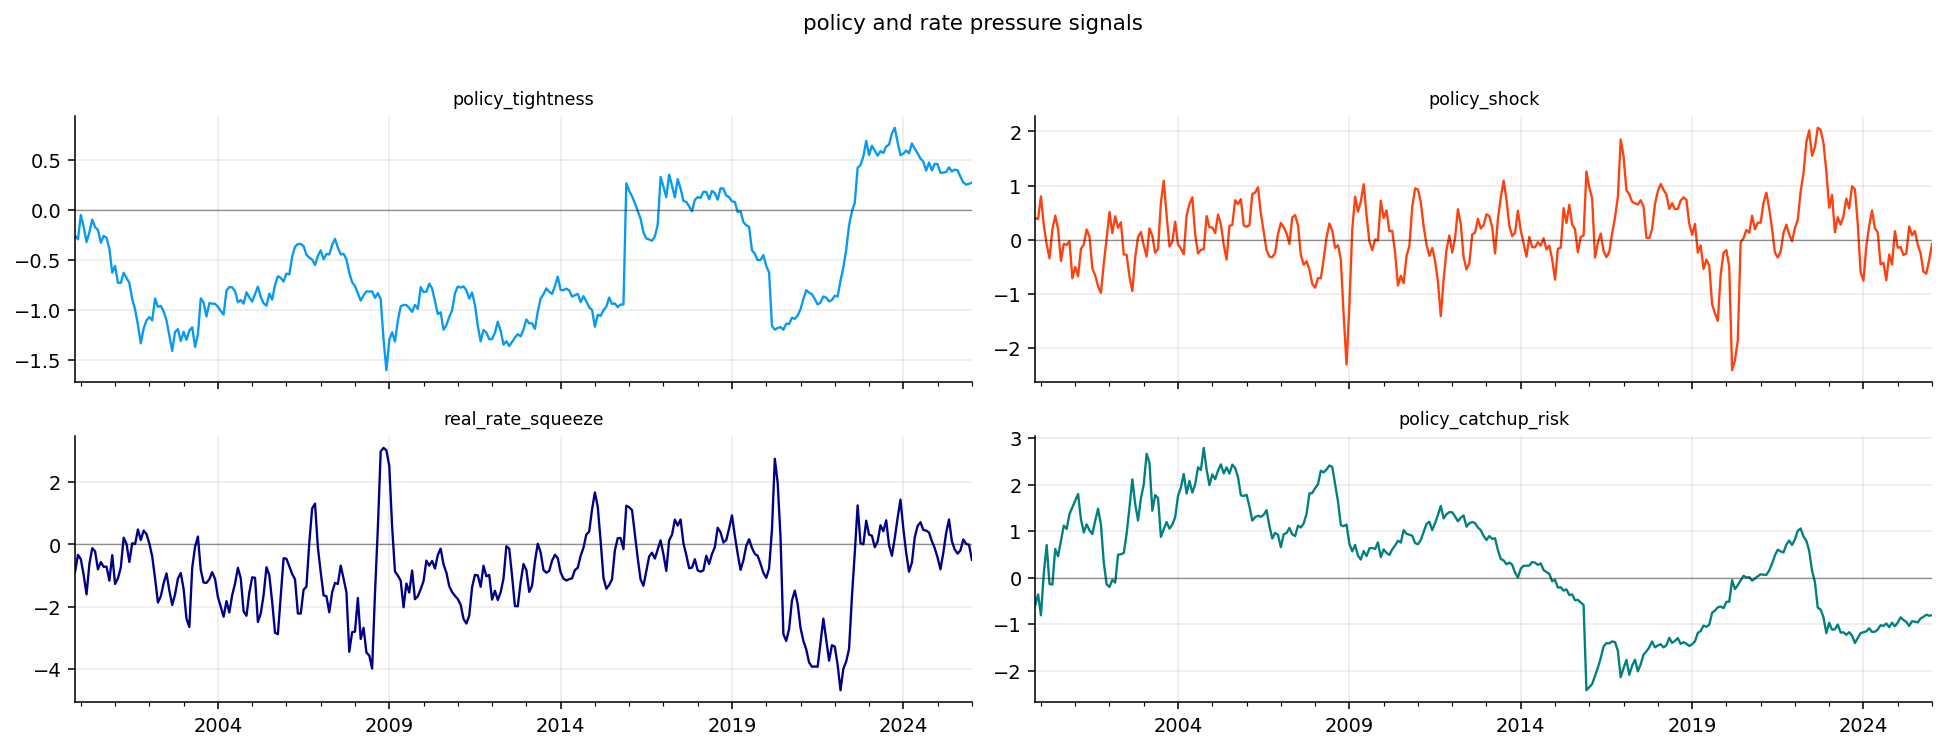

,policy_tightness,policy_shock,real_rate_squeeze,policy_catchup_risk
date,,,,
2025-09-30,0.333683,-0.252234,-0.187674,-0.879073
2025-10-31,0.277807,-0.593257,0.161951,-0.840819
2025-11-30,0.255488,-0.629775,0.016924,-0.798640
2025-12-31,0.263783,-0.377883,-0.006543,-0.817692
2026-01-31,0.276304,-0.084204,-0.488538,-0.807839


In [20]:
policy_signals = pd.DataFrame(index=macro_factors.index)
policy_signals["policy_tightness"] = mean_z(macro_factors, policy_cols, min_obs=min_obs)
policy_signals["policy_shock"] = change_z(macro_factors, policy_cols, periods=3, min_obs=min_obs)
policy_signals["real_rate_squeeze"] = policy_signals["policy_tightness"] - inflation_signals["inflation_impulse"]
policy_gap = inflation_signals["inflation_level_pressure"] - policy_signals["policy_tightness"]
policy_signals["policy_catchup_risk"] = expanding_zscore(policy_gap.clip(lower=0.0), min_obs=min_obs)
plot_signal_group(policy_signals, "policy and rate pressure signals")
display(policy_signals.tail())


### Policy Pressure and Sector Sensitivity

Policy pressure enters sector returns through both funding costs and discount rates.

Utilities and real estate often behave like bond proxies because they have stable cash flows and high sensitivity to yields. When rates rise, their dividend yields become less attractive and their debt costs rise. Technology and consumer discretionary can also be rate-sensitive because a large share of their value depends on future growth expectations.

Banks and financials are more complicated. Higher rates can increase net interest margins, but if rates rise during a growth slowdown, credit losses and funding stress can dominate. That is why the strategy later applies an extra penalty to XLF when policy pressure and growth recession stress are both positive:

$$
\text{financial penalty}_t\propto \max(B_{P,t},0)\max(B_{G,t},0)
$$

The multiplication matters. Policy pressure alone is not always bad for banks. Growth stress alone is not always enough. The combination is dangerous because loan demand weakens, credit losses rise, and funding conditions tighten together.


## 7) Growth and Recession Signals

Growth data is sign-flipped because weak growth is the stress state. If a growth variable $g_t$ is high relative to history, its raw z-score is positive, but its stress score is negative:

$$
s_t^{growth}=-z(g_t)
$$

This means positive growth stress corresponds to falling or weak growth, while negative growth stress corresponds to strong growth.

The growth block includes hard activity data such as production and sales, plus survey and leading-indicator information. We build:

$$
G_t^{level}=\frac{1}{N_t}\sum_{i\in\mathcal{G}_t}-z(g_{i,t})
$$

$$
G_t^{impulse}=\frac{1}{N_t}\sum_{i\in\mathcal{G}_t}-z(g_{i,t}-g_{i,t-3})
$$

and growth breadth stress from the share of growth indicators that are weak. If many indicators are simultaneously below their own trend, the breadth signal rises.

This group is critical because inflation and policy stress do not always become equity stress unless growth deteriorates. A high-rate environment with resilient growth can still support cyclicals and earnings. A high-rate environment with collapsing growth is much more dangerous.


### Hard Data Versus Soft Data

Growth analysis becomes more useful when we separate hard and soft data.

Hard data includes industrial production, retail sales, payrolls, and real activity measures. These variables describe actual spending and production. They are slower, sometimes revised, and often confirmed after the economy has already moved.

Soft data includes surveys such as consumer confidence, business confidence, PMIs, and sentiment measures. These variables describe expectations and reported conditions. They can move earlier, but they can also overreact to news, politics, inflation frustration, or media attention.

The project includes both because markets respond to both. Soft data can move valuations and risk appetite quickly. Hard data confirms whether the earnings and labor consequences are actually happening.

A useful interpretation rule is this: when hard data and soft data agree, the macro signal is stronger. When they disagree, the regime is mixed. In the latest US output, hard growth stress is negative, but survey warning is strongly positive. That is exactly a mixed-growth regime.


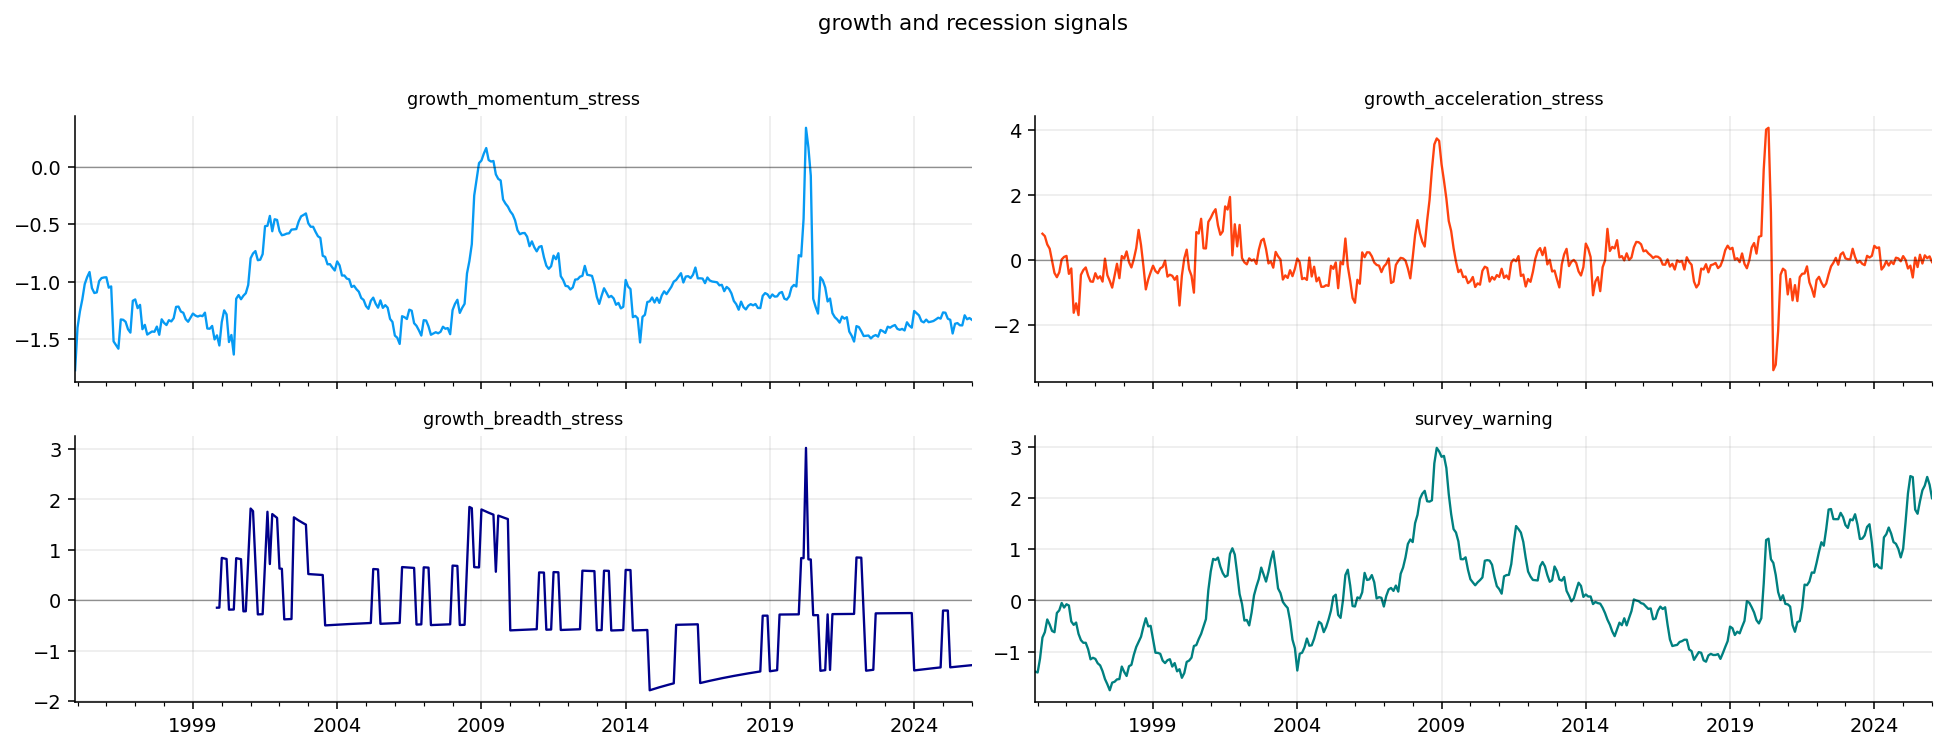

,growth_momentum_stress,growth_acceleration_stress,growth_breadth_stress,survey_warning
date,,,,
2025-09-30,-1.381116,-0.098655,-1.302400,2.152217
2025-10-31,-1.293028,0.152900,-1.297677,2.245408
2025-11-30,-1.327734,0.067692,-1.293005,2.414330
2025-12-31,-1.316841,0.120685,-1.288383,2.261299
2026-01-31,-1.332384,-0.053924,-1.283811,1.998803


In [21]:
growth_signals = pd.DataFrame(index=macro_factors.index)
growth_signals["growth_momentum_stress"] = mean_z(macro_factors, growth_cols, min_obs=min_obs, sign=-1.0)
growth_signals["growth_acceleration_stress"] = change_z(macro_factors, growth_cols, periods=3, min_obs=min_obs, sign=-1.0)
growth_signals["growth_breadth_stress"] = stress_share(macro_factors, growth_cols, min_obs=min_obs, threshold=0.5, sign=-1.0)
growth_signals["survey_warning"] = mean_z(macro_factors, survey_cols, min_obs=min_obs, sign=-1.0)
plot_signal_group(growth_signals, "growth and recession signals")
display(growth_signals.tail())


The latest growth table gives a very useful mixed signal. **Growth momentum stress is around -1.33** and **growth breadth stress is around -1.28**, which means the hard growth data is still strong relative to its historical distribution. Growth acceleration stress is close to zero, so the immediate hard-data deterioration is limited.

But the **survey warning is around 2.00** in January 2026 and was even higher in late 2025. This says soft data is much more pessimistic than hard activity data. That kind of gap is common around turning points: surveys react quickly to uncertainty, inflation frustration, politics, financial tightening, or business caution, while hard data may remain stable until spending and hiring actually change.

For portfolio use, this means we shouldn’t label the environment as a simple recession regime. Hard data is not showing strong recession stress. Surveys are warning that expectations are fragile. A strategy that uses only realized growth data may stay too risk-on, while a strategy that uses only surveys may become too defensive.


### Growth Stress and Earnings

Growth stress matters because equity prices ultimately depend on future earnings. At a broad level:

$$
E_t[CF_{t+h}]\approx \text{margin expectations}\times \text{revenue expectations}
$$

Growth weakness hits revenues first. If companies sell fewer goods or services, revenue expectations fall. If demand weakens while costs remain high, margins compress too. This is why growth recession stress can affect both cyclical sectors and broad equity beta.

Cyclicals like industrials, discretionary, materials, and financials are usually most exposed to growth stress. Defensive sectors like staples and health care have more stable demand, so they tend to hold up better when growth deteriorates.

The strategy later reflects this relation. Cyclical sectors receive support when FCI percentile is low and growth stress is low. Defensive sectors receive support when FCI percentile or growth stress rises. That is not arbitrary sector timing; it comes directly from the macro cash-flow channel.


## 8) Labor Cooling and Sahm Pressure

The labor market is often the most important confirmation layer in macro analysis. Recessions usually become obvious when labor deteriorates. Equity markets may fall before unemployment rises, but once unemployment and claims move, the recession signal becomes much more reliable.

The labor block combines three types of information:

- **Unemployment level**, where higher unemployment is stress.
- **Claims**, where higher initial or continuing claims are stress.
- **Jobs and hours**, where weak payrolls or hours are stress, so the sign is flipped.

The combined labor cooling signal can be written conceptually as:

$$
L_t=\frac{1}{3}\left(z(\text{unemployment}_t)+z(\text{claims}_t)-z(\text{jobs/hours}_t)\right)
$$

The project also computes a Sahm-style pressure variable. The Sahm rule compares the recent unemployment rate with its recent low. A simplified version is:

$$
\text{SahmGap}_t=\overline{u}_{t:t-2}^{3m}-\min(u_{t-11},\ldots,u_t)
$$

where $u_t$ is unemployment. The project standardizes this gap rather than using one fixed recession threshold. Rising Sahm pressure means unemployment has moved up enough relative to its recent low to look economically important.


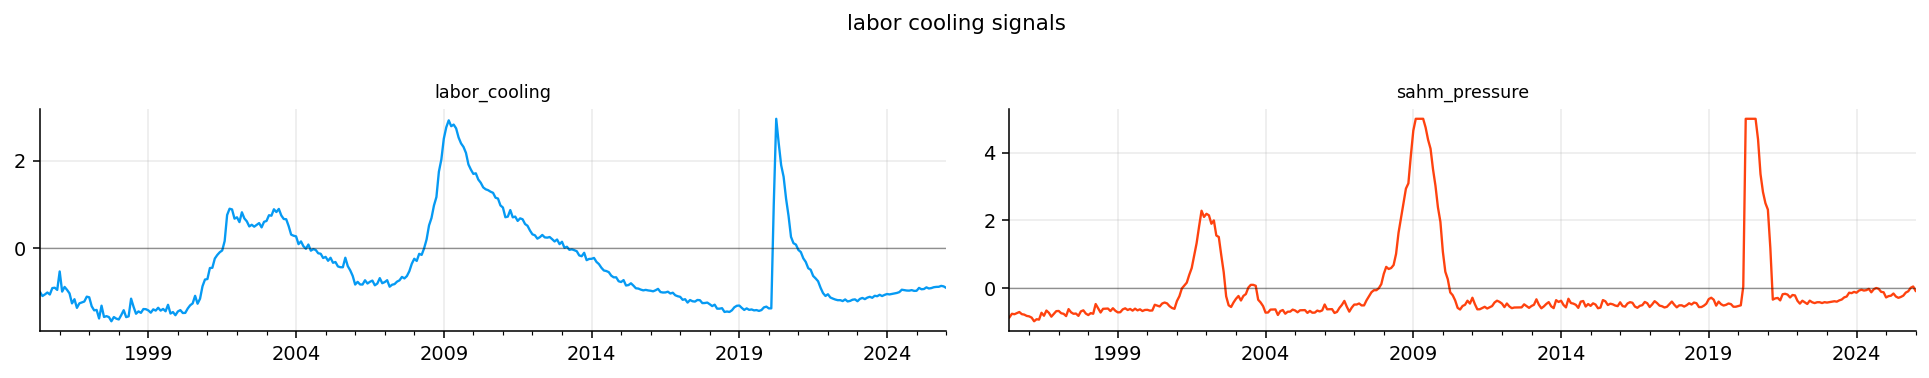

,labor_cooling,sahm_pressure
date,,
2025-09-30,-0.896948,-0.132507
2025-10-31,-0.894983,-0.093826
2025-11-30,-0.873793,0.009136
2025-12-31,-0.885415,0.047740
2026-01-31,-0.918880,-0.081183


In [22]:
labor_signals = pd.DataFrame(index=macro_factors.index)
labor_parts = pd.concat([
    mean_z(macro_factors, labor_unemployment_cols, min_obs=min_obs),
    mean_z(macro_factors, labor_claims_cols, min_obs=min_obs),
    mean_z(macro_factors, labor_jobs_cols, min_obs=min_obs, sign=-1.0),
], axis=1)
labor_signals["labor_cooling"] = labor_parts.mean(axis=1, skipna=True)
unemployment = macro_factors[labor_unemployment_cols].mean(axis=1, skipna=True)
sahm_gap = unemployment.rolling(3, min_periods=3).mean() - unemployment.rolling(12, min_periods=6).min()
labor_signals["sahm_pressure"] = expanding_zscore(sahm_gap, min_obs=min_obs)
plot_signal_group(labor_signals, "labor cooling signals")
display(labor_signals.tail())


The labor plots show the large labor stress events clearly: the 2008 crisis, the COVID shock, and smaller labor-cooling periods. The latest values are not recession-like. **Labor cooling is around -0.92**, and Sahm pressure is slightly negative around **-0.08**.

That means the labor block is currently supporting the idea that the economy is not in a broad labor-market downturn. The labor market may be cooling at the margin in some recent months, but the aggregate signal is not close to the kind of stress seen in 2008 or 2020.

This is economically important because labor is the bridge between macro data and earnings. If labor is stable, households still have income, defaults stay contained, and consumer sectors can keep spending support. If labor breaks, the macro environment becomes much more dangerous for equities, especially financials, discretionary, industrials, and credit-sensitive exposures.


### Labor as a Regime Confirmation Variable

Labor data is often late, but it is powerful. Markets can sometimes ignore weak surveys if employment stays strong. It is harder to ignore rising unemployment and rising claims because those variables directly affect income, defaults, and consumption.

Labor also changes the central bank reaction function. If inflation is high and labor is strong, the central bank has more room to stay tight. If inflation is falling and labor is weakening, policy can shift toward easing. This is why labor matters for both cash flows and rates.

The Sahm-style variable is useful because it focuses on changes from a recent low rather than the absolute unemployment rate. A country can have a low unemployment rate and still enter recession if unemployment has risen sharply from its trough. The gap formulation catches that turning-point behavior.

In the latest US data, Sahm pressure is not elevated. That weakens the recession case even though surveys are warning. The labor block is therefore a stabilizing input in the latest macro state.


## 9) Housing, Domestic Demand, and External Trade

Housing is rate-sensitive and forward-looking. Mortgage rates affect affordability quickly, and housing activity often weakens before the broader economy. The housing block combines the level and impulse of housing indicators, then adds a rate-squeeze component.

The housing impulse stress is roughly:

$$
H_t^{impulse}=\frac{1}{2}\left(H_t^{level}+H_t^{change}\right)
$$

where both components are stress-oriented. Strong housing activity produces negative stress; weak housing activity produces positive stress.

The housing rate squeeze combines housing stress with policy tightness:

$$
H_t^{squeeze}=\frac{1}{2}(H_t^{impulse}+P_t^{tight})
$$

This catches the situation where housing is weakening while rates are still restrictive. That mix can be especially painful because housing is a large transmission channel for monetary policy.

External trade is separate. External demand stress captures weakening exports and imports, while external vulnerability captures pressure from trade or current-account balances. For a large domestic economy like the US, external trade may be less dominant than for Canada, but it still matters through global demand, dollar strength, commodities, and multinational earnings.


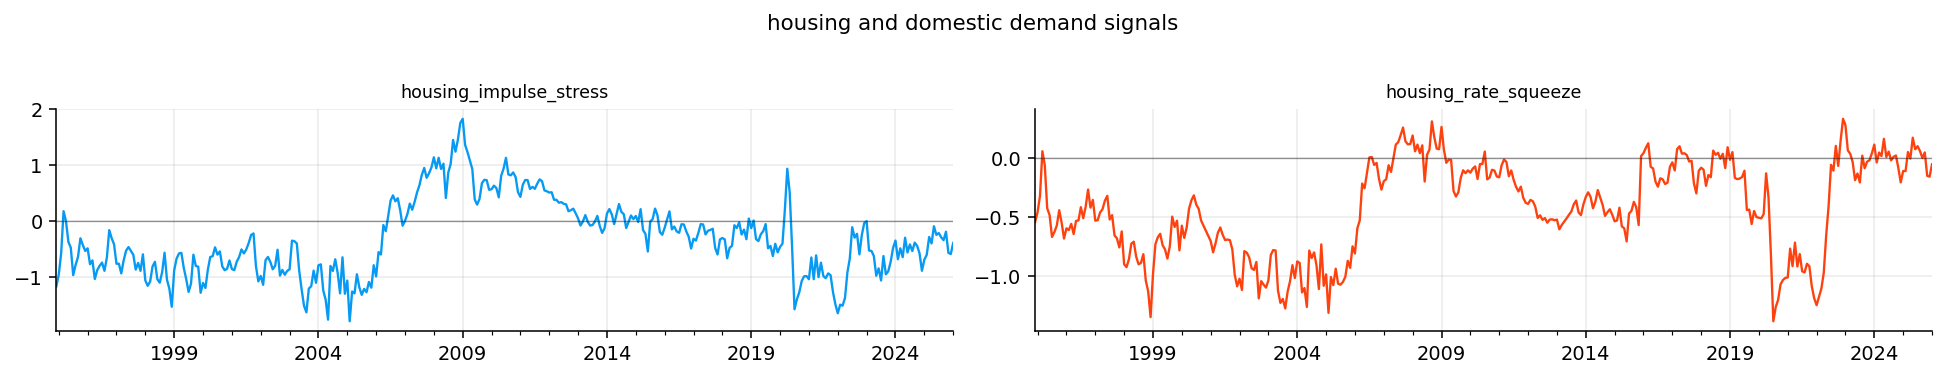

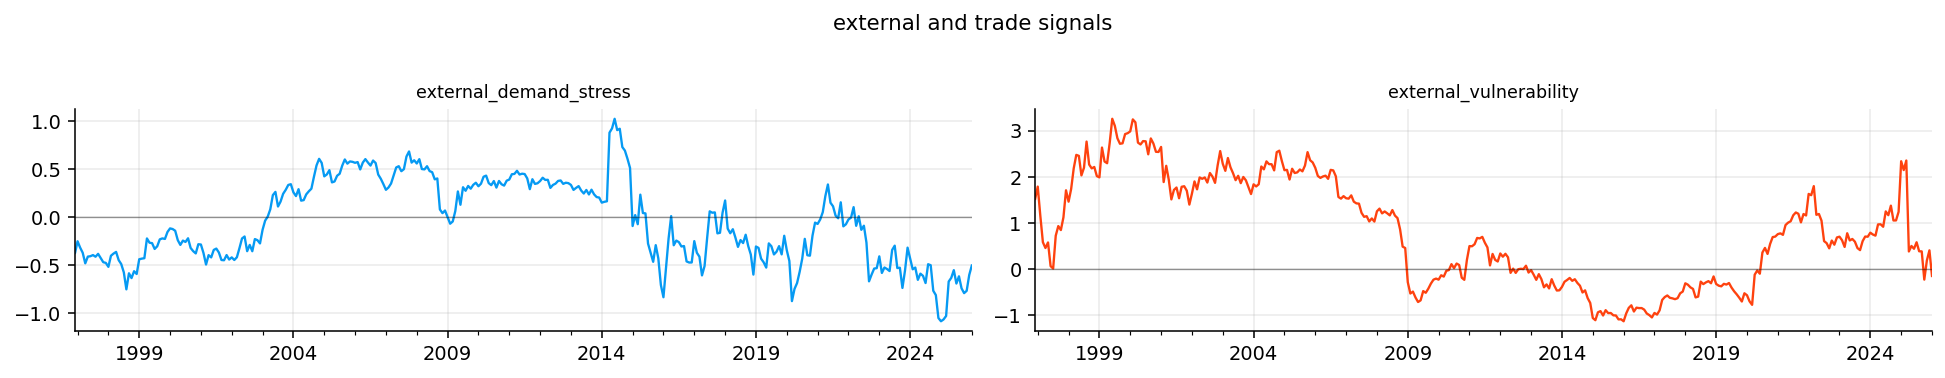

,housing_impulse_stress,housing_rate_squeeze,external_demand_stress,external_vulnerability
date,,,,
2025-09-30,-0.336861,-0.001589,-0.740800,0.386239
2025-10-31,-0.186225,0.045791,-0.791354,-0.224556
2025-11-30,-0.560133,-0.152322,-0.767349,0.189093
2025-12-31,-0.582784,-0.159501,-0.601934,0.409097
2026-01-31,-0.385874,-0.054785,-0.503834,-0.145235


In [23]:
housing_external_signals = pd.DataFrame(index=macro_factors.index)
housing_level = mean_z(macro_factors, housing_cols, min_obs=min_obs, sign=-1.0)
housing_impulse = change_z(macro_factors, housing_cols, periods=3, min_obs=min_obs, sign=-1.0)
housing_external_signals["housing_impulse_stress"] = pd.concat([housing_level, housing_impulse], axis=1).mean(axis=1, skipna=True)
housing_external_signals["housing_rate_squeeze"] = pd.concat([housing_external_signals["housing_impulse_stress"], policy_signals["policy_tightness"]], axis=1).mean(axis=1, skipna=True)
housing_external_signals["external_demand_stress"] = mean_z(macro_factors, external_demand_cols, min_obs=min_obs, sign=-1.0)
housing_external_signals["external_vulnerability"] = mean_z(macro_factors, external_balance_cols, min_obs=min_obs, sign=-1.0)
plot_signal_group(housing_external_signals[["housing_impulse_stress", "housing_rate_squeeze"]], "housing and domestic demand signals")
plot_signal_group(housing_external_signals[["external_demand_stress", "external_vulnerability"]], "external and trade signals")
display(housing_external_signals.tail())


The housing plots show a strong stress episode during the housing bubble collapse and the 2008 crisis. That is exactly what we want: housing stress should become visible before and during the financial crisis.

The latest housing values are mostly negative: **housing impulse stress is around -0.39** and **housing rate squeeze is around -0.05**. This says housing is not currently driving the broad macro stress index in the same way it did before 2008. Rate pressure exists, but the combined housing stress block is not elevated in the latest reading.

External demand stress is also negative in the latest table, around **-0.50**, while external vulnerability is slightly negative. So the latest US macro picture is not one of trade-driven weakness either. For the US section, the main current pressure is inflation, while growth, labor, housing, and external trade are not broadly stressed.


### Housing and Trade as Transmission Channels

Housing is one of the main channels through which rates affect the real economy. Higher mortgage rates reduce affordability, lower transaction volumes, pressure construction activity, and can eventually affect employment in construction, real estate services, home improvement, and credit.

A simple affordability relation is:

$$
\text{payment}\approx \frac{i_m(1+i_m)^n}{(1+i_m)^n-1}\times \text{loan principal}
$$

where $i_m$ is the monthly mortgage rate and $n$ is the number of monthly payments. When the mortgage rate rises, the payment rises nonlinearly for a fixed loan size. That is why housing can weaken quickly when rates jump.

External trade matters through global demand and currency channels. A strong dollar can pressure exporters and emerging-market demand, while weak global demand can reduce revenues for multinational firms. For Canada, external trade is even more central because commodities and US demand play a larger role.

These blocks are not always the largest drivers, but they give the FCI more economic coverage than an index built only from inflation, rates, and unemployment.


## 10) Breadth, Severe Breadth, Stagflation, and Goldilocks

After building the first-level signals, we build aggregate macro-state signals. These are not tied to one specific economic category. They measure how stress is distributed across the whole macro system.

The stress breadth signal begins with the share of first-level signals above a stress threshold:

$$
b_t^{stress}=\frac{1}{M_t}\sum_{j=1}^{M_t}\mathbf{1}\{s_{j,t}>0.5\}
$$

Then it is standardized through time. Severe stress breadth uses a higher threshold, usually $1.0$:

$$
b_t^{severe}=\frac{1}{M_t}\sum_{j=1}^{M_t}\mathbf{1}\{s_{j,t}>1.0\}
$$

This breadth logic is useful because regimes differ by concentration. A single inflation pressure variable above one standard deviation is not the same as inflation, policy, labor, housing, and growth all above one standard deviation.

The stagflation pressure signal averages the main conflict variables:

$$
S_t^{stag}=\frac{1}{3}(I_t^{level}+P_t^{tight}+G_t^{stress})
$$

High stagflation pressure means inflation and rates are high while growth is weak. That is one of the worst environments for balanced portfolios because equities face earnings pressure and bonds face inflation/rate pressure.


Goldilocks support is the opposite type of macro environment. It is built from inflation pressure, policy pressure, growth stress, and labor cooling:

$$
G_t^{gold}= -\frac{1}{4}(I_t^{level}+P_t^{tight}+G_t^{stress}+L_t^{cool})
$$

Higher goldilocks support means inflation is not pressuring policy, rates are not tight, growth stress is low, and labor is healthy. In that environment, risk assets usually get support because earnings can grow while discount-rate pressure is limited.

The latest breadth table shows **stress breadth is negative**, **severe stress breadth is negative**, and **stagflation pressure is only around 0.27**. Goldilocks support is near zero. The interpretation is a mixed but contained macro environment: inflation is still high, but stress is not broad across the whole economy.

That is exactly the type of state where a macro model can help. Pure momentum might keep buying what has worked. Pure defensive allocation might overreact to inflation. A block-level FCI can say: inflation pressure exists, but broad recession stress is not yet confirmed.


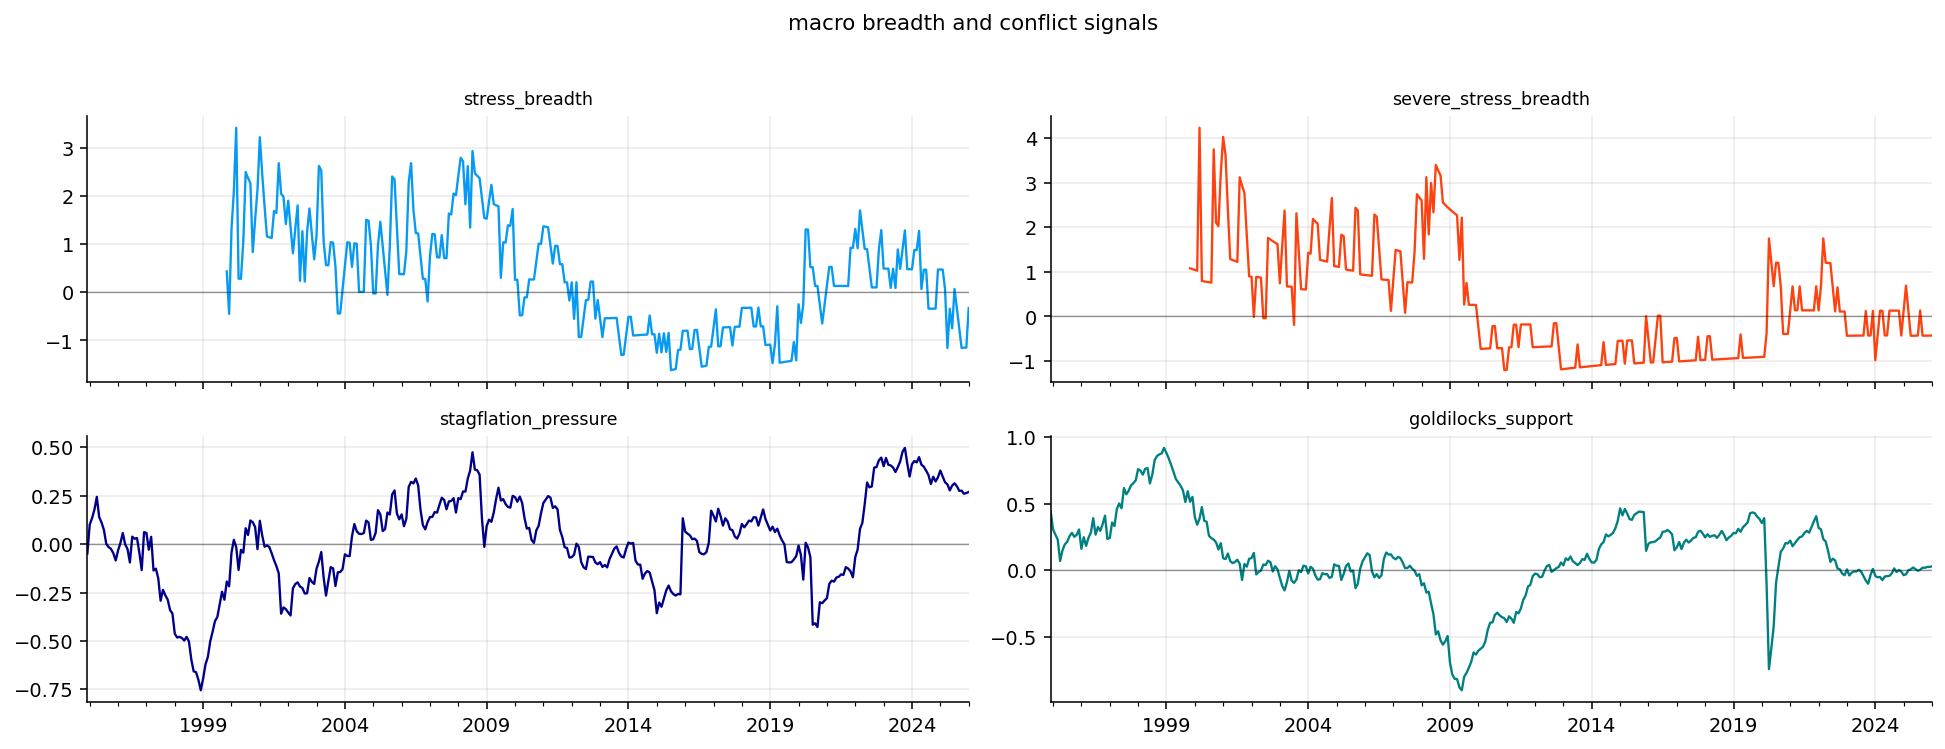

,inflation_level_pressure,inflation_impulse,inflation_acceleration,inflation_diffusion,policy_tightness,policy_shock,real_rate_squeeze,policy_catchup_risk,growth_momentum_stress,growth_acceleration_stress,growth_breadth_stress,survey_warning,labor_cooling,sahm_pressure,housing_impulse_stress,housing_rate_squeeze,external_demand_stress,external_vulnerability,stress_breadth,severe_stress_breadth,stagflation_pressure,goldilocks_support
date,,,,,,,,,,,,,,,,,,,,,,
2025-09-30,1.871905,0.521357,0.232770,-0.280186,0.333683,-0.252234,-0.187674,-0.879073,-1.381116,-0.098655,-1.302400,2.152217,-0.896948,-0.132507,-0.336861,-0.001589,-0.740800,0.386239,-0.747258,-0.429737,0.274824,0.018119
2025-10-31,1.843487,0.115857,-0.399261,-0.279780,0.277807,-0.593257,0.161951,-0.840819,-1.293028,0.152900,-1.297677,2.245408,-0.894983,-0.093826,-0.186225,0.045791,-0.791354,-0.224556,-1.154077,-0.429052,0.276089,0.016679
2025-11-30,1.851715,0.238564,-0.472732,-0.279375,0.255488,-0.629775,0.016924,-0.798640,-1.327734,0.067692,-1.293005,2.414330,-0.873793,0.009136,-0.560133,-0.152322,-0.767349,0.189093,-1.150465,-0.428370,0.259823,0.023581
2025-12-31,1.844230,0.270325,-0.238794,-0.278972,0.263783,-0.377883,-0.006543,-0.817692,-1.316841,0.120685,-1.288383,2.261299,-0.885415,0.047740,-0.582784,-0.159501,-0.601934,0.409097,-1.146888,-0.427691,0.263724,0.023561
2026-01-31,1.862841,0.764842,0.648218,-0.278571,0.276304,-0.084204,-0.488538,-0.807839,-1.332384,-0.053924,-1.283811,1.998803,-0.918880,-0.081183,-0.385874,-0.054785,-0.503834,-0.145235,-0.326565,-0.427016,0.268921,0.028029


In [24]:
first_signals = pd.concat([inflation_signals, policy_signals, growth_signals, labor_signals, housing_external_signals], axis=1)
breadth_signals = pd.DataFrame(index=macro_factors.index)
breadth_signals["stress_breadth"] = expanding_zscore((first_signals > 0.5).where(first_signals.notna()).mean(axis=1, skipna=True), min_obs=min_obs)
breadth_signals["severe_stress_breadth"] = expanding_zscore((first_signals > 1.0).where(first_signals.notna()).mean(axis=1, skipna=True), min_obs=min_obs)
breadth_signals["stagflation_pressure"] = first_signals[["inflation_level_pressure", "policy_tightness", "growth_momentum_stress"]].mean(axis=1, skipna=True)
breadth_signals["goldilocks_support"] = -first_signals[["inflation_level_pressure", "policy_tightness", "growth_momentum_stress", "labor_cooling"]].mean(axis=1, skipna=True)
signals = pd.concat([first_signals, breadth_signals], axis=1)
plot_signal_group(breadth_signals, "macro breadth and conflict signals")
display(signals.tail())


## 11) From Signals to Macro Blocks

The first-level signals are useful, but there are too many of them for a clean FCI. We compress them into seven macro blocks:

$$
B_t=\begin{bmatrix}B_{I,t} & B_{P,t} & B_{G,t} & B_{L,t} & B_{H,t} & B_{E,t} & B_{C,t}\end{bmatrix}
$$

where the blocks are inflation pressure, policy/rate pressure, growth recession, labor cooling, housing/domestic demand, external trade, and macro breadth/conflict.

Each block is an average of related signals. For example:

$$
B_{I,t}=\frac{1}{4}\left(I_t^{level}+I_t^{impulse}+I_t^{accel}+I_t^{diffusion}\right)
$$

The same logic applies to the other groups. Averaging reduces noise because one macro variable can be revised, delayed, or distorted. The block is meant to capture the common stress inside a category.

A block-level FCI has two advantages:

- It remains interpretable. We can explain whether the index is high because of inflation, labor, growth, or housing.
- It becomes statistically more stable. PCA, PLS, and logistic models work better on seven economic blocks than on dozens of noisy raw macro variables.


In [25]:
blocks = pd.DataFrame(index=signals.index)
blocks["inflation_pressure_block"] = signals[["inflation_level_pressure", "inflation_impulse", "inflation_acceleration", "inflation_diffusion"]].mean(axis=1, skipna=True)
blocks["policy_rate_pressure_block"] = signals[["policy_tightness", "policy_shock", "real_rate_squeeze", "policy_catchup_risk"]].mean(axis=1, skipna=True)
blocks["growth_recession_block"] = signals[["growth_momentum_stress", "growth_acceleration_stress", "growth_breadth_stress", "survey_warning"]].mean(axis=1, skipna=True)
blocks["labor_cooling_block"] = signals[["labor_cooling", "sahm_pressure"]].mean(axis=1, skipna=True)
blocks["housing_domestic_block"] = signals[["housing_impulse_stress", "housing_rate_squeeze"]].mean(axis=1, skipna=True)
blocks["external_trade_block"] = signals[["external_demand_stress", "external_vulnerability"]].mean(axis=1, skipna=True)
blocks["macro_breadth_conflict_block"] = signals[["stress_breadth", "severe_stress_breadth", "stagflation_pressure"]].join(-signals["goldilocks_support"].rename("negative_goldilocks_support")).mean(axis=1, skipna=True)
macro_full = pd.concat([signals, blocks], axis=1)
macro_full["n_raw_series_used"] = macro_factors.notna().sum(axis=1)
macro_full["n_signals_available"] = signals.notna().sum(axis=1)
macro_full["n_blocks_available"] = blocks.notna().sum(axis=1)
macro_full["coverage_score"] = macro_full["n_blocks_available"] / blocks.shape[1]
macro_full = macro_full.loc[(macro_full["n_blocks_available"] >= 6) & (macro_full["n_raw_series_used"] >= 10)]
block_cols = blocks.columns.tolist()
meta_cols = ["n_raw_series_used", "n_signals_available", "n_blocks_available", "coverage_score"]
signal_cols = signals.columns.tolist()
macro_start_candidates = macro_full.index[macro_full[block_cols].notna().sum(axis=1) >= 6]
macro_start = max(macro_start_candidates[0], minimum_visible_date)
macro = macro_full.loc[macro_start:].copy()
availability_rows = []
for col in macro.columns:
    s = macro[col]
    availability_rows.append({"column": col, "first_date": s.first_valid_index(), "last_date": s.last_valid_index(), "observations": int(s.notna().sum()), "available_share": float(s.notna().mean())})
availability = pd.DataFrame(availability_rows).set_index("column")
display(pd.DataFrame({"warmup_start": [macro_full.index.min()], "analysis_start": [macro.index.min()], "end": [macro.index.max()], "rows": [len(macro)]}))
display(availability.loc[signal_cols + block_cols].round(3))


,warmup_start,analysis_start,end,rows
0,1994-12-31,1994-12-31,2026-01-31,374


,first_date,last_date,observations,available_share
column,,,,
inflation_level_pressure,1994-12-31,2026-01-31,374,1.000
inflation_impulse,1995-03-31,2026-01-31,371,0.992
inflation_acceleration,1995-06-30,2026-01-31,368,0.984
inflation_diffusion,1999-11-30,2026-01-31,315,0.842
policy_tightness,1994-12-31,2026-01-31,374,1.000
policy_shock,1995-03-31,2026-01-31,371,0.992
real_rate_squeeze,1995-03-31,2026-01-31,371,0.992
policy_catchup_risk,1999-11-30,2026-01-31,315,0.842
growth_momentum_stress,1994-12-31,2026-01-31,374,1.000


After coverage filtering, the analysis starts in **December 1994** and runs to **January 2026**, giving **374 monthly observations**. All seven blocks are available across the analysis sample, which is important because the FCI models later compare block combinations through time.

The availability table shows that most first-level signals and all block variables have full coverage inside the analysis window. Some inputs like policy catch-up risk, stress breadth, and severe stress breadth have fewer observations because they need additional warmup history. But once blocks are formed, the final macro state is complete.

This is a strong design choice for macro work. We let raw-series availability be uneven, but we require enough block coverage before the FCI is considered valid. That avoids making early-sample FCIs from only one or two macro categories.


### Coverage Scores and Why We Keep Blocks Stable

Coverage is a quiet but important part of macro modeling. If a macro index changes because the economy changed, that is useful. If it changes because the available variable set changed, that is a data artifact.

The project tracks three coverage quantities:

$$
N_t^{raw}=\sum_{i=1}^{N}\mathbf{1}\{x_{i,t}\text{ available}\}
$$

$$
N_t^{signals}=\sum_{j=1}^{M}\mathbf{1}\{s_{j,t}\text{ available}\}
$$

$$
N_t^{blocks}=\sum_{k=1}^{7}\mathbf{1}\{B_{k,t}\text{ available}\}
$$

The coverage score is:

$$
C_t=\frac{N_t^{blocks}}{7}
$$

The analysis keeps rows where at least six blocks are available and enough raw series are present. This protects the FCI from early-sample distortion. If only inflation and policy were available in early years, the FCI would look like an inflation/rate index rather than a broad financial conditions index.

The stable block coverage from 1994 onward is therefore a major strength of the dataset preparation.


## 12) ETF and NFCI Inputs

The market data section loads US sector ETFs, defensive assets, and signal assets. The sector ETFs are used later for allocation. The defensive assets include cash, short/intermediate/long Treasuries, gold, and commodities. The signal assets include broad equity, growth equity, small caps, credit, and the dollar.

We don't re-explain these ETFs here because the sector and cross-asset data has already appeared earlier. The important point is how they are used:

- Sector ETFs let us test whether macro regimes line up with sector performance.
- Defensive assets let the strategy reduce risky sector exposure when the FCI tightens.
- Signal assets support the broader allocation environment, but the macro blocks are the main new information layer.

We also load the external NFCI series. It acts as a benchmark financial-conditions index. Comparing our index with NFCI is useful because it tells us whether our macro-built FCI agrees with an established external stress gauge during major crises.


In [26]:
us_sector_assets = ["xlb", "xle", "xlf", "xli", "xlk", "xlp", "xlu", "xlv", "xly"]
optional_sector_assets = ["vnq", "iyr"]
required_defensive_assets = ["cash"]
optional_defensive_assets = ["shy", "ief", "tlt", "gld", "dbc"]
defensive_assets = required_defensive_assets + optional_defensive_assets
signal_assets = ["spy", "qqq", "iwm", "hyg", "lqd", "uup"]
etf_defensive_assets = optional_defensive_assets[:]
all_tickers = sorted(set(us_sector_assets + optional_sector_assets + etf_defensive_assets + signal_assets))
etf_data = load_yfinance_panel(etf_paths, fields=("close", "volume"), tickers=all_tickers, lowercase=True)
close = etf_data["close"].ffill(limit=3)
volume = etf_data["volume"].ffill(limit=3)
daily_returns_raw = prices_to_returns(close, kind="simple")
daily_returns = daily_returns_raw.fillna(0.0).loc[daily_returns_raw.index >= macro_start]
month_key = close.index.to_period("M")
monthly_close = close.groupby(month_key).last()
monthly_close.index = monthly_close.index.to_timestamp("M")
monthly_close = monthly_close.loc[monthly_close.index >= macro_start]
returns_raw = prices_to_returns(monthly_close, kind="simple")
returns_raw["cash"] = rf_monthly
returns = returns_raw.copy()
rebalance_dates = make_rebalance_dates(daily_returns.index, freq="ME")
rebalance_months = pd.to_datetime(rebalance_dates).to_period("M").to_timestamp("M")
rebalance_months = returns.index.intersection(rebalance_months)
coverage_rows = []
for ticker in close.columns:
    prices = close[ticker].dropna()
    coverage_rows.append({"ticker": ticker, "first_price": prices.index.min(), "last_price": prices.index.max(), "price_observations": int(len(prices))})
etf_coverage = pd.DataFrame(coverage_rows).set_index("ticker")
display(etf_coverage.loc[[x for x in all_tickers if x in etf_coverage.index]])


,first_price,last_price,price_observations
ticker,,,
dbc,2006-02-06,2026-06-17,5123
gld,2004-11-18,2026-06-17,5428
hyg,2007-04-11,2026-06-17,4828
ief,2002-07-30,2026-06-17,6010
iwm,2000-05-26,2026-06-17,6553
iyr,2000-06-19,2026-06-17,6538
lqd,2002-07-30,2026-06-17,6010
qqq,1999-03-10,2026-06-17,6861
shy,2002-07-30,2026-06-17,6010


In [27]:
nfci_raw = pd.read_csv(nfci_path)
nfci_raw.columns = [str(col).lower() for col in nfci_raw.columns]
nfci_raw["date"] = pd.to_datetime(nfci_raw["date"], errors="coerce")
nfci = nfci_raw.dropna(subset=["date"]).set_index("date").sort_index().drop(columns=["date"], errors="ignore")
nfci = nfci.apply(pd.to_numeric, errors="coerce")
nfci_month = nfci.groupby(nfci.index.to_period("M")).last()
nfci_month.index = nfci_month.index.to_timestamp("M")
nfci_month = nfci_month.loc[nfci_month.index >= macro_start]


The ETF coverage table confirms that all US sector ETFs start in 1999 and run through June 2026. Defensive ETFs start later: SHY, IEF, TLT, and LQD begin around 2002, GLD begins in 2004, DBC starts in 2006, and HYG/UUP start in 2007.

That coverage pattern matters for allocation. The strategy can run sector-only from the late 1990s, but a full defensive sleeve with gold and commodities becomes available later. The project handles this by using available assets at each date and by reporting a separate full-defensive-window performance table.

Cash is included as a synthetic defensive asset using a monthly risk-free rate assumption. That matters because a macro strategy needs somewhere to go when risk is unattractive and bond/commodity ETFs are unavailable or unsuitable.


## 13) Block Correlations and Macro Structure

The block correlation heatmap checks whether the macro blocks are truly different. If every block were almost perfectly correlated, then a seven-block FCI would mostly be pretending to be diversified. If correlations are moderate and economically sensible, the blocks are adding different regime information.

The heatmap shows several meaningful relationships.

Inflation and policy pressure have a positive relationship, around **0.41**. That makes sense: when inflation rises, policy and yields tend to rise. Growth recession and labor cooling are strongly related, around **0.71**, because labor usually deteriorates when growth weakens. Growth recession and housing stress also have positive correlation, around **0.52**, consistent with housing acting as a recession-sensitive domestic-demand channel.

External trade has weaker relationships with most domestic blocks. That is useful because it gives the FCI an external dimension instead of just repeating domestic growth and labor information. Macro breadth/conflict is positively related to several blocks because it measures whether stress is spreading.

The heatmap supports the block design. The blocks are connected enough to represent one macro system, but different enough to justify separate interpretation.


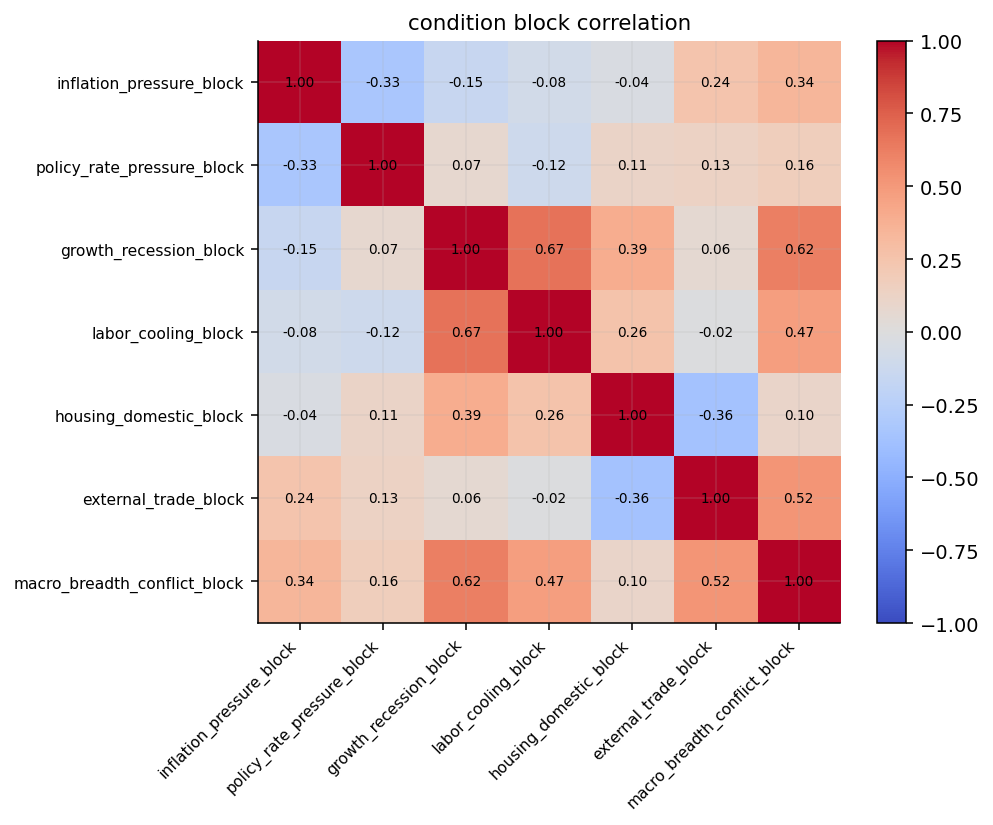

In [28]:
block_corr = macro[block_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(block_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(block_corr.columns)))
ax.set_xticklabels(block_corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(block_corr.index)))
ax.set_yticklabels(block_corr.index, fontsize=8)
for i in range(block_corr.shape[0]):
    for j in range(block_corr.shape[1]):
        value = block_corr.iloc[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("condition block correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [29]:
display(macro[block_cols].tail(12).round(2))
display(macro["macro_breadth_conflict_block"].dropna().sort_values(ascending=False).head(5).to_frame("macro_breadth_conflict_block").round(2))


,inflation_pressure_block,policy_rate_pressure_block,growth_recession_block,labor_cooling_block,housing_domestic_block,external_trade_block,macro_breadth_conflict_block
date,,,,,,,
2025-02-28,1.17,-0.35,0.02,-0.58,-0.35,0.54,0.39
2025-03-31,0.86,-0.27,0.08,-0.59,-0.12,0.66,0.13
2025-04-30,0.22,-0.11,-0.10,-0.55,-0.20,-0.14,-0.32
2025-05-31,-0.07,0.11,-0.22,-0.58,0.04,-0.06,-0.13
2025-06-30,0.64,-0.09,-0.21,-0.61,-0.08,-0.05,-0.22
2025-07-31,0.92,-0.14,-0.30,-0.59,-0.06,-0.05,-0.01
2025-08-31,0.82,-0.24,-0.14,-0.56,-0.11,-0.11,0.02
2025-09-30,0.59,-0.25,-0.16,-0.51,-0.17,-0.18,-0.23
2025-10-31,0.32,-0.25,-0.05,-0.49,-0.07,-0.51,-0.33


,macro_breadth_conflict_block
date,
2008-07-31,1.82
2001-01-31,1.82
2000-03-31,1.81
2008-08-31,1.65
2008-09-30,1.62


## 14) Recent Macro Blocks and Historical Conflict Peaks

The recent block table shows the last 12 months of the macro state. In January 2026, the largest positive block is **inflation pressure**, around **0.75**. Policy pressure is negative, growth recession is negative, labor cooling is negative, housing stress is negative, external trade is negative, and macro breadth/conflict is slightly negative.

The recent picture is therefore not a broad stress regime. Inflation pressure remains the main concern, while the rest of the macro system is not confirming a recessionary shock.

The historical top macro-breadth/conflict readings are concentrated around **2000–2001** and **2008**. That is exactly what we want from a breadth/conflict block. It becomes high when many macro categories start sending stress information at the same time. A high conflict/breadth reading is usually more important than a single block spike because it tells us the stress has spread across the macro system.


In [30]:
selected_dates = ["2008-10", "2020-03", "2022-09", str(macro.index.max().date())[:7]]
contribution_rows = []
for text in selected_dates:
    date = pd.to_datetime(text).to_period("M").to_timestamp("M")
    loc = macro.index.searchsorted(date, side="right") - 1
    date = macro.index[loc]
    for block, value in macro.loc[date, block_cols].items():
        contribution_rows.append({"date": date, "block": block, "value": value})
block_contribution_table = pd.DataFrame(contribution_rows).pivot(index="date", columns="block", values="value")
display(block_contribution_table.round(2))


block,external_trade_block,growth_recession_block,housing_domestic_block,inflation_pressure_block,labor_cooling_block,macro_breadth_conflict_block,policy_rate_pressure_block
date,,,,,,,
2008-10-31,0.47,1.66,0.71,-1.24,2.05,1.46,0.71
2020-03-31,-0.82,0.87,-0.13,-0.60,0.52,-0.17,-0.79
2022-09-30,-0.11,-0.01,-0.06,-0.18,-0.82,0.28,0.78
2026-01-31,-0.32,-0.17,-0.22,0.75,-0.50,-0.13,-0.28


## 15) Crisis Block Contributions

The crisis contribution table is one of the most useful macro diagnostics in the project because it explains **why** each stress period is different.

In **October 2008**, the stress is broad and classic recessionary. Labor cooling is very high at **2.05**, growth recession is **1.66**, macro breadth/conflict is **1.46**, housing/domestic stress is positive, policy/rate pressure is positive, and external trade stress is positive. Inflation pressure is negative because the crisis was deflationary rather than inflationary.

In **March 2020**, growth recession is positive and labor cooling is positive, but policy pressure is strongly negative because policy was easing aggressively. Inflation pressure is also negative. This matches the COVID shock: a sudden real-economy collapse with emergency policy support.

In **September 2022**, policy/rate pressure is the main positive block at **0.78**, while the growth and labor blocks are not strongly stressed. This captures the rate-shock nature of 2022. The macro pain came more from inflation and policy repricing than from a classic labor-led recession.

In **January 2026**, inflation pressure is positive, but most other blocks are negative. The macro condition is mixed rather than crisis-like.


### Why We Need More Than One FCI

A macro index is a model, and every model has a bias.

An economic-weighted index is stable and explainable, but its weights are chosen before seeing the data relationship. A PCA index is data-driven and long-history friendly, but it chases the largest common variation, which may not always be the most market-relevant variation. A supervised PLS index targets future stress, but it can overfit the few crisis episodes in the sample. A logistic stress probability gives a clean high-risk interpretation, but it compresses the target into a binary label.

Using several FCIs lets us see whether the macro conclusion is robust. If all models say conditions are tight, the message is strong. If only supervised models say tight while economic and PCA models are neutral, the interpretation becomes more cautious.

This multi-model design is especially important in macro because we only have a few true crisis episodes. A model that looks excellent on three recessions may simply be memorizing the structure of those three events. Comparing model families helps reduce that risk.


## 16) The FCI Modeling Layer

Once the seven blocks are built, we create multiple FCI models. Each model answers a different statistical question.

Let the block vector be:

$$
B_t=\begin{bmatrix}B_{1,t} & B_{2,t} & \cdots & B_{7,t}\end{bmatrix}^\top
$$

where each block is stress-oriented. We want a scalar index:

$$
F_t=f(B_t)
$$

where higher $F_t$ means tighter conditions.

The project builds five versions:

| Model | Main idea | What it can do well |
|---|---|---|
| **Economic FCI** | Weighted block average | Interpretable and stable |
| **PCA FCI** | First common statistical factor | Finds the dominant co-movement in blocks |
| **PLS FCI** | Supervised factor targeting future stress | Learns which block combinations predict market stress |
| **Probability FCI** | Logistic probability of high future stress | Produces a stress-likelihood style signal |
| **Blend FCI** | Weighted mixture of PLS, PCA, and economic FCI | Combines supervised and unsupervised information |

We don't pick one model immediately. We compare them through future stress tests, crisis behavior, and external NFCI validation.


### Rolling Percentiles

The raw FCI value is useful, but the percentile is often easier to interpret. A value of $F_t=1.2$ means something only relative to the model's own distribution. The rolling or expanding percentile asks:

$$
\text{pct}_t=\frac{1}{n_t}\sum_{j\leq t}\mathbf{1}\{F_j\leq F_t\}
$$

where $n_t$ is the number of past valid FCI observations. A percentile of 0.80 means the current FCI is tighter than about 80% of its own history up to that point.

This matters for allocation. We can use the percentile to gate risk:

- Below 0.40: conditions are relatively easy or neutral.
- Around 0.40 to 0.60: conditions are mixed.
- Above 0.60 or 0.80: conditions are tight enough to justify reducing risky exposure.

Percentiles help compare different FCI models even when they have different raw scales.


## 17) Economic-Weighted FCI

The economic FCI is the most transparent model. We assign weights to the seven blocks and compute a weighted average:

$$
F_t^{econ,raw}=\frac{\sum_{j=1}^{7}w_j B_{j,t}\mathbf{1}\{B_{j,t}\text{ available}\}}{\sum_{j=1}^{7}w_j\mathbf{1}\{B_{j,t}\text{ available}\}}
$$

Then we standardize it through time:

$$
F_t^{econ}=z(F_t^{econ,raw})
$$

The denominator is important because it handles missing block values. If one block is unavailable at some date, the model renormalizes the available weights instead of treating the missing value as zero.

The weights are economically motivated. Inflation, policy, and growth receive the largest weights because they are the primary macro drivers of discount rates, earnings, and risk appetite. Labor, housing, external trade, and macro breadth/conflict receive smaller but still meaningful weights.

The advantage is interpretability. If the economic FCI rises, we know exactly which blocks contributed. The weakness is that the weights are chosen by economic reasoning rather than estimated from data, so it may miss relationships that change across regimes.


In [31]:
def zscore(series, min_obs=60):
    series = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    mean = series.expanding(min_periods=min_obs).mean()
    std = series.expanding(min_periods=min_obs).std(ddof=1).replace(0.0, np.nan)
    return ((series - mean) / std).clip(-5, 5)

def rolling_percentile(series, min_obs=60):
    series = pd.Series(series, dtype=float)
    values = []
    for i in range(len(series)):
        sample = series.iloc[:i + 1].dropna()
        if len(sample) < min_obs or not np.isfinite(series.iloc[i]):
            values.append(np.nan)
        else:
            values.append(float((sample <= series.iloc[i]).mean()))
    return pd.Series(values, index=series.index)


In [32]:
econ_weights = pd.Series({"inflation_pressure_block": 0.18, "policy_rate_pressure_block": 0.18, "growth_recession_block": 0.18, "labor_cooling_block": 0.12, "housing_domestic_block": 0.10, "external_trade_block": 0.10, "macro_breadth_conflict_block": 0.14})
econ_data = macro_full[econ_weights.index].astype(float)
econ_weighted_sum = econ_data.mul(econ_weights, axis=1).sum(axis=1, skipna=True)
econ_available_weight = econ_data.notna().mul(econ_weights, axis=1).sum(axis=1).replace(0.0, np.nan)
fci_econ_full = zscore(econ_weighted_sum / econ_available_weight, 12).rename("fci_econ")
fci_econ = fci_econ_full.reindex(macro.index)


## 18) PCA FCI

The PCA FCI is unsupervised. It asks which linear combination of the macro blocks explains the most common variation across the block panel.

For each date, we train PCA using the historical block matrix available up to that date. The block matrix is standardized first:

$$
\tilde{B}_{j,t}=\frac{B_{j,t}-\hat{\mu}_{j,t}}{\hat{\sigma}_{j,t}}
$$

where $\hat{\mu}_{j,t}$ and $\hat{\sigma}_{j,t}$ are estimated from the historical sample available at date $t$.

PCA finds a vector $v_1$ that solves:

$$
v_1=\arg\max_{\|v\|=1}\text{Var}(\tilde{B}_t^\top v)
$$

The PCA score is:

$$
F_t^{pca}=\tilde{B}_t^\top v_1
$$

This score is then sign-aligned so that higher values correspond to higher average stress. Without sign alignment, PCA can flip signs because both $v_1$ and $-v_1$ explain the same variance.

Financially, PCA is asking: what is the dominant common macro pressure running through the blocks? During a broad crisis, many blocks move together, so PC1 can become a clean stress factor. During a narrow shock, like inflation without labor stress, PCA may be less aggressive because not all blocks agree.


### PCA Loadings Intuition Without Overcomplicating It

Even when we don't print loadings in this section, the PCA score has a clear interpretation. The first principal component is a weighted average of standardized blocks:

$$
F_t^{pca}=v_{1,I}\tilde{B}_{I,t}+v_{1,P}\tilde{B}_{P,t}+v_{1,G}\tilde{B}_{G,t}+\cdots+v_{1,C}\tilde{B}_{C,t}
$$

Each loading $v_{1,j}$ tells us how much block $j$ contributes to the dominant common macro factor. If crisis periods make growth, labor, housing, and breadth move together, PCA will often assign similar signs to those blocks. If inflation behaves differently from classic recession blocks, its loading can be smaller or even different depending on the sample.

The sign alignment step compares the historical PCA score with average stress. If the correlation is negative, we multiply the score by $-1$. This doesn't change the statistical content, but it makes interpretation consistent: higher PCA FCI means tighter conditions.

This is one of the cleanest uses of PCA in the project series. We are not trying to forecast with dozens of components. We are extracting the first macro stress factor and checking whether it lines up with crises and future risk.


In [33]:
def pca_index(blocks, min_obs=60, min_cols=6):
    out = pd.Series(np.nan, index=blocks.index, name="fci_pca")
    average_stress = blocks.mean(axis=1, skipna=True)
    for date in blocks.index:
        hist = blocks.loc[:date]
        good_cols = [col for col in blocks.columns if hist[col].notna().sum() >= min_obs]
        row = blocks.loc[date, good_cols]
        good_cols = [col for col in good_cols if np.isfinite(row.get(col, np.nan))]
        if len(good_cols) < min_cols:
            continue
        sample = hist[good_cols].dropna(how="any")
        if len(sample) < min_obs:
            continue
        scaler = StandardScaler()
        train = scaler.fit_transform(sample)
        model = PCA(n_components=1)
        model.fit(train)
        current = scaler.transform(blocks.loc[[date], good_cols])
        score = float(model.transform(current)[0, 0])
        hist_score = pd.Series(model.transform(train)[:, 0], index=sample.index)
        align = pd.concat([hist_score, average_stress.reindex(sample.index)], axis=1).dropna()
        if len(align) > 12 and align.iloc[:, 0].corr(align.iloc[:, 1]) < 0:
            score = -score
        out.loc[date] = score
    return zscore(out, 12).rename("fci_pca")
fci_pca_full = pca_index(macro_full[block_cols], 36, 6)
fci_pca = fci_pca_full.reindex(macro.index)


## 19) The Future Stress Target

The supervised models need a target. We define future stress from the next three months of SPY behavior. The target combines three pieces:

1. Future 3-month return, with losses treated as stress.
2. Future 3-month volatility.
3. Future 3-month maximum drawdown, with deeper drawdowns treated as stress.

The cumulative future return is:

$$
R_{t\to t+3}=\prod_{h=1}^{3}(1+r_{t+h}^{SPY})-1
$$

The future volatility is:

$$
\sigma_{t\to t+3}=\sqrt{12}\,\text{Std}(r_{t+1}^{SPY},r_{t+2}^{SPY},r_{t+3}^{SPY})
$$

The future drawdown is computed from the cumulative path inside the next three months:

$$
DD_{t\to t+3}=\min_{1\leq h\leq 3}\left(\frac{NAV_{t+h}}{\max_{1\leq j\leq h}NAV_{t+j}}-1\right)
$$

The final stress target is:

$$
Y_t=z(-R_{t\to t+3})+z(\sigma_{t\to t+3})+z(-DD_{t\to t+3})
$$

High $Y_t$ means future returns were weak, future volatility was high, and future drawdowns were severe. This is the market outcome we want the FCI to anticipate.


### Why the Target Combines Return, Volatility, and Drawdown

A future stress target based only on return would miss important market states. Sometimes returns are mildly positive but volatility is high. Sometimes returns recover by month-end, but the path includes a severe intra-window drawdown. A risk manager cares about the path, not only the endpoint.

That is why the target combines three dimensions.

The return term captures realized direction. The volatility term captures uncertainty and choppiness. The drawdown term captures path pain. Together, they describe the kind of future environment that a macro FCI should warn about.

For example, if SPY loses 2% over three months with low volatility and shallow drawdown, the stress target may only be mildly elevated. If SPY ends flat but falls 8% inside the window and volatility spikes, the target can still be high. That makes the supervised FCI more aligned with portfolio risk than a simple next-return forecast.


### Embargo and Lookahead Control

When we train supervised FCI models, we need to avoid leaking future information. The target uses returns from the next three months, so we apply an embargo. At date $t$, training only uses observations whose target window ends before the current date.

Conceptually, for a current month $t$, the training sample is:

$$
\mathcal{T}_t=\{s: s<t-3\text{ months}\}
$$

This avoids using a target that overlaps with the period we are trying to predict.

This detail is important because macro signals are slow moving. Without an embargo, nearby observations can share future return windows and make the supervised model look more predictive than it really is. The project is careful about this by training PLS and logistic probability models with a three-month gap.


### Supervision Changes the Meaning of the Index

The unsupervised FCIs, economic and PCA, summarize macro conditions themselves. The supervised FCIs, PLS and probability, summarize macro conditions through their historical relationship with future market stress. That changes the meaning of the number.

If a supervised FCI is high, it doesn't necessarily mean every macro block is high. It means the current combination of blocks resembles historical combinations that were followed by high future stress. A moderate inflation block, weak survey data, and a certain policy configuration may be more predictive than a single extreme block.

Mathematically, the supervised index is closer to a fitted conditional expectation:

$$
F_t^{sup}\approx E[Y_t\mid B_t]
$$

where $Y_t$ is the future stress target. The unsupervised index is closer to a common macro-state score:

$$
F_t^{unsup}=g(B_t)
$$

This distinction explains why the latest PLS and blend readings can be tighter than the economic and PCA readings. The broad macro state is not strongly stressed, but the supervised relationship sees a higher-risk combination.


In [34]:
spy_return = returns_raw["spy"]
future_1m_return = spy_return.shift(-1)
future_3m_return = (1.0 + spy_return.shift(-1)).rolling(3).apply(np.prod, raw=True).shift(-2) - 1.0
future_3m_volatility = spy_return.shift(-1).rolling(3).std(ddof=1).shift(-2) * np.sqrt(12.0)
future_drawdown_values = []
for i in range(len(spy_return)):
    sample = spy_return.iloc[i + 1:i + 4].dropna()
    if len(sample) < 3:
        future_drawdown_values.append(np.nan)
    else:
        nav = (1.0 + sample).cumprod()
        future_drawdown_values.append(float((nav / nav.cummax() - 1.0).min()))
future_3m_max_drawdown = pd.Series(future_drawdown_values, index=spy_return.index, name="future_3m_max_drawdown")
target_table = pd.concat([future_1m_return.rename("future_1m_return"), future_3m_return.rename("future_3m_return"), future_3m_volatility.rename("future_3m_volatility"), future_3m_max_drawdown], axis=1)
target_table["future_stress"] = zscore(-target_table["future_3m_return"], 36) + zscore(target_table["future_3m_volatility"], 36) + zscore(-target_table["future_3m_max_drawdown"], 36)
target_table = target_table.reindex(macro_full.index.union(target_table.index)).sort_index()


## 20) PLS FCI

Partial Least Squares, or PLS, is a supervised dimension-reduction method. PCA finds the direction in macro blocks with the most variance. PLS finds a direction in macro blocks with the strongest relationship to the target.

Let $X$ be the standardized block matrix and $y$ be the future stress target. A one-component PLS model finds a weight vector $w$ such that the latent factor:

$$
t=Xw
$$

has high covariance with $y$. A simplified objective is:

$$
w^*=\arg\max_{\|w\|=1}\text{Cov}(Xw,y)^2
$$

The fitted current score is then:

$$
F_t^{pls}=\hat{y}_t=\alpha + B_t^\top\hat{\beta}
$$

after the PLS transformation and regression steps.

The financial interpretation is direct: PLS tries to learn which combination of macro blocks historically came before worse future SPY stress. It may put more weight on blocks that matter for asset markets, even if those blocks are not the largest source of macro variation.

The risk is sample dependence. A supervised model can overfit a few crisis patterns, especially when the number of macro cycles is small. That is why we later score the models across full-sample, common-sample, and test windows.


In [35]:
def pls_index(blocks, target, min_obs=60, min_cols=6, embargo_months=3):
    out = pd.Series(np.nan, index=blocks.index, name="fci_pls")
    target = pd.Series(target, dtype=float)
    for date in blocks.index:
        cutoff = pd.Timestamp(date) - pd.offsets.MonthEnd(embargo_months)
        hist_x = blocks.loc[blocks.index < cutoff]
        hist_y = target.reindex(hist_x.index)
        good_cols = [col for col in blocks.columns if hist_x[col].notna().sum() >= min_obs]
        row = blocks.loc[date, good_cols]
        good_cols = [col for col in good_cols if np.isfinite(row.get(col, np.nan))]
        if len(good_cols) < min_cols:
            continue
        train = pd.concat([hist_x[good_cols], hist_y.rename("target")], axis=1).dropna()
        if len(train) < min_obs:
            continue
        scaler = StandardScaler()
        train_x = scaler.fit_transform(train[good_cols])
        components = min(2, len(good_cols), len(train) - 1)
        model = PLSRegression(n_components=components)
        model.fit(train_x, train["target"].to_numpy(dtype=float))
        current = scaler.transform(blocks.loc[[date], good_cols])
        prediction = np.asarray(model.predict(current), dtype=float).reshape(-1)
        out.loc[date] = float(prediction[0])
    return zscore(out, 36).rename("fci_pls")
fci_pls_full = pls_index(macro_full[block_cols], target_table["future_stress"], 36, 6, 3)
fci_pls = fci_pls_full.reindex(macro.index)


## 21) Stress-Probability FCI

The stress-probability model turns the future stress target into a binary event. The event is defined as future stress being above a rolling high-stress threshold, usually the 75th percentile of historical target values.

Let:

$$
Y_t^{bin}=\mathbf{1}\{Y_t>q_{0.75,t}^{expanding}\}
$$

Then we train a logistic regression:

$$
P(Y_t^{bin}=1\mid B_t)=\frac{1}{1+\exp[-(\alpha+B_t^\top\beta)]}
$$

The output is a probability between 0 and 1. A high value means the macro block state looks similar to historical states that were followed by high market stress.

We then standardize the probability through time so it can be compared with the other FCIs:

$$
F_t^{prob}=z(P(Y_t^{bin}=1\mid B_t))
$$

This model is appealing because it matches how risk managers often think: the question is not only expected return, but whether we are entering a high-stress zone. The weakness is that binary labels discard information. A mildly bad future and an extremely bad future can both become the same class if they are above the threshold.


In [36]:
def prob_index(features, target, min_obs=60, embargo_months=3):
    x = features.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    y = pd.Series(target, dtype=float).reindex(x.index)
    threshold = y.expanding(min_periods=min_obs).quantile(0.75).shift(1)
    label = (y > threshold).where(threshold.notna())
    out = pd.Series(np.nan, index=x.index, name="fci_prob")
    for date in x.index:
        current = x.loc[date].dropna()
        cutoff = pd.Timestamp(date) - pd.offsets.MonthEnd(embargo_months)
        history = x.loc[x.index < cutoff]
        cols = [col for col in current.index if history[col].notna().sum() >= min_obs]
        if len(cols) < 4:
            continue
        train = pd.concat([history[cols], label.loc[history.index].rename("label")], axis=1).dropna()
        if len(train) < min_obs or train["label"].nunique() < 2:
            continue
        scaler = StandardScaler()
        train_x = scaler.fit_transform(train[cols])
        model = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs")
        model.fit(train_x, train["label"].astype(int))
        current_x = scaler.transform(x.loc[[date], cols])
        out.loc[date] = float(model.predict_proba(current_x)[0, 1])
    return out
prob_features = pd.concat([macro_full[block_cols], fci_econ_full, fci_pca_full, fci_pls_full], axis=1)
fci_prob_full = prob_index(prob_features, target_table["future_stress"], 36, 3)
fci_prob_z_full = zscore(fci_prob_full, 12).rename("fci_prob")
fci_prob_z = fci_prob_z_full.reindex(macro.index)


## 22) Blended FCI

The blended FCI combines three sources:

$$
F_t^{blend}=z(0.50F_t^{pls}+0.30F_t^{pca}+0.20F_t^{econ})
$$

The weights give the largest role to PLS because it is explicitly targeted to future stress. PCA receives a meaningful weight because it captures the common macro factor without needing a market target. The economic index receives a smaller but important weight because it is stable and interpretable.

This blend is a compromise between prediction and robustness. Supervised models can be more responsive to market stress, but they can also overfit. Unsupervised models can have better long-history behavior, but they may ignore the exact combination that matters for future equity stress. A blend gives the strategy more than one source of information.

The model availability table shows the expected pattern. Economic FCI starts earliest, PCA starts after enough block history is available, and the supervised models start later because they need both macro history and target history.


,first_date,last_date,observations
fci_econ,1995-11-30,2026-01-31,363
fci_pca,1998-10-31,2026-01-31,328
fci_pls,2008-03-31,2026-01-31,215
fci_prob,2009-03-31,2026-01-31,203
fci_blend,2009-02-28,2026-01-31,204


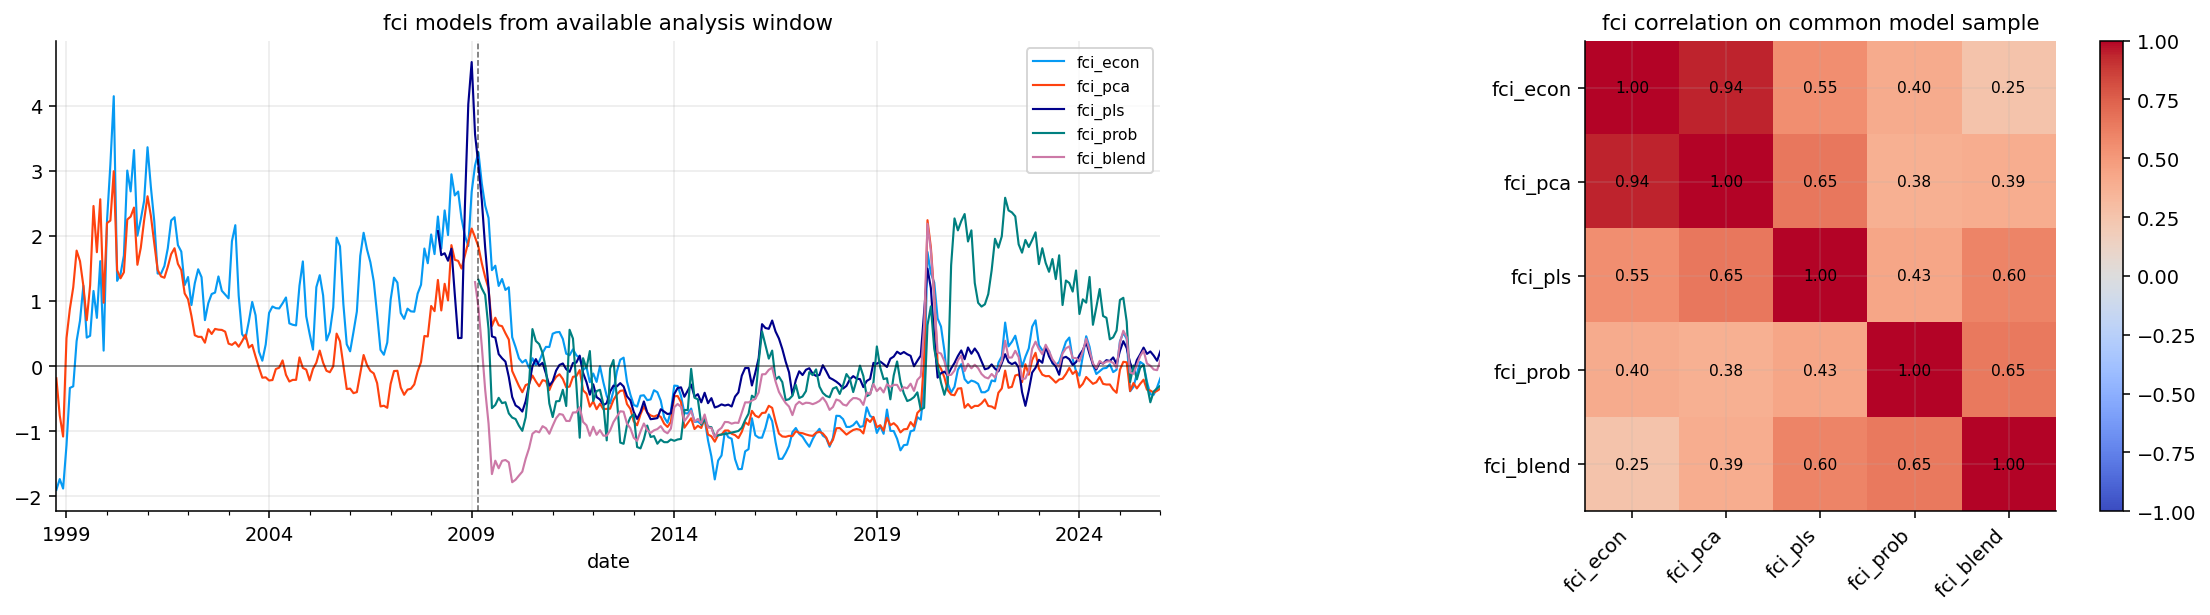

In [37]:
fci_blend_full = zscore(0.50 * fci_pls_full + 0.30 * fci_pca_full + 0.20 * fci_econ_full, 12).rename("fci_blend")
fci_blend = fci_blend_full.reindex(macro.index)
fci_models = pd.concat([fci_econ, fci_pca, fci_pls, fci_prob_z, fci_blend], axis=1).reindex(macro.index)
fci_availability = pd.DataFrame({
    "first_date": fci_models.apply(pd.Series.first_valid_index),
    "last_date": fci_models.apply(pd.Series.last_valid_index),
    "observations": fci_models.notna().sum(),
})
fci_plot_start = fci_models.dropna(thresh=2).index.min()
fci_common_start = fci_models.dropna(how="any").index.min()
fci_common = fci_models.loc[fci_common_start:].dropna(how="any") if pd.notna(fci_common_start) else pd.DataFrame()
display(fci_availability)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
fci_models.loc[fci_plot_start:].plot(ax=axes[0], lw=1.1, color=colors[:len(fci_models.columns)])
axes[0].axhline(0.0, color="black", lw=0.8, alpha=0.5)
if pd.notna(fci_common_start):
    axes[0].axvline(fci_common_start, color="black", lw=0.8, ls="--", alpha=0.6)
axes[0].set_title("fci models from available analysis window")
axes[0].grid(True, alpha=0.25)
fci_corr = fci_common.corr() if len(fci_common) else fci_models.corr()
im = axes[1].imshow(fci_corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(fci_corr.columns)))
axes[1].set_xticklabels(fci_corr.columns, rotation=45, ha="right")
axes[1].set_yticks(range(len(fci_corr.columns)))
axes[1].set_yticklabels(fci_corr.columns)
for i in range(fci_corr.shape[0]):
    for j in range(fci_corr.shape[1]):
        value = fci_corr.iloc[i, j]
        if np.isfinite(value):
            axes[1].text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)
axes[1].set_title("fci correlation on common model sample")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


,date,value,percentile,change_3m,interpretation
model,,,,,
fci_econ,2026-01-31,-0.182,0.397,0.251,neutral
fci_pca,2026-01-31,-0.343,0.424,0.032,neutral
fci_pls,2026-01-31,0.234,0.819,0.008,tight
fci_prob,2026-01-31,-0.299,0.458,0.257,neutral
fci_blend,2026-01-31,0.094,0.828,0.087,tight


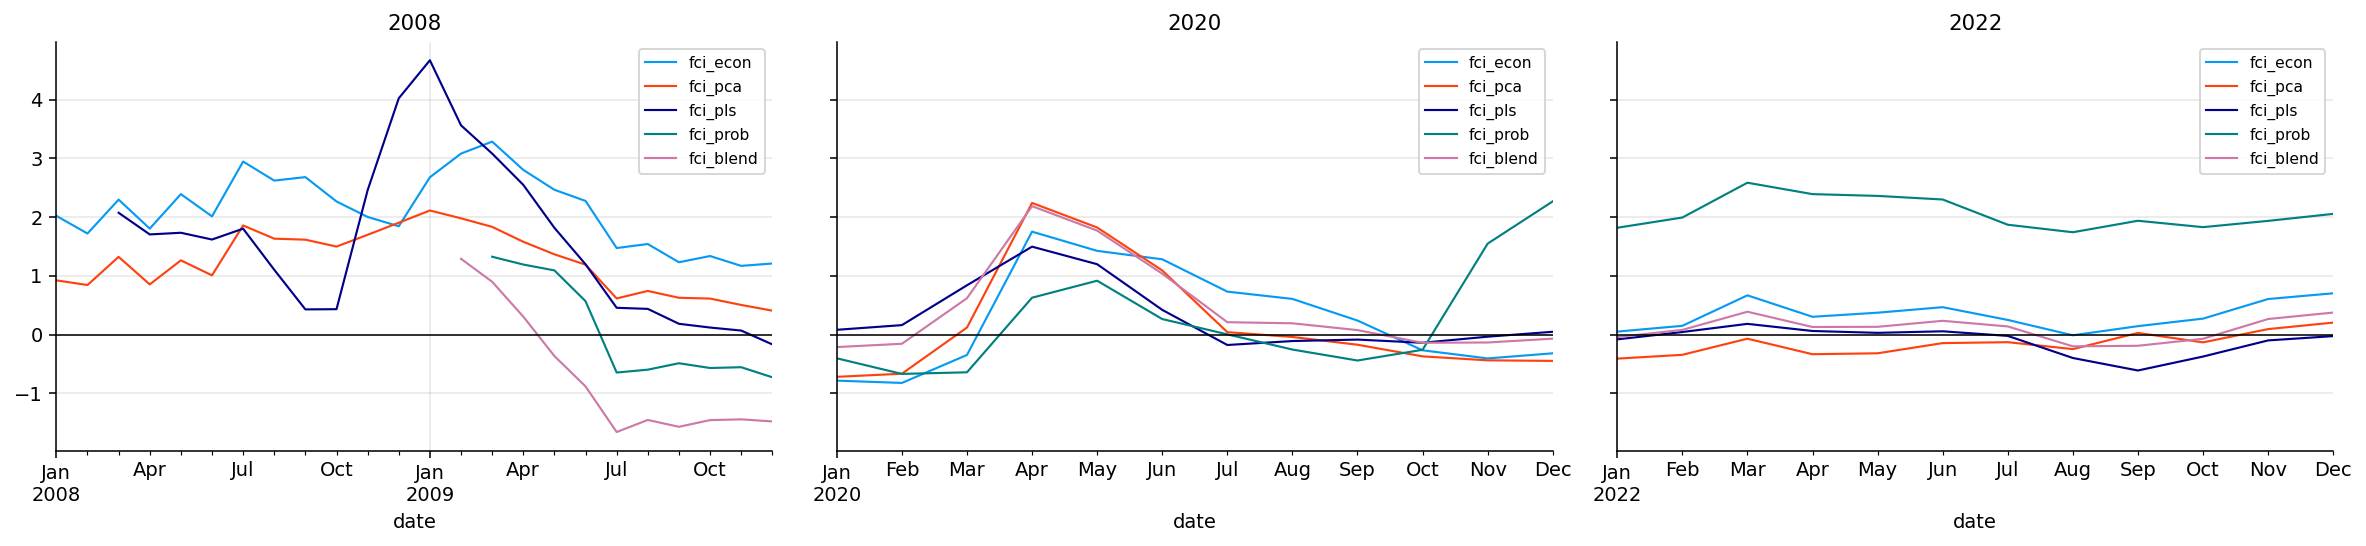

In [38]:
latest_rows = []
for col in fci_models.columns:
    series = fci_models[col].dropna()
    if series.empty:
        continue
    pct = rolling_percentile(fci_models[col], 60)
    change = fci_models[col].diff(3)
    date = series.index.max()
    latest_pct = float(pct.loc[date]) if np.isfinite(pct.loc[date]) else np.nan
    interpretation = "tight" if latest_pct >= 0.8 else "easy" if latest_pct <= 0.2 else "neutral"
    latest_rows.append({"model": col, "date": date, "value": float(series.loc[date]), "percentile": latest_pct, "change_3m": change.loc[date], "interpretation": interpretation})
latest_fci_table = pd.DataFrame(latest_rows).set_index("model")
display(latest_fci_table.round(3))
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for ax, start, end, title in zip(axes, ["2008-01", "2020-01", "2022-01"], ["2009-12", "2020-12", "2022-12"], ["2008", "2020", "2022"]):
    fci_models.loc[start:end].plot(ax=ax, lw=1.1)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The FCI plot compares all five models. They agree strongly around major crisis periods, but they diverge in calmer or mixed regimes. That divergence is useful information rather than a problem to hide.

The latest model table gives a very clear split. In January 2026:

- **fci_econ** is neutral, with value about **-0.18** and percentile around **0.40**.
- **fci_pca** is also neutral, with value about **-0.34** and percentile around **0.42**.
- **fci_pls** is tight, with percentile around **0.82**.
- **fci_prob** is neutral, around percentile **0.46**.
- **fci_blend** is tight, around percentile **0.83**.

The unsupervised models say broad macro stress is not high. The supervised PLS and blend are more cautious, likely because the combination of sticky inflation and survey weakness resembles past market-risk setups more than the broad blocks alone suggest. That difference matters later when choosing which index should control an allocation strategy.


### Model Agreement and Disagreement

The latest FCI readings show a useful kind of model disagreement. Economic and PCA indexes are neutral, while PLS and blend are tight. This means the broad macro blocks are not screaming crisis, but the supervised relation to future stress is more cautious.

A portfolio manager can use that disagreement in several ways:

- If all indexes are high, reduce risk with more confidence.
- If only supervised indexes are high, watch for market fragility but avoid an extreme risk-off move.
- If only unsupervised indexes are high, the macro environment may be broadly stressed even if the specific equity-stress target has not learned that pattern strongly.
- If all indexes are low, macro conditions are likely supportive or at least not restrictive.

This project later selects PCA for the main strategy because it has long history and avoids supervised model-selection lookahead. But the latest model table still provides useful diagnostic context. It tells us that the current macro regime has some supervised stress features despite neutral broad stress.


In [39]:
nfci_validation = pd.concat([nfci_month["nfci"], fci_models], axis=1).loc[macro_start:].dropna(subset=["nfci"])


In [40]:
crisis_windows = {"financial_crisis": ("2008-09", "2009-03"), "covid_crash": ("2020-02", "2020-04"), "inflation_rate_shock": ("2022-01", "2022-10")}


## 23) Quintile Validation

A good FCI should have a monotonic relationship with future market stress. We test this by sorting each FCI into quintiles and checking future SPY outcomes.

For each model, we rank the FCI values and place them into five groups:

$$
q_t \in \{Q1,Q2,Q3,Q4,Q5\}
$$

where $Q1$ means easiest conditions and $Q5$ means tightest conditions.

Then we compute the average future 1-month return, future 3-month return, future volatility, future max drawdown, and future stress target inside each quintile.

The clean pattern we want is:

- higher FCI quintiles have lower future returns,
- higher FCI quintiles have higher future volatility,
- higher FCI quintiles have deeper future drawdowns,
- the future stress target rises from low quintiles to high quintiles.

This is a practical validation test. It doesn't require the model to predict every month correctly. It checks whether the distribution of future outcomes worsens when macro conditions are tighter.


In [41]:
def quintile_report(fci, target):
    data = pd.concat([fci.rename("fci"), target], axis=1).dropna(subset=["fci", "future_stress"])
    if len(data) < 30:
        return pd.DataFrame()
    ranks = data["fci"].rank(method="first")
    data["fci_quintile"] = pd.qcut(ranks, 5, labels=["q1", "q2", "q3", "q4", "q5"])
    report = data.groupby("fci_quintile", observed=False)[["future_1m_return", "future_3m_return", "future_3m_volatility", "future_3m_max_drawdown", "future_stress"]].mean()
    report["observations"] = data.groupby("fci_quintile", observed=False).size()
    return report
quintile_reports = {name: quintile_report(fci_models[name], target_table) for name in fci_models.columns}
for name, report in quintile_reports.items():
    print(name)
    display(report.round(4))


fci_econ


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0119,0.0256,0.1046,-0.0216,-0.5124,58
q2,0.0141,0.0426,0.1177,-0.0167,-0.7198,58
q3,0.0114,0.0360,0.1367,-0.0260,-0.3345,57
q4,0.0064,0.0210,0.1166,-0.0233,-0.7064,58
q5,-0.0003,0.0066,0.1401,-0.0381,0.0958,58


fci_pca


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0128,0.0232,0.0984,-0.0229,-0.5191,58
q2,0.0083,0.0359,0.1181,-0.0170,-0.6656,58
q3,0.0136,0.0331,0.1137,-0.0229,-0.6676,57
q4,0.0067,0.0303,0.1281,-0.0218,-0.5638,58
q5,0.0021,0.0092,0.1570,-0.0411,0.2331,58


fci_pls


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0090,0.0294,0.1263,-0.0228,-0.4229,43
q2,0.0131,0.0360,0.1162,-0.0185,-0.6199,43
q3,0.0070,0.0181,0.1292,-0.0324,0.0937,43
q4,0.0175,0.0461,0.1456,-0.0220,-0.2839,43
q5,0.0047,0.0224,0.1442,-0.0350,0.2608,43


fci_prob


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0136,0.0309,0.1161,-0.0209,-0.6073,41
q2,0.0084,0.0346,0.1237,-0.0189,-0.5463,40
q3,0.0110,0.0342,0.1152,-0.0211,-0.5351,41
q4,0.0179,0.0503,0.1231,-0.0192,-0.7261,40
q5,0.0143,0.0387,0.1534,-0.0291,0.0949,41


fci_blend


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0152,0.0447,0.1278,-0.0199,-0.7383,41
q2,0.0115,0.0262,0.1104,-0.0215,-0.5882,41
q3,0.0091,0.0325,0.1007,-0.0186,-0.7017,40
q4,0.0120,0.0269,0.1329,-0.0261,-0.0404,41
q5,0.0189,0.0635,0.1578,-0.0225,-0.3508,41


The quintile reports show that the relationship is present, but not perfectly monotonic for every model. That is normal for macro data. Macro conditions shape probabilities, not exact next-month outcomes.

For the economic FCI, the tightest quintile has weaker future returns and worse future drawdowns than easier quintiles. In the fci_econ report, the tightest quintile has a future 3-month return around **0.66%**, compared with **2.56%** in the easiest quintile and **4.26%** in the second quintile. Its future max drawdown is also worse, around **-3.81%**.

For the PCA FCI, the tightest quintile has higher future volatility, around **15.7%**, and the worst future max drawdown, around **-4.11%**. That supports the idea that the unsupervised common macro factor contains risk information.

The supervised models have mixed shapes. PLS and probability capture some high-stress behavior, but the sample is shorter and the relationship can become uneven across quintiles. The blend is especially interesting: the tightest quintile has high future volatility, but it also has strong future returns in this sample. That means a high blend signal may sometimes identify volatile upside environments, not only crash risk.


### How to Read a Non-Monotonic Quintile Table

Macro validation rarely gives perfectly ordered quintiles. There are several reasons.

First, macro variables are slow. A high FCI can persist after the market has already sold off, so forward returns may rebound even though the FCI remains high. Second, policy reaction can offset stress. A tight or stressful macro state may trigger rate cuts, fiscal support, or liquidity provision. Third, financial markets price expectations before macro data confirms them. By the time a macro signal is extreme, some of the bad news may already be in prices.

So we shouldn't demand that every column rises perfectly from Q1 to Q5. We look for distributional evidence: worse drawdowns, higher volatility, lower average future returns, and positive rank association with future stress. The model scoreboard does this by combining several diagnostics instead of relying on one table cell.

This is why fci_pca can win the full sample even with modest rank IC. It may not perfectly order every quintile, but it identifies the distributional deterioration around stress regimes and has long crisis coverage.


## 24) Model Scoreboard

The model scoring function turns the quintile validation into a compact ranking. For each FCI model, we compute several diagnostics.

The **rank information coefficient** measures whether higher FCI values are associated with higher future stress:

$$
IC=\text{Corr}(\text{rank}(F_t),\text{rank}(Y_t))
$$

The **drawdown spread** compares future max drawdown in easy and tight regimes:

$$
\Delta DD=DD_{Q1}-DD_{Q5}
$$

Since drawdowns are negative, a positive spread means the tightest FCI quintile has a worse drawdown than the easiest quintile.

The **volatility spread** is:

$$
\Delta\sigma=\sigma_{Q5}-\sigma_{Q1}
$$

A positive value means future volatility is higher when conditions are tighter.

The **monotonicity score** checks whether future stress rises across quintiles in a roughly ordered way. The **stability score** penalizes overly noisy indexes:

$$
\text{stability}=\frac{1}{1+\text{Std}(\Delta F_t)}
$$

The final score combines these pieces with more weight on future stress IC and drawdown spread.


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,future_stress_rank_ic_rank,drawdown_spread_rank,monotonicity_score_rank,volatility_spread_rank,stability_score_rank,final_score,long_history_eligible
model,,,,,,,,,,,,,,,
fci_pca,328,1998-10-31,2026-01-31,0.0464,0.0183,0.3,0.0586,0.7654,1.0,1.0,0.2,1.0,0.6,0.80,True
fci_econ,363,1995-11-30,2026-01-31,0.0368,0.0164,0.5,0.0355,0.6835,0.6,0.8,0.6,0.6,0.2,0.61,True
fci_prob,203,2009-03-31,2026-01-31,0.0414,0.0083,0.4,0.0374,0.7298,0.8,0.4,0.4,0.8,0.4,0.58,False
fci_blend,204,2009-02-28,2026-01-31,0.0199,0.0026,0.8,0.0300,0.8233,0.4,0.2,0.9,0.4,1.0,0.51,False
fci_pls,215,2008-03-31,2026-01-31,0.0146,0.0123,0.8,0.0179,0.7813,0.2,0.6,0.9,0.2,0.8,0.50,False


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,future_stress_rank_ic_rank,drawdown_spread_rank,monotonicity_score_rank,volatility_spread_rank,stability_score_rank,final_score
model,,,,,,,,,,,,,,
fci_econ,203,2009-03-31,2026-01-31,0.0649,0.0086,0.1,0.0643,0.7942,1.0,1.0,0.5,0.8,0.4,0.81
fci_prob,203,2009-03-31,2026-01-31,0.0414,0.0083,0.4,0.0374,0.7298,0.8,0.8,0.8,0.6,0.2,0.71
fci_blend,203,2009-03-31,2026-01-31,0.0350,0.0036,0.8,0.0324,0.8241,0.6,0.4,1.0,0.4,0.8,0.62
fci_pca,203,2009-03-31,2026-01-31,0.0281,0.0038,0.1,0.0690,0.8149,0.4,0.6,0.5,1.0,0.6,0.58
fci_pls,203,2009-03-31,2026-01-31,-0.1075,-0.0119,-0.2,-0.0138,0.8415,0.2,0.2,0.2,0.2,1.0,0.28


,model_split_date,train_months,test_months
0,2020-02-29,131,72


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,future_stress_rank_ic_rank,drawdown_spread_rank,monotonicity_score_rank,volatility_spread_rank,stability_score_rank,final_score
model,,,,,,,,,,,,,,
fci_prob,72,2020-02-29,2026-01-31,0.1883,0.0232,0.9,0.0162,0.6996,1.0,1.0,1.0,0.8,0.2,0.89
fci_econ,72,2020-02-29,2026-01-31,0.1593,0.0171,0.8,0.0374,0.7444,0.8,0.8,0.8,1.0,0.4,0.79
fci_pca,72,2020-02-29,2026-01-31,-0.0812,-0.0034,-0.1,0.0131,0.7457,0.6,0.6,0.6,0.6,0.6,0.60
fci_blend,72,2020-02-29,2026-01-31,-0.1197,-0.0048,-0.2,-0.0306,0.7732,0.4,0.4,0.4,0.4,0.8,0.44
fci_pls,72,2020-02-29,2026-01-31,-0.3195,-0.0130,-0.9,-0.0432,0.8275,0.2,0.2,0.2,0.2,1.0,0.28


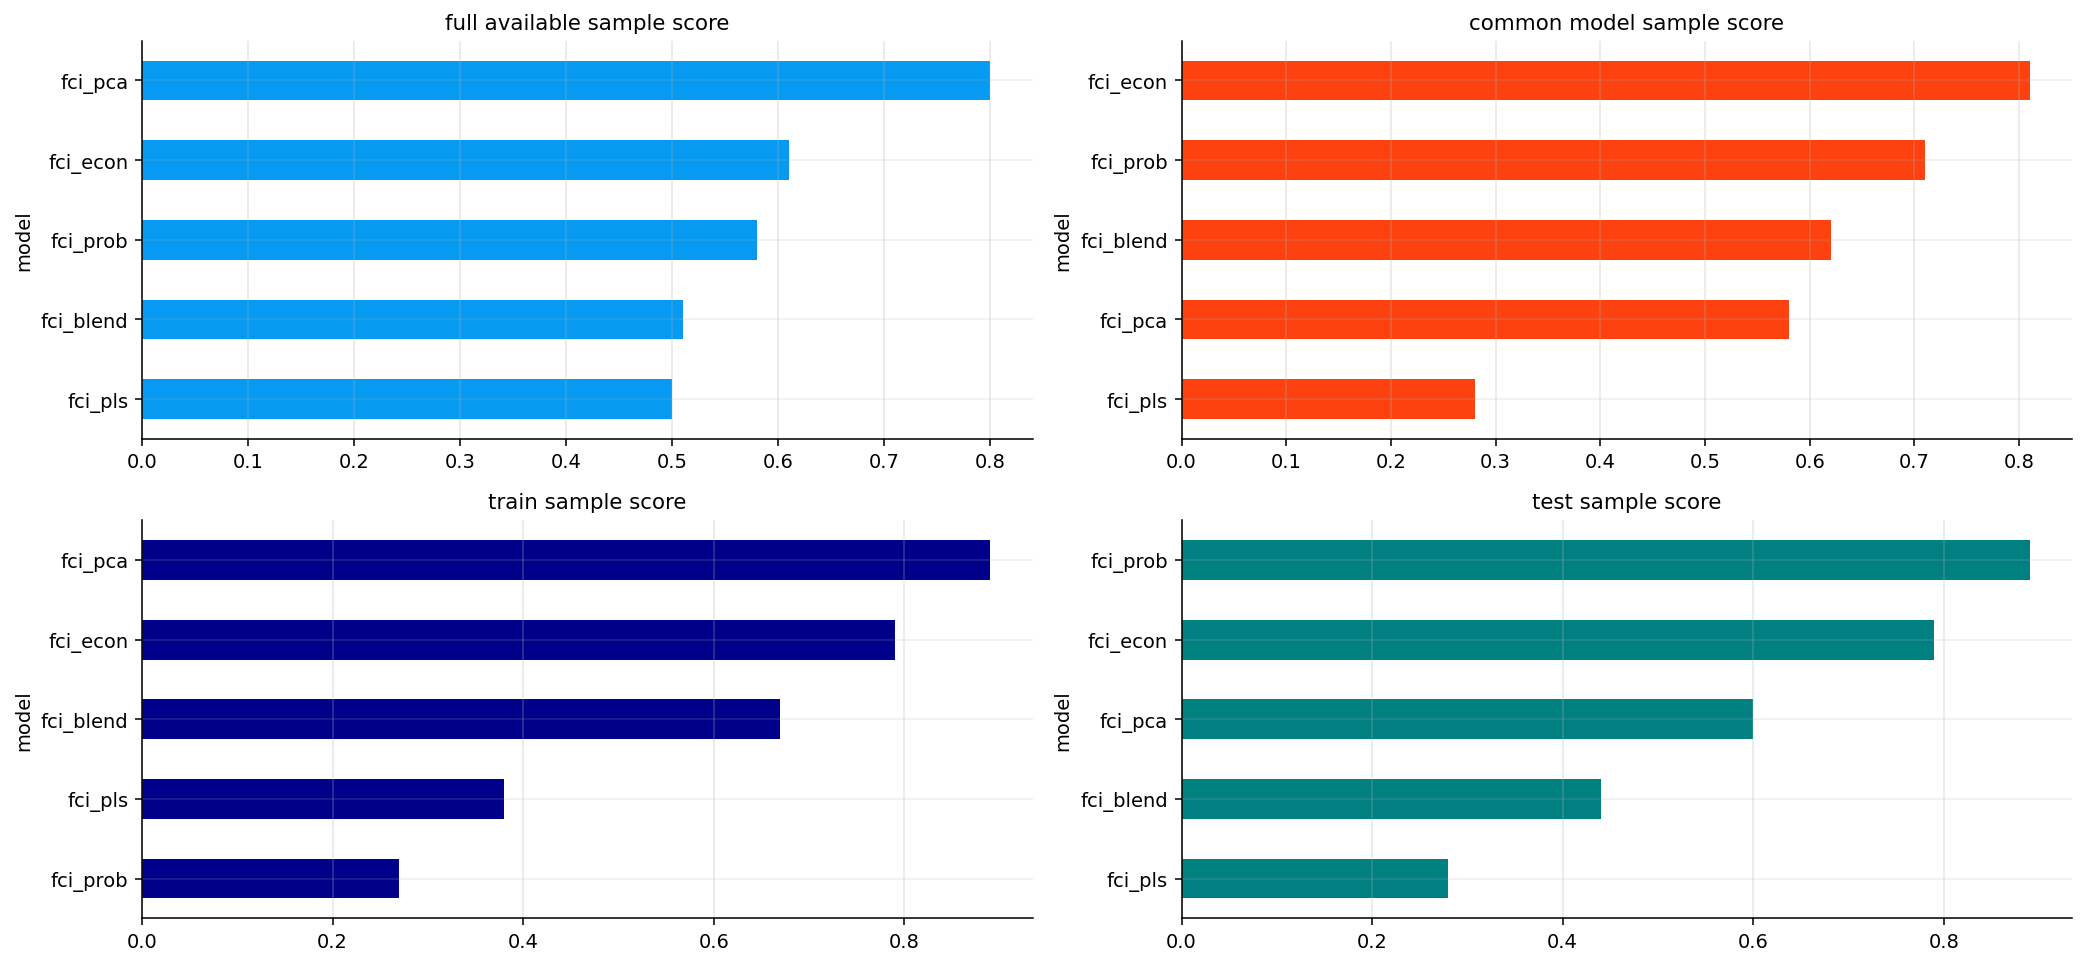

In [42]:
def score_fci_models(models, target):
    rows = []
    for name in models.columns:
        report = quintile_report(models[name], target)
        pair = pd.concat([models[name].rename("fci"), target["future_stress"]], axis=1).dropna()
        rank_ic = pair["fci"].rank().corr(pair["future_stress"].rank()) if len(pair) >= 20 else np.nan
        if report.empty:
            rows.append({"model": name, "observations": int(models[name].notna().sum()), "first_valid_date": models[name].first_valid_index(), "last_valid_date": models[name].last_valid_index(), "future_stress_rank_ic": rank_ic})
            continue
        y = report["future_stress"].dropna()
        monotonicity = pd.Series(range(1, len(y) + 1), index=y.index).corr(y.rank()) if len(y) >= 3 else np.nan
        rows.append({"model": name, "observations": int(models[name].notna().sum()), "first_valid_date": models[name].first_valid_index(), "last_valid_date": models[name].last_valid_index(), "future_stress_rank_ic": rank_ic, "drawdown_spread": report.loc["q1", "future_3m_max_drawdown"] - report.loc["q5", "future_3m_max_drawdown"], "monotonicity_score": monotonicity, "volatility_spread": report.loc["q5", "future_3m_volatility"] - report.loc["q1", "future_3m_volatility"], "stability_score": 1.0 / (1.0 + models[name].diff().std())})
    scores = pd.DataFrame(rows).set_index("model") if rows else pd.DataFrame()
    for col in ["future_stress_rank_ic", "drawdown_spread", "monotonicity_score", "volatility_spread", "stability_score"]:
        if col in scores:
            scores[col + "_rank"] = scores[col].rank(pct=True)
    if len(scores):
        scores["final_score"] = 0.30 * scores["future_stress_rank_ic_rank"] + 0.25 * scores["drawdown_spread_rank"] + 0.20 * scores["monotonicity_score_rank"] + 0.15 * scores["volatility_spread_rank"] + 0.10 * scores["stability_score_rank"]
        scores = scores.sort_values("final_score", ascending=False)
    return scores

full_sample_scoreboard = score_fci_models(fci_models, target_table)
full_sample_scoreboard["long_history_eligible"] = (full_sample_scoreboard["observations"] >= 180) & (full_sample_scoreboard["first_valid_date"] <= pd.Timestamp("2000-12-31"))
common_model_index = pd.concat([fci_models, target_table["future_stress"]], axis=1).dropna().index
common_model_scoreboard = score_fci_models(fci_models.reindex(common_model_index), target_table.reindex(common_model_index))
model_split_date = common_model_index[int(len(common_model_index) * 0.65)] if len(common_model_index) else pd.NaT
train_model_index = common_model_index[common_model_index < model_split_date]
test_model_index = common_model_index[common_model_index >= model_split_date]
train_model_scoreboard = score_fci_models(fci_models.reindex(train_model_index), target_table.reindex(train_model_index))
test_model_scoreboard = score_fci_models(fci_models.reindex(test_model_index), target_table.reindex(test_model_index))
display(full_sample_scoreboard.round(4))
display(common_model_scoreboard.round(4))
display(pd.DataFrame({"model_split_date": [model_split_date], "train_months": [len(train_model_index)], "test_months": [len(test_model_index)]}))
display(test_model_scoreboard.round(4))
fig, axes = plt.subplots(2, 2, figsize=(15, 7))
full_sample_scoreboard["final_score"].sort_values().plot(kind="barh", ax=axes[0, 0], color=colors[0])
common_model_scoreboard["final_score"].sort_values().plot(kind="barh", ax=axes[0, 1], color=colors[1])
train_model_scoreboard["final_score"].sort_values().plot(kind="barh", ax=axes[1, 0], color=colors[2])
test_model_scoreboard["final_score"].sort_values().plot(kind="barh", ax=axes[1, 1], color=colors[3])
for ax, title in zip(axes.ravel(), ["full available sample score", "common model sample score", "train sample score", "test sample score"]):
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


The full-sample scoreboard selects **fci_pca** as the top model, with a final score around **0.80**. It has the strongest drawdown spread and volatility spread in the full available sample, and it is long-history eligible because it starts in 1998.

The common-sample scoreboard changes the ranking. When all models are compared over the same later sample, **fci_econ** rises to the top with a final score around **0.81**. This says the economic-weighted index holds up well when sample length is equalized.

The test-sample scoreboard, from February 2020 to January 2026, ranks **fci_prob** first with a final score around **0.89**, followed by **fci_econ** around **0.79**. The supervised probability model works well in the recent high-volatility period, but it has a shorter history.

For strategy design, the project selects **fci_pca** as the long-history strategy FCI. This is a conservative choice. It avoids choosing a supervised model mainly because it did well in the recent period, and it preserves coverage of the dot-com and 2008 regimes.


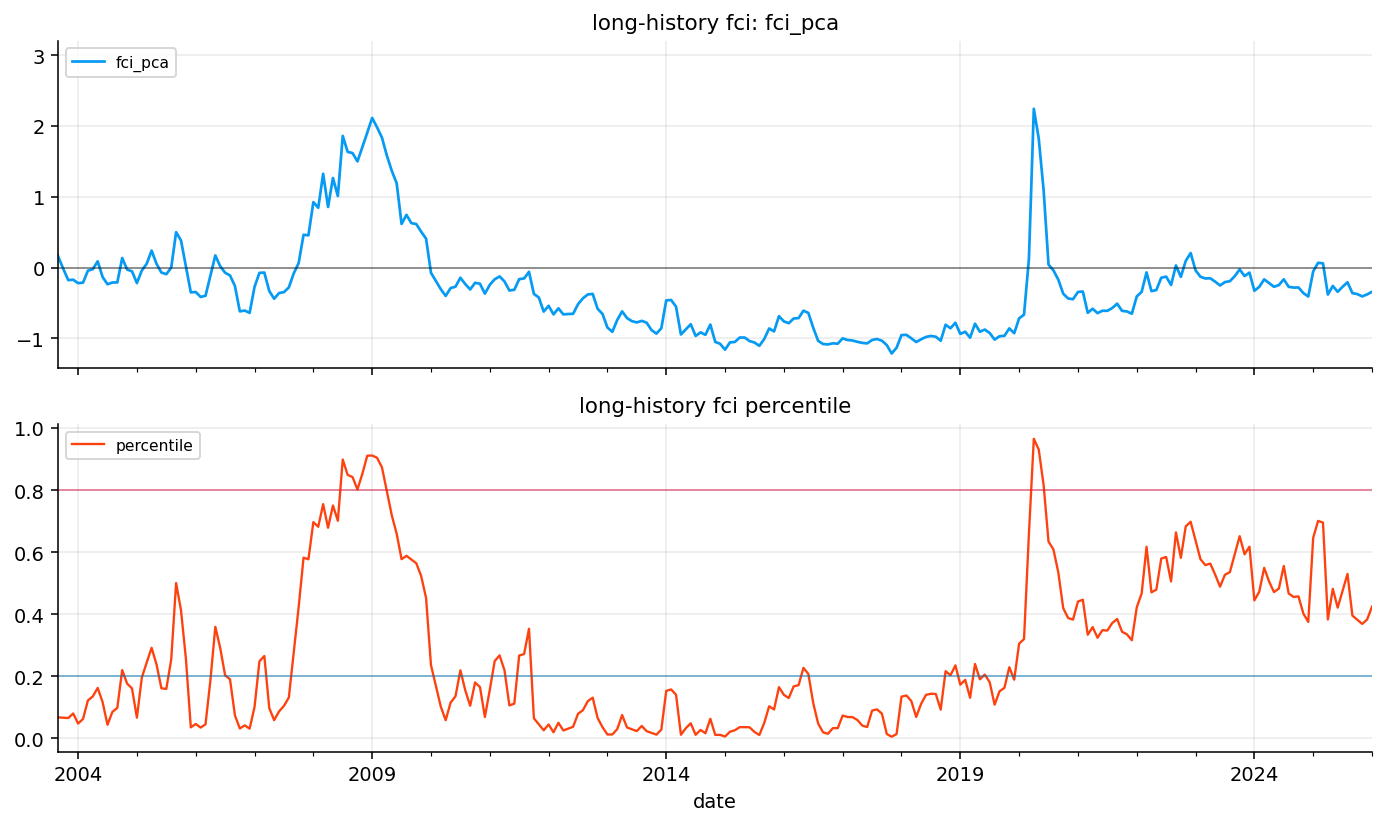

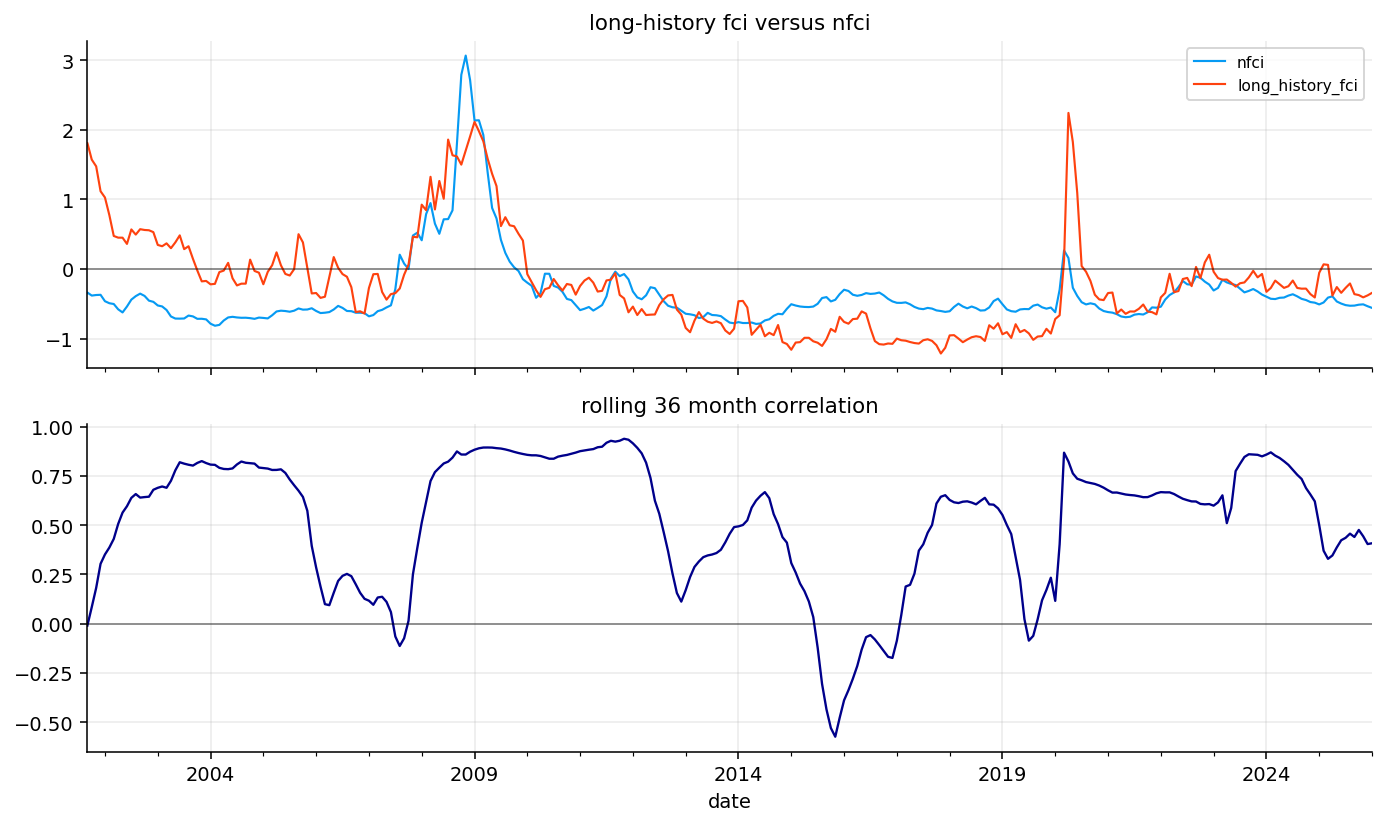

,correlation_with_nfci
selected_fci_model,
fci_pca,0.525


,mean_selected_fci,mean_nfci,agreement
window,,,
financial_crisis,1.806,2.364,1.0
covid_crash,0.565,0.043,1.0
inflation_rate_shock,-0.209,-0.281,0.9


In [43]:
long_history_scoreboard = full_sample_scoreboard.loc[full_sample_scoreboard["long_history_eligible"]]
long_history_fci_name = long_history_scoreboard.index[0] if len(long_history_scoreboard) else full_sample_scoreboard.index[0]
long_history_fci_series = fci_models[long_history_fci_name].rename("long_history_fci")
long_history_fci_percentile = rolling_percentile(long_history_fci_series, 60).rename("long_history_fci_percentile")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
long_history_fci_series.dropna().plot(ax=axes[0], lw=1.4, color=colors[0], label=long_history_fci_name)
long_history_fci_percentile.dropna().plot(ax=axes[1], lw=1.2, color=colors[1], label="percentile")
axes[0].axhline(0.0, color="black", lw=0.8, alpha=0.5)
axes[1].axhline(0.8, color=colors[5], lw=0.8, alpha=0.6)
axes[1].axhline(0.2, color=colors[7], lw=0.8, alpha=0.6)
axes[0].set_title("long-history fci: " + long_history_fci_name)
axes[1].set_title("long-history fci percentile")
for ax in axes:
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
selected_nfci = pd.concat([nfci_month["nfci"], long_history_fci_series], axis=1).dropna()
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
selected_nfci.plot(ax=axes[0], lw=1.1, color=[colors[0], colors[1]])
axes[0].axhline(0.0, color="black", lw=0.8, alpha=0.5)
axes[0].set_title("long-history fci versus nfci")
rolling_selected_nfci_corr = selected_nfci["long_history_fci"].rolling(36).corr(selected_nfci["nfci"])
rolling_selected_nfci_corr.dropna().plot(ax=axes[1], lw=1.2, color=colors[2])
axes[1].axhline(0.0, color="black", lw=0.8, alpha=0.5)
axes[1].set_title("rolling 36 month correlation")
for ax in axes:
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
nfci_corr = pd.DataFrame({"selected_fci_model": [long_history_fci_name], "correlation_with_nfci": [selected_nfci["long_history_fci"].corr(selected_nfci["nfci"])]}).set_index("selected_fci_model")
display(nfci_corr.round(3))
crisis_rows = []
for name, dates in crisis_windows.items():
    window = selected_nfci.loc[dates[0]:dates[1]]
    if len(window):
        crisis_rows.append({"window": name, "mean_selected_fci": window["long_history_fci"].mean(), "mean_nfci": window["nfci"].mean(), "agreement": float((np.sign(window["long_history_fci"]) == np.sign(window["nfci"])).mean())})
crisis_agreement_table = pd.DataFrame(crisis_rows).set_index("window")
display(crisis_agreement_table.round(3))


## 25) External NFCI Validation

We compare the selected long-history FCI with the external NFCI benchmark. This is not a perfect apples-to-apples test because NFCI is built from financial variables, while our FCI is built mainly from macro blocks. Still, crisis agreement is useful.

The correlation between the selected FCI and NFCI is about **0.525**. That is a meaningful positive relationship, especially because the inputs are different. It says the macro-built FCI captures a substantial part of broad financial stress.

The crisis agreement table is more important than the correlation alone:

- During the **financial crisis**, selected FCI mean is about **1.81**, NFCI mean is about **2.36**, and sign agreement is **1.0**.
- During the **COVID crash**, selected FCI mean is about **0.57**, NFCI mean is about **0.04**, and sign agreement is **1.0**.
- During the **inflation/rate shock**, selected FCI mean is about **-0.21**, NFCI mean is about **-0.28**, and sign agreement is **0.9**.

The model captures classic credit/liquidity stress well. The inflation/rate shock is different because macro pressure can be high while broad financial stress indexes are not necessarily crisis-high.


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,future_stress_rank_ic_rank,drawdown_spread_rank,monotonicity_score_rank,volatility_spread_rank,stability_score_rank,final_score,strategy_test_sample
model,,,,,,,,,,,,,,,
fci_econ,112,2016-10-31,2026-01-31,0.1919,0.0114,0.7,0.1000,0.7765,1.0,0.6,1.0,1.0,0.4,0.84,True
fci_pca,112,2016-10-31,2026-01-31,0.0918,0.0151,0.3,0.0957,0.7832,0.6,1.0,0.5,0.8,0.6,0.71,True
fci_prob,112,2016-10-31,2026-01-31,0.1395,0.0145,0.3,0.0303,0.7338,0.8,0.8,0.5,0.4,0.2,0.62,True
fci_blend,112,2016-10-31,2026-01-31,0.0549,0.0073,0.4,0.0871,0.8071,0.4,0.4,0.8,0.6,0.8,0.55,True
fci_pls,112,2016-10-31,2026-01-31,-0.1719,-0.0146,-0.8,-0.0323,0.8487,0.2,0.2,0.2,0.2,1.0,0.28,True


,full_sample_score_winner,common_sample_score_winner,test_sample_score_winner,selected_strategy_fci,selection_rule
0,fci_pca,fci_econ,fci_prob,fci_pca,Pre-specified long-history unsupervised FCI se...


,long_history_fci,prespecified_strategy_fci,strategy_start,strategy_test_start
0,fci_pca,fci_pca,1999-07-31,2016-10-31


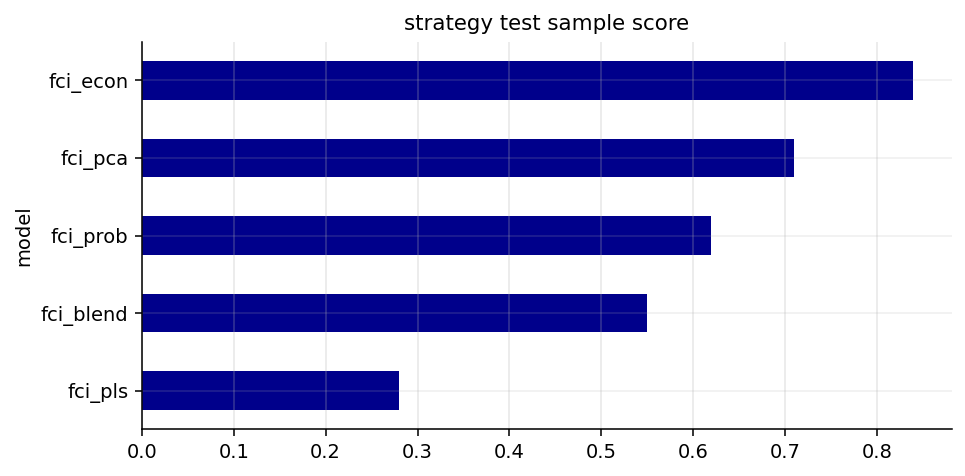

In [44]:
sector_assets = us_sector_assets[:]
defensive_sector_assets = [x for x in ["xlp", "xlu", "xlv"] if x in returns.columns]
cyclical_sector_assets = [x for x in ["xlf", "xli", "xly", "xlb"] if x in returns.columns]
inflation_assets = [x for x in ["xle", "xlb", "dbc", "gld"] if x in returns.columns]
rate_sensitive_assets = [x for x in ["xlk", "xly", "tlt"] if x in returns.columns]
strategy_assets = sorted(set(sector_assets + defensive_assets + ["spy"]))
required_strategy_assets = sector_assets + ["spy", "cash"]
asset_first_month = monthly_close[sector_assets + ["spy"]].apply(pd.Series.first_valid_index)
strategy_start = max(macro_start, asset_first_month.max() + pd.offsets.MonthEnd(6))
score_strategy_dates = fci_models.index.intersection(returns.index)
score_strategy_dates = score_strategy_dates[score_strategy_dates >= strategy_start]
strategy_split_date = score_strategy_dates[int(len(score_strategy_dates) * 0.65)] if len(score_strategy_dates) else pd.NaT
strategy_test_dates = score_strategy_dates[score_strategy_dates >= strategy_split_date]
strategy_sample_scoreboard = score_fci_models(fci_models.reindex(strategy_test_dates), target_table.reindex(strategy_test_dates))
strategy_sample_scoreboard["strategy_test_sample"] = True
prespecified_strategy_fci_name = long_history_fci_name
strategy_fci_name = prespecified_strategy_fci_name if prespecified_strategy_fci_name in fci_models.columns else "fci_econ"
best_fci_name = strategy_fci_name
best_fci_series = fci_models[best_fci_name].rename("best_fci")
best_fci_percentile = rolling_percentile(best_fci_series, 60).rename("best_fci_percentile")
best_fci_3m_change = best_fci_series.diff(3).rename("best_fci_3m_change")
tradable_macro = macro.shift(1)
allocation_features = tradable_macro[["inflation_pressure_block", "policy_rate_pressure_block", "growth_recession_block", "macro_breadth_conflict_block", "goldilocks_support"]].copy()
allocation_features["best_fci_percentile"] = best_fci_percentile.shift(1)
allocation_features["best_fci_3m_change"] = best_fci_3m_change.shift(1)
allocation_features["best_fci_value"] = best_fci_series.shift(1)
dominant_block_values = tradable_macro[block_cols].abs()
dominant_macro_block = pd.Series(np.nan, index=dominant_block_values.index, dtype=object)
has_dominant_block = dominant_block_values.notna().any(axis=1)
dominant_macro_block.loc[has_dominant_block] = dominant_block_values.loc[has_dominant_block].idxmax(axis=1)
allocation_features["dominant_macro_block"] = dominant_macro_block
allocation_features = allocation_features.dropna(subset=["best_fci_percentile", "best_fci_3m_change"])
model_choice_table = pd.DataFrame({
    "full_sample_score_winner": [full_sample_scoreboard.index[0]],
    "common_sample_score_winner": [common_model_scoreboard.index[0]],
    "test_sample_score_winner": [test_model_scoreboard.index[0]],
    "selected_strategy_fci": [strategy_fci_name],
    "selection_rule": ["Pre-specified long-history unsupervised FCI selected to avoid supervised model-selection lookahead and preserve crisis coverage."],
})
display(strategy_sample_scoreboard.round(4))
display(model_choice_table)
display(pd.DataFrame({"long_history_fci": [long_history_fci_name], "prespecified_strategy_fci": [strategy_fci_name], "strategy_start": [strategy_start], "strategy_test_start": [strategy_split_date]}))
fig, ax = plt.subplots(figsize=(7, 3.5))
strategy_sample_scoreboard["final_score"].sort_values().plot(kind="barh", ax=ax, color=colors[2])
ax.set_title("strategy test sample score")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 26) Choosing the Strategy FCI

The allocation strategy doesn't automatically use the model with the highest recent test score. It uses a pre-specified long-history unsupervised FCI, **fci_pca**, because the strategy needs a stable signal across multiple market cycles.

This is a key portfolio design point. A model can win the recent supervised score because it handled 2020–2025 well, but a trading strategy needs to survive many regimes. The selected strategy FCI starts early enough to include the dot-com cycle, the 2008 crisis, the 2020 crash, and the inflation shock.

The strategy sample starts in **July 1999**, and the test split begins around **October 2016**. That gives a long enough live-style history to compare sector rotation, macro gating, and benchmark behavior across several stress periods.

The selection table is transparent: fci_pca wins the full-sample long-history rule, fci_econ wins the common-sample score, fci_prob wins the test-sample score, and fci_pca is chosen for the actual strategy to avoid supervised model-selection lookahead and keep crisis coverage.


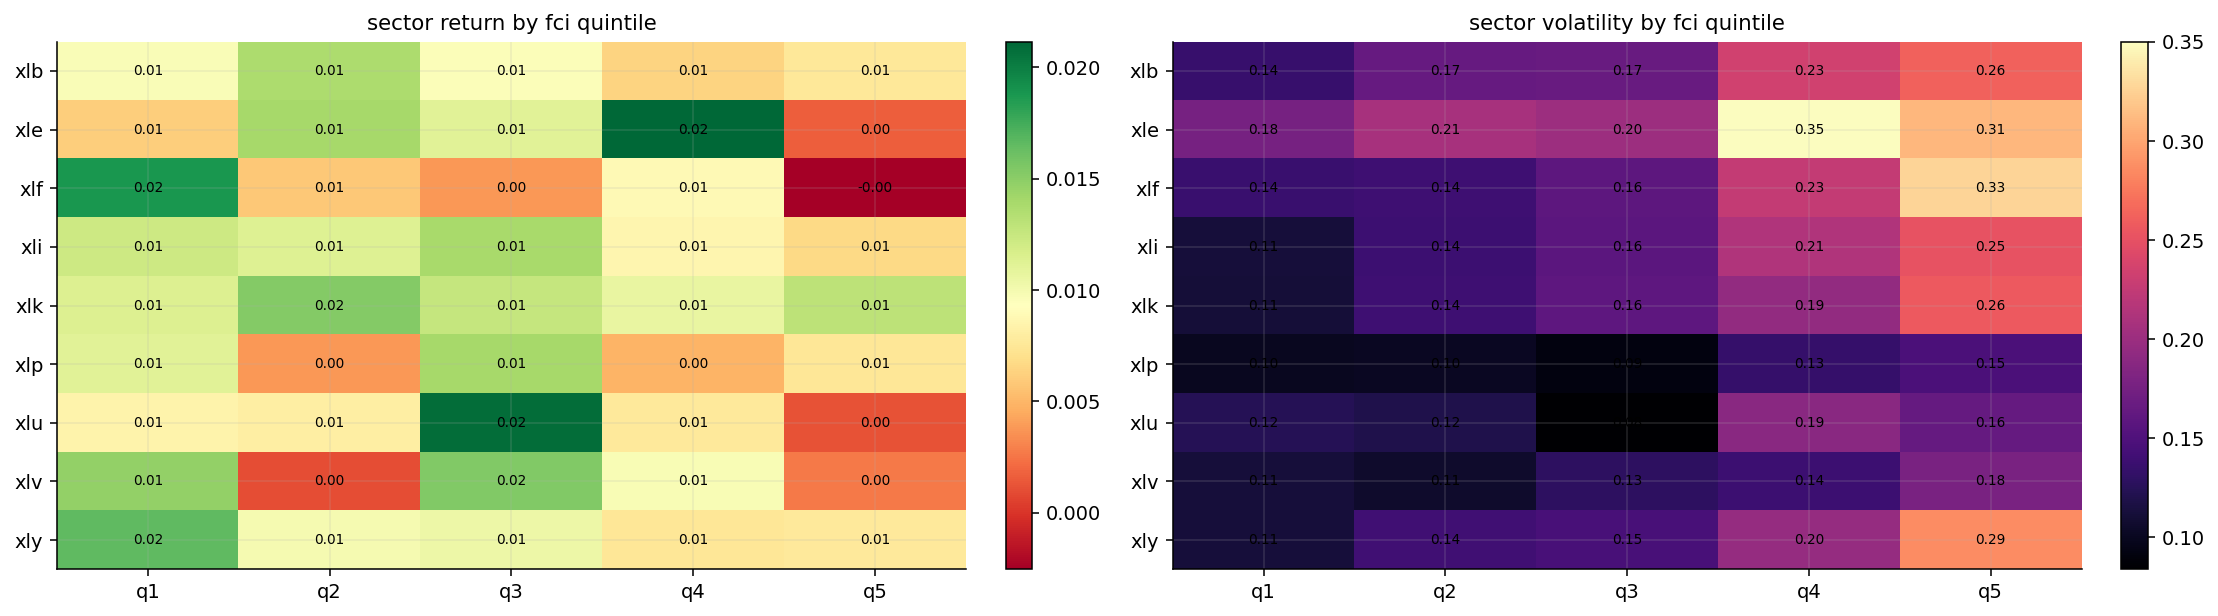

In [45]:
regime_data = pd.concat([best_fci_percentile.rename("fci_percentile"), returns[sector_assets].shift(-1)], axis=1).dropna(subset=["fci_percentile"])
regime_data["fci_quintile"] = pd.qcut(regime_data["fci_percentile"].rank(method="first"), 5, labels=["q1", "q2", "q3", "q4", "q5"])
sector_return_by_regime = regime_data.groupby("fci_quintile", observed=False)[sector_assets].mean()
sector_vol_by_regime = regime_data.groupby("fci_quintile", observed=False)[sector_assets].std() * np.sqrt(12.0)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, table, title, cmap in [(axes[0], sector_return_by_regime, "sector return by fci quintile", "RdYlGn"), (axes[1], sector_vol_by_regime, "sector volatility by fci quintile", "magma")]:
    shown = table.transpose()
    im = ax.imshow(shown, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(shown.columns)))
    ax.set_xticklabels(shown.columns)
    ax.set_yticks(range(len(shown.index)))
    ax.set_yticklabels(shown.index)
    for row in range(shown.shape[0]):
        for col in range(shown.shape[1]):
            value = shown.iloc[row, col]
            if np.isfinite(value):
                ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 27) Sector Returns Across FCI Regimes

The sector regime heatmap is one of the most economically useful outputs. It asks how sectors behave when the selected FCI is in different quintiles.

For each month, we have the FCI percentile and next-month sector returns. We group months by FCI quintile and compute average return and volatility:

$$
E[r_{i,t+1}\mid FCI_t\in Q_k]
$$

$$
\sigma_i(Q_k)=\sqrt{12}\,\text{Std}(r_{i,t+1}\mid FCI_t\in Q_k)
$$

The return heatmap shows sector performance across easy-to-tight conditions. The volatility heatmap shows how risk changes across regimes.

The strongest pattern is in volatility. Almost every sector becomes more volatile in tighter FCI regimes. In the tightest quintile, XLF volatility is around **33%**, XLE around **31%**, XLY around **29%**, and XLB/XLK around **26%**. Defensive sectors like XLP and XLV have lower volatility, roughly **15%** and **18%** in the tightest quintile.

This is exactly the macro relation we care about: tight conditions may not always produce negative sector returns immediately, but they raise the risk distribution.


The return side is more nuanced. Some sectors still have positive average returns in high-FCI regimes, but the compensation comes with much higher volatility. Financials, energy, discretionary, and materials show strong regime sensitivity. Staples and health care are more stable.

This means FCI is more useful as a **risk-gating variable** than as a pure return forecast. It tells us when the return distribution becomes wider and drawdowns become more likely. That is why later strategy design reduces risky exposure when FCI percentile rises rather than trying to short all sectors whenever conditions are tight.

The heatmap also supports sector differentiation. During easier conditions, cyclical sectors can do well because growth and credit conditions support earnings. During tight conditions, volatility rises sharply, and defensive sectors become more attractive from a risk-adjusted perspective.


## 28) Defensive Minus Cyclical Spread and Inflation Assets

The defensive minus cyclical spread tracks a simple relative performance idea:

$$
r_t^{def-cyc}=\frac{1}{N_D}\sum_{i\in D}r_{i,t}-\frac{1}{N_C}\sum_{j\in C}r_{j,t}
$$

where $D$ is the defensive sector basket and $C$ is the cyclical basket. The cumulative spread is:

$$
NAV_t^{def-cyc}=\prod_{s\leq t}(1+r_s^{def-cyc})-1
$$

The plot shows that defensives have not simply dominated over the whole sample. The spread spikes in stress episodes and then can give back gains when risk appetite returns. This is why regime timing matters. Holding defensives permanently can underperform in bull markets, but switching to them during stress can reduce drawdown.

The high-inflation/policy table shows that inflation beneficiaries did well during high inflation-policy periods: XLE has average monthly return around **1.91%**, XLB around **1.05%**, DBC around **2.07%**, and GLD around **1.27%**. That supports the macro intuition that energy, materials, commodities, and gold can help when inflation is the dominant pressure.


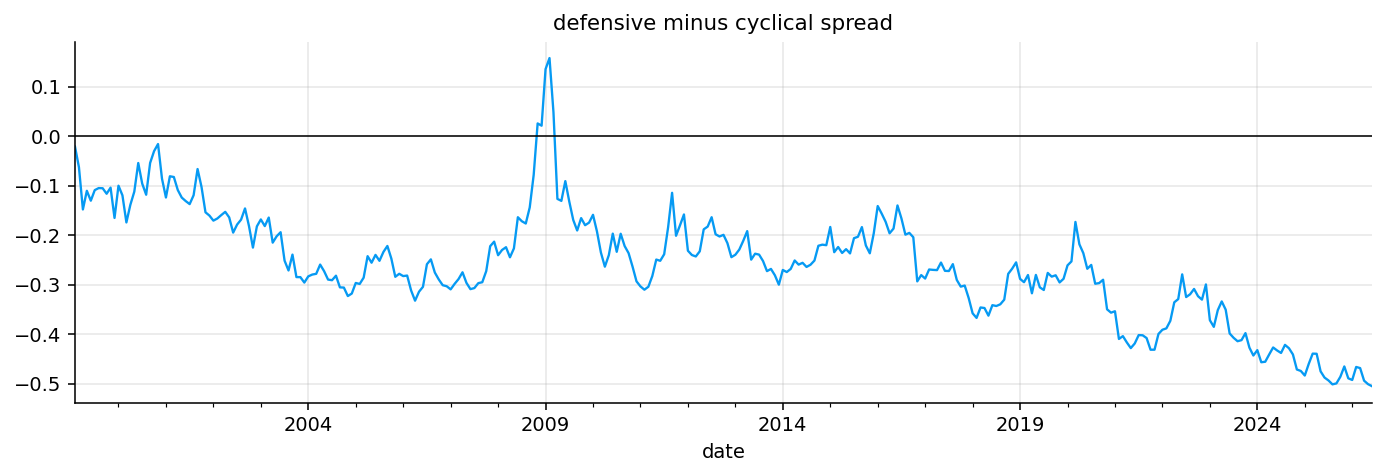

,average_monthly_return
xle,0.0191
xlb,0.0105
dbc,0.0207
gld,0.0127


,average_monthly_return
xlk,NaN
xly,NaN
tlt,NaN


In [46]:
def_cyc_ret = returns[defensive_sector_assets].mean(axis=1) - returns[cyclical_sector_assets].mean(axis=1)
def_cyc_spread = (1.0 + def_cyc_ret.fillna(0.0)).cumprod() - 1.0
ax = def_cyc_spread.plot(figsize=(10, 3.5), lw=1.2)
ax.axhline(0.0, color="black", lw=0.8)
ax.set_title("defensive minus cyclical spread")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
high_inflation_policy = (macro["inflation_pressure_block"] + macro["policy_rate_pressure_block"]).reindex(returns.index) > 1.0
high_policy = macro["policy_rate_pressure_block"].reindex(returns.index) > 1.0
display(returns.loc[high_inflation_policy.fillna(False), inflation_assets].mean().to_frame("average_monthly_return").round(4))
display(returns.loc[high_policy.fillna(False), rate_sensitive_assets].mean().to_frame("average_monthly_return").round(4))


The rate-sensitive table has missing values for XLK, XLY, and TLT under the high-policy condition in this specific output. That means the condition and available monthly data did not produce a valid sample for the selected assets in that filtered table. We shouldn’t force an interpretation from NaNs.

The inflation-asset result is still useful. It tells us that the defensive sleeve shouldn’t always mean only cash and bonds. During growth recessions with low inflation, Treasuries can help. During inflation shocks, long-duration bonds can be the wrong hedge, while commodities, gold, and short-duration cash-like assets may be more appropriate.

That is exactly why the later defensive-sleeve logic changes depending on whether stress comes from inflation-policy pressure or growth recession pressure.


### Turning Macro Into Allocation Rules

A macro index becomes useful only when it changes a decision. In this project, the decision is not a single all-in/all-out switch. The FCI changes the **risk budget** and the macro blocks change **sector preference**.

We can think of the final portfolio as:

$$
w_t=w_t^{risk}w_t^{sector}+(1-w_t^{risk})w_t^{defensive}
$$

where $w_t^{risk}$ is the amount allocated to risky sector rotation, $w_t^{sector}$ is the selected sector weight vector, and $w_t^{defensive}$ is the defensive sleeve weight vector.

This structure is clean because it separates two questions:

- How much equity-sector risk do we want?
- Which sector exposures fit the current macro and momentum state?

A single score that mixes everything into one portfolio vector would be harder to interpret. The two-layer design lets us diagnose whether performance came from risk gating, sector selection, or defensive-asset selection.


In [47]:
def cross_z(frame):
    mean = frame.mean(axis=1)
    std = frame.std(axis=1, ddof=1).replace(0.0, np.nan)
    return frame.sub(mean, axis=0).div(std, axis=0).fillna(0.0)

def cap_weights(weights, cap=0.40):
    weights = pd.Series(weights, dtype=float).clip(lower=0.0)
    if weights.sum() <= 1e-12:
        return weights
    weights = weights / weights.sum()
    for _ in range(20):
        over = weights > cap
        if not over.any():
            break
        excess = (weights[over] - cap).sum()
        weights[over] = cap
        room = (cap - weights[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        weights.loc[room.index] += excess * room / room.sum()
    return weights / weights.sum()

def momentum_score(ret, assets):
    data = ret[assets]
    mom_12_1 = (1.0 + data.shift(1)).rolling(11).apply(np.prod, raw=True) - 1.0
    ret_6 = (1.0 + data.shift(1)).rolling(6).apply(np.prod, raw=True) - 1.0
    vol_6 = data.shift(1).rolling(6).std(ddof=1) * np.sqrt(12.0)
    return 0.60 * cross_z(mom_12_1) + 0.40 * cross_z(ret_6 / vol_6.replace(0.0, np.nan))


In [48]:
sector_momentum_score = momentum_score(returns, sector_assets)
sector_vol = returns[sector_assets].rolling(6).std(ddof=1) * np.sqrt(12.0)
strategy_end = min(allocation_features.index.max(), returns_raw.index.max())
strategy_dates = allocation_features.index.intersection(returns_raw.index)
strategy_dates = strategy_dates[(strategy_dates >= strategy_start) & (strategy_dates <= strategy_end)]
strategy_returns = returns_raw.loc[strategy_dates.min():strategy_end, strategy_assets]
missing_share = strategy_returns.isna().mean()
display(missing_share.to_frame("missing_share_in_strategy_window"))
strategy_returns = strategy_returns.fillna(0.0)
stress = allocation_features["best_fci_percentile"].reindex(strategy_dates)
slope = allocation_features["best_fci_3m_change"].reindex(strategy_dates).clip(lower=0.0)
risky_weight = pd.Series(1.0, index=stress.index)
risky_weight -= ((stress - 0.60).clip(0.0, 0.25) / 0.25) * 0.35
risky_weight -= (slope.clip(0.0, 0.75) / 0.75) * 0.10
risky_weight = risky_weight.clip(0.50, 1.00).rename("risky_weight")
display(pd.DataFrame({"strategy_start": [strategy_start], "strategy_end": [strategy_end], "strategy_months": [len(strategy_dates)], "latest_month": [strategy_dates.max()], "strategy_fci": [strategy_fci_name], "minimum_risky_weight": [risky_weight.min()]}))


,missing_share_in_strategy_window
cash,0.000000
dbc,0.108209
gld,0.052239
ief,0.000000
shy,0.000000
spy,0.000000
tlt,0.000000
xlb,0.000000
xle,0.000000
xlf,0.000000


,strategy_start,strategy_end,strategy_months,latest_month,strategy_fci,minimum_risky_weight
0,1999-07-31,2026-01-31,268,2026-01-31,fci_pca,0.55


## 29) Macro-Gated Allocation: Risky Weight

The allocation strategy has two layers. First, it decides how much capital should remain in risky sectors. Second, it decides which sectors should receive that risky allocation.

The risky weight is based on the selected FCI percentile and the recent FCI change. Let $p_t$ be the FCI percentile and $\Delta_3F_t$ be the 3-month FCI change. The risky weight is:

$$
w_t^{risk}=\text{clip}\left(1-0.35\frac{[p_t-0.60]_{0}^{0.25}}{0.25}-0.10\frac{[\Delta_3F_t]_{0}^{0.75}}{0.75},\,0.50,\,1.00\right)
$$

Here $[x]_0^a$ means the value is clipped between $0$ and $a$, and $[\Delta_3F_t]^+$ means only positive FCI changes reduce risk.

This formula says:

- If FCI percentile is below 60%, we keep full risky exposure.
- If FCI percentile rises above 60%, risky exposure is gradually reduced.
- If FCI is also rising quickly, risky exposure is reduced a bit more.
- The strategy never goes below 50% risky exposure.

The latest strategy setup has **268 strategy months**, from July 1999 to January 2026, and the minimum risky weight over the sample is **0.55**. So the strategy is macro-gated, but it is not a full risk-off timing system.


## 30) Defensive Sleeve Logic

The defensive sleeve is chosen based on the type of macro stress.

If inflation and policy pressure are high:

$$
B_{I,t}+B_{P,t}>1
$$

we use inflation-aware defensive assets: gold, commodities, short Treasuries, and cash. This protects against the 2022-style regime where long duration can lose money at the same time as equities.

If growth recession pressure is high and inflation pressure is not high:

$$
B_{G,t}>0.75 \quad \text{and} \quad B_{I,t}\leq 0.75
$$

we use duration and classic safe-haven assets: intermediate Treasuries, short Treasuries, gold, and cash. This is more like a 2008 or pre-inflation recession hedge.

Otherwise, the defensive sleeve uses cash, short Treasuries, and intermediate Treasuries. This is the neutral defensive setup.

This conditional sleeve is one of the strongest ideas in the project. Defensive allocation depends on the source of macro stress. Bonds can be protection in growth shocks, but they can be a source of losses in inflation shocks.


In [49]:
def available_assets_at_date(date, candidates, ret):
    return [asset for asset in candidates if asset in ret.columns and date in ret.index and pd.notna(ret.loc[date, asset])]

def defensive_sleeve(row):
    date = row.name
    inflation_policy = row.get("inflation_pressure_block", 0.0) + row.get("policy_rate_pressure_block", 0.0)
    growth = row.get("growth_recession_block", 0.0)
    inflation = row.get("inflation_pressure_block", 0.0)
    if inflation_policy > 1.0:
        candidates = ["gld", "dbc", "shy", "cash"]
    elif growth > 0.75 and inflation <= 0.75:
        candidates = ["ief", "shy", "gld", "cash"]
    else:
        candidates = ["cash", "shy", "ief"]
    picked = available_assets_at_date(date, [x for x in candidates if x in defensive_assets], returns_raw)
    if not picked:
        picked = ["cash"]
    out = pd.Series(0.0, index=defensive_assets)
    out.loc[picked] = 1.0 / len(picked)
    return out

def macro_fit_scores(features, assets):
    rows = []
    for date, row in features.iterrows():
        score = pd.Series(0.0, index=assets)
        for asset in assets:
            if asset in defensive_sector_assets:
                score.loc[asset] += 0.70 * row["best_fci_percentile"] + 0.45 * row["growth_recession_block"]
            if asset in cyclical_sector_assets:
                score.loc[asset] += 0.80 * (1.0 - row["best_fci_percentile"]) - 0.40 * row["growth_recession_block"] - 0.30 * row["macro_breadth_conflict_block"]
            if asset in inflation_assets:
                score.loc[asset] += 0.55 * row["inflation_pressure_block"] - 0.25 * max(row["growth_recession_block"], 0.0)
            if asset in rate_sensitive_assets:
                score.loc[asset] -= 0.45 * row["policy_rate_pressure_block"]
            if asset == "xlf":
                score.loc[asset] -= 0.35 * max(row["policy_rate_pressure_block"], 0.0) * max(row["growth_recession_block"], 0.0)
        rows.append(score.rename(date))
    return cross_z(pd.concat(rows, axis=1).transpose())


In [50]:
equal_rows = []
momentum_rows = []
gated_rows = []
for date in strategy_dates:
    row_equal = pd.Series(0.0, index=strategy_assets)
    row_equal.loc[sector_assets] = 1.0 / len(sector_assets)
    equal_rows.append(row_equal.rename(date))
    row_mom = pd.Series(0.0, index=strategy_assets)
    picked = sector_momentum_score.loc[date, sector_assets].dropna().sort_values(ascending=0).head(3).index.tolist()
    if picked:
        inv = (1.0 / sector_vol.loc[date, picked].replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna()
        row_mom.loc[inv.index] = cap_weights(inv if len(inv) else pd.Series(1.0, index=picked), 0.40)
    momentum_rows.append(row_mom.rename(date))
    row_gated = row_equal * float(risky_weight.loc[date])
    sleeve = defensive_sleeve(allocation_features.loc[date])
    row_gated.loc[sleeve.index] += (1.0 - float(risky_weight.loc[date])) * sleeve
    gated_rows.append(row_gated.rename(date))
equal_sector_weights = pd.concat(equal_rows, axis=1).transpose().fillna(0.0)
momentum_weights = pd.concat(momentum_rows, axis=1).transpose().fillna(0.0)
gated_weights = pd.concat(gated_rows, axis=1).transpose().fillna(0.0)


## 31) Sector Momentum and Macro Fit

The pure momentum rotation selects sectors based on recent sector strength. The macro version keeps momentum as the core, but modifies it with macro fit.

The momentum score is:

$$
M_{i,t}=0.60z(R_{i,t}^{12-1})+0.40z\left(\frac{R_{i,t}^{6m}}{\sigma_{i,t}^{6m}}\right)
$$

where $R^{12-1}$ is medium-term momentum with a one-month skip, $R^{6m}$ is six-month return, and $\sigma^{6m}$ is recent annualized volatility. The second term rewards return per unit of recent risk.

Macro fit adds economic context. Defensive sectors receive support when FCI percentile and growth stress are high:

$$
\text{fit}_{def,t}=0.70p_t+0.45B_{G,t}
$$

Cyclicals receive support when conditions are easier and growth stress is low:

$$
\text{fit}_{cyc,t}=0.80(1-p_t)-0.40B_{G,t}-0.30B_{C,t}
$$

Inflation beneficiaries receive support from inflation pressure:

$$
\text{fit}_{infl,t}=0.55B_{I,t}-0.25\max(B_{G,t},0)
$$

Rate-sensitive assets are penalized when policy pressure is high:

$$
\text{fit}_{rate,t}=-0.45B_{P,t}
$$

Financials receive an extra penalty when policy pressure and growth stress are both positive, because credit quality and funding conditions can deteriorate together.


### Final Sector Score

The final sector score blends momentum, macro fit, macro support, and a risk penalty:

$$
S_{i,t}=0.65M_{i,t}+0.20\text{Fit}_{i,t}+0.10\text{Support}_{i,t}-0.05\text{RiskPenalty}_{i,t}
$$

Momentum receives the largest weight because price action still matters. Macro fit receives a meaningful but smaller weight, enough to tilt the selection toward sectors that match the macro regime. Support adds broad goldilocks or inflation support. The risk penalty reduces sectors with high recent volatility or recent losses.

The strategy selects the top three sectors by $S_{i,t}$, then allocates by inverse volatility with a 40% cap:

$$
w_{i,t}^{sector}\propto \frac{1}{\sigma_{i,t}^{6m}}
$$

and:

$$
w_{i,t}\leq 0.40
$$

The selected sector sleeve is scaled by the risky weight $w_t^{risk}$, and the rest goes into the defensive sleeve. This keeps the strategy from becoming a pure top-three momentum portfolio when macro stress is high.


In [51]:
macro_fit_score = macro_fit_scores(allocation_features.reindex(strategy_dates), sector_assets)
macro_support_score = cross_z(pd.DataFrame({asset: 0.20 * allocation_features["goldilocks_support"].reindex(strategy_dates) - 0.20 * allocation_features["macro_breadth_conflict_block"].reindex(strategy_dates) + (0.35 * allocation_features["inflation_pressure_block"].reindex(strategy_dates) if asset in inflation_assets else 0.0) for asset in sector_assets}))
recent_risk_penalty = cross_z(sector_vol.reindex(strategy_dates).fillna(0.0)) + cross_z((-returns[sector_assets].rolling(3).sum()).reindex(strategy_dates).clip(lower=0.0).fillna(0.0))
final_sector_score = 0.65 * sector_momentum_score.reindex(strategy_dates) + 0.20 * macro_fit_score + 0.10 * macro_support_score - 0.05 * recent_risk_penalty
fci_momentum_rows = []
selected_sector_rows = []
for date in strategy_dates:
    row = pd.Series(0.0, index=strategy_assets)
    picked = final_sector_score.loc[date, sector_assets].dropna().sort_values(ascending=0).head(3).index.tolist()
    if picked:
        inv = (1.0 / sector_vol.loc[date, picked].replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna()
        row.loc[inv.index] = cap_weights(inv if len(inv) else pd.Series(1.0, index=picked), 0.40) * float(risky_weight.loc[date])
    sleeve = defensive_sleeve(allocation_features.loc[date])
    row.loc[sleeve.index] += (1.0 - float(risky_weight.loc[date])) * sleeve
    fci_momentum_rows.append(row.rename(date))
    selected_sector_rows.append({"date": date, "selected": ", ".join(picked)})
fci_momentum_weights = pd.concat(fci_momentum_rows, axis=1).transpose().fillna(0.0)
selected_sector_table = pd.DataFrame(selected_sector_rows).set_index("date")
display(selected_sector_table.tail(12))


,selected
date,
2025-02-28,"xly, xlf, xlu"
2025-03-31,"xlf, xlu, xly"
2025-04-30,"xlf, xlu, xlp"
2025-05-31,"xlf, xly, xlp"
2025-06-30,"xlf, xli, xlu"
2025-07-31,"xlu, xlf, xli"
2025-08-31,"xlu, xli, xlf"
2025-09-30,"xlf, xli, xly"
2025-10-31,"xly, xlk, xli"


The latest selected-sector table shows a clear risk-on tilt in late 2025 and January 2026. The selected sectors rotate among XLF, XLI, XLU, XLY, XLK, and XLP during the last year, with January 2026 selecting **XLI, XLK, and XLY**.

This matches the latest macro state. The selected FCI percentile is around **0.38**, so conditions are not tight enough to force a large defensive allocation. The dominant macro block is labor cooling, but the actual labor stress is negative, which means labor is not the main risk driver. Inflation is positive, but broad stress is not confirmed.

The recent selection therefore leans toward cyclical and growth-sensitive sectors rather than cash, bonds, or gold. The strategy is responding to the combination of neutral FCI, strong or acceptable sector momentum, and the absence of broad recession stress.


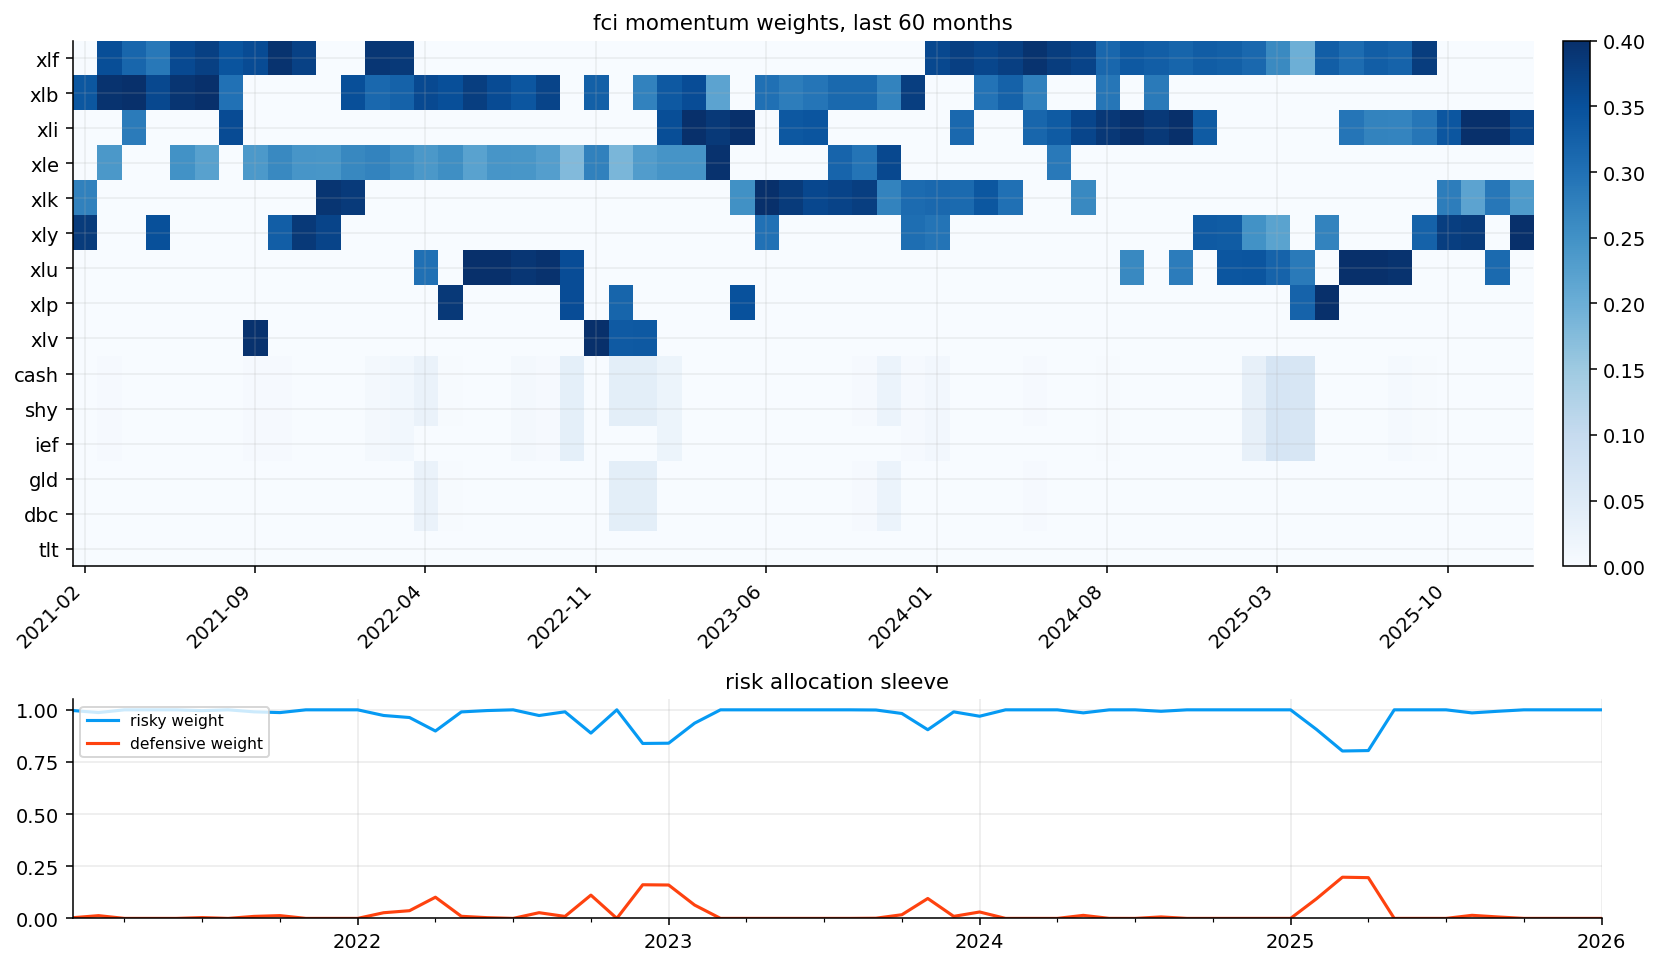

In [52]:
plot_weights = fci_momentum_weights[sector_assets + defensive_assets].tail(60)
plot_weights = plot_weights.loc[:, plot_weights.mean().sort_values(ascending=False).index]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [2.4, 1.0]})
im = axes[0].imshow(plot_weights.T, aspect="auto", cmap="Blues", vmin=0.0, vmax=max(0.40, float(plot_weights.max().max())))
axes[0].set_yticks(range(len(plot_weights.columns)))
axes[0].set_yticklabels(plot_weights.columns)
step = max(1, len(plot_weights.index) // 8)
locs = list(range(0, len(plot_weights.index), step))
axes[0].set_xticks(locs)
axes[0].set_xticklabels([plot_weights.index[i].strftime("%Y-%m") for i in locs], rotation=45, ha="right")
axes[0].set_title("fci momentum weights, last 60 months")
fig.colorbar(im, ax=axes[0], fraction=0.025, pad=0.02)
risky_weight.reindex(plot_weights.index).plot(ax=axes[1], lw=1.6, color=colors[0], label="risky weight")
(1.0 - risky_weight).reindex(plot_weights.index).plot(ax=axes[1], lw=1.6, color=colors[1], label="defensive weight")
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title("risk allocation sleeve")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 32) Weight Heatmap and Risk Sleeve

The weight heatmap shows the last 60 months of the FCI momentum strategy. It is useful because it reveals whether the allocation is stable or constantly jumping.

The top panel shows sector and defensive weights. The darker cells correspond to higher weights, capped around 40%. The bottom panel shows the risky/defensive split.

The strategy spends most of the latest window heavily allocated to the risky sleeve, with only short defensive episodes. This is consistent with the selected FCI percentile being below the main stress threshold most of the time after 2023. The defensive sleeve becomes more relevant when FCI percentile rises or when the FCI is increasing quickly.

The heatmap also shows that the strategy is concentrated by design. It usually holds three selected sectors plus a defensive sleeve if risk is gated. This means the performance comparison later needs to consider turnover and concentration risk, not just CAGR.


### Why We Compare Four Active Strategies Instead of One

The project compares multiple strategies because each one answers a different research question.

Equal-weight sectors answers: what happens if we keep sector exposure simple and diversified? Momentum rotation answers: how much value comes from price trend alone? FCI-gated basket answers: how much value comes from changing total risky exposure based on macro conditions? FCI momentum rotation answers: what happens when macro information changes both the risk budget and the sector selection?

This decomposition is important. If FCI momentum beats everything, macro plus momentum is strong. If pure momentum beats FCI momentum, the macro overlay may be too defensive or too slow. If FCI-gated beats equal-weight sectors, macro risk gating adds value even without complex sector picking.

The comparison also separates performance sources. CAGR tells us about compound growth. Volatility and Sortino tell us about risk. Max drawdown and worst 12-month return tell us about pain. Turnover tells us how expensive the strategy is to run. A macro strategy that improves drawdown but destroys CAGR is a hedge, not necessarily a better portfolio.


In [53]:
spy_weights = equal_sector_weights.copy() * 0.0
spy_weights["spy"] = 1.0
weights_by_strategy = {"equal_weight_sectors": equal_sector_weights, "momentum_rotation": momentum_weights, "fci_gated_basket": gated_weights, "fci_momentum_rotation": fci_momentum_weights, "spy_buy_hold": spy_weights}
backtest_results = run_many_weights_backtests(weights_by_strategy, returns=strategy_returns, cost_bps=5.0, weight_timing="next_close")
performance_table = build_metrics_table(backtest_results, rf_daily=rf_monthly, annualization=12.0)
trade_table = build_trade_table(backtest_results)
performance_table.columns = [str(col).lower().replace(" ", "_") for col in performance_table.columns]
trade_table.columns = [str(col).lower().replace(" ", "_") for col in trade_table.columns]
strategy_return_table = pd.concat({name: result.net_returns for name, result in backtest_results.items()}, axis=1).fillna(0.0)
strategy_nav_table = pd.concat({name: result.net_values for name, result in backtest_results.items()}, axis=1)
rolling_12m = (1.0 + strategy_return_table).rolling(12).apply(np.prod, raw=True) - 1.0
performance_table["hit_rate"] = (strategy_return_table > 0).mean()
performance_table["worst_12m_return"] = rolling_12m.min()
performance_table["turnover"] = trade_table["avg_turnover"]
performance_table["cost_drag"] = trade_table["cost_drag"]
display(performance_table.round(4))
full_defensive_first_month = monthly_close[optional_defensive_assets].apply(pd.Series.first_valid_index).max()
full_defensive_start = max(strategy_start, full_defensive_first_month + pd.offsets.MonthEnd(6))
full_defensive_dates = strategy_dates[strategy_dates >= full_defensive_start]
full_defensive_returns = returns_raw.loc[full_defensive_dates.min():strategy_end, strategy_assets]
display(full_defensive_returns.isna().mean().to_frame("missing_share_in_full_defensive_window"))
full_defensive_weights = {name: weights.reindex(full_defensive_dates).dropna(how="all") for name, weights in weights_by_strategy.items()}
full_defensive_results = run_many_weights_backtests(full_defensive_weights, returns=full_defensive_returns.fillna(0.0), cost_bps=5.0, weight_timing="next_close")
full_defensive_performance_table = build_metrics_table(full_defensive_results, rf_daily=rf_monthly, annualization=12.0)
full_defensive_performance_table.columns = [str(col).lower().replace(" ", "_") for col in full_defensive_performance_table.columns]
display(pd.DataFrame({"full_defensive_start": [full_defensive_start], "full_defensive_months": [len(full_defensive_dates)]}))
display(full_defensive_performance_table.round(4))


,cagr,vol,sharpe,max_drawdown,calmar,sortino,hit_rate,worst_12m_return,turnover,cost_drag
Strategy,,,,,,,,,,
equal_weight_sectors,0.1070,0.1433,0.5069,-0.4913,0.2178,0.6570,0.6704,-0.4294,0.0136,0.0006
momentum_rotation,0.1099,0.1384,0.5379,-0.3766,0.2918,0.7544,0.6292,-0.3225,0.2632,0.0124
fci_gated_basket,0.1123,0.1312,0.5772,-0.3406,0.3298,0.8307,0.6704,-0.2728,0.0344,0.0015
fci_momentum_rotation,0.0978,0.1392,0.4546,-0.2532,0.3864,0.6532,0.6330,-0.2103,0.2698,0.0168
spy_buy_hold,0.1086,0.1449,0.5132,-0.5078,0.2139,0.6859,0.6704,-0.4342,0.0019,0.0000


,missing_share_in_full_defensive_window
cash,0.0
dbc,0.0
gld,0.0
ief,0.0
shy,0.0
spy,0.0
tlt,0.0
xlb,0.0
xle,0.0
xlf,0.0


,full_defensive_start,full_defensive_months
0,2006-08-31,234


,cagr,vol,sharpe,max_drawdown,calmar,sortino
Strategy,,,,,,
equal_weight_sectors,0.1038,0.1508,0.4675,-0.4913,0.2112,0.6162
momentum_rotation,0.1065,0.1432,0.5066,-0.3766,0.2829,0.7158
fci_gated_basket,0.1101,0.1377,0.5392,-0.3406,0.3231,0.7884
fci_momentum_rotation,0.0881,0.1425,0.3947,-0.2532,0.3480,0.5653
spy_buy_hold,0.1102,0.1525,0.4985,-0.5078,0.2169,0.6770


## 33) Strategy Comparison

The strategy table compares five approaches:

- Equal-weight sectors.
- Pure momentum rotation.
- FCI-gated sector basket.
- FCI momentum rotation.
- SPY buy and hold.

The key results are:

| Strategy | CAGR | Vol | Sharpe | Max drawdown | Worst 12m | Turnover |
|---|---:|---:|---:|---:|---:|---:|
| Equal-weight sectors | 10.70% | 14.33% | 0.507 | -49.13% | -42.94% | 1.36% |
| Momentum rotation | 10.99% | 13.84% | 0.538 | -37.66% | -32.25% | 26.32% |
| FCI-gated basket | 11.23% | 13.12% | 0.577 | -34.06% | -27.28% | 3.44% |
| FCI momentum rotation | 9.78% | 13.92% | 0.455 | -25.32% | -21.03% | 26.98% |
| SPY buy and hold | 10.86% | 14.49% | 0.513 | -50.78% | -43.42% | 0.19% |

The FCI-gated basket gives the best overall Sharpe and the best CAGR among the US strategies in the full window. It reduces volatility, drawdown, and worst 12-month loss while slightly improving return.

The FCI momentum rotation has the lowest drawdown by far, around **-25.3%**, but its CAGR is lower. That means the macro-momentum version is more defensive and better at avoiding deep losses, but it gives up enough upside to reduce Sharpe.


The model comparison is especially useful because each strategy isolates a different idea.

Equal-weight sectors is the neutral sector benchmark. It has high drawdown because it stays fully invested in equities throughout every crisis. SPY buy-and-hold behaves similarly, with slightly higher drawdown.

Pure momentum rotation improves drawdown and return relative to equal-weight sectors, but it has high turnover. Momentum is useful because it can move away from persistent losers, but it can also rotate aggressively.

The FCI-gated basket keeps broad sector exposure but changes the risky/defensive split. Its strong result says macro risk gating adds value in this sample. It doesn't need to pick perfect sectors; reducing risk exposure during tight conditions is enough to improve the return distribution.

The FCI momentum rotation is the most protective. It has the lowest max drawdown and worst 12-month loss. The cost is lower CAGR and higher turnover. This is a classic risk-control tradeoff: better crash behavior, weaker upside capture.


The full-defensive-window table starts in August 2006, once all defensive assets are available. In this shorter but cleaner sample, the main ranking remains economically consistent.

The FCI-gated basket has the best Sharpe around **0.539** and the best Sortino around **0.788**. SPY has slightly higher CAGR, about **11.02%**, but suffers a much larger max drawdown around **-50.78%**. The FCI-gated basket keeps max drawdown around **-34.06%**.

The FCI momentum rotation again gives strong drawdown control, around **-25.32%**, but lower CAGR around **8.81%**. That confirms the same interpretation from the full strategy window: macro-momentum is defensive and robust in crashes, but it can become too cautious in long risk-on periods.

This is why the project shouldn’t declare one universal winner. For growth with moderate risk control, FCI-gated is strongest. For maximum drawdown control, FCI momentum is strongest. For simplicity, equal-weight or SPY is easier but riskier.


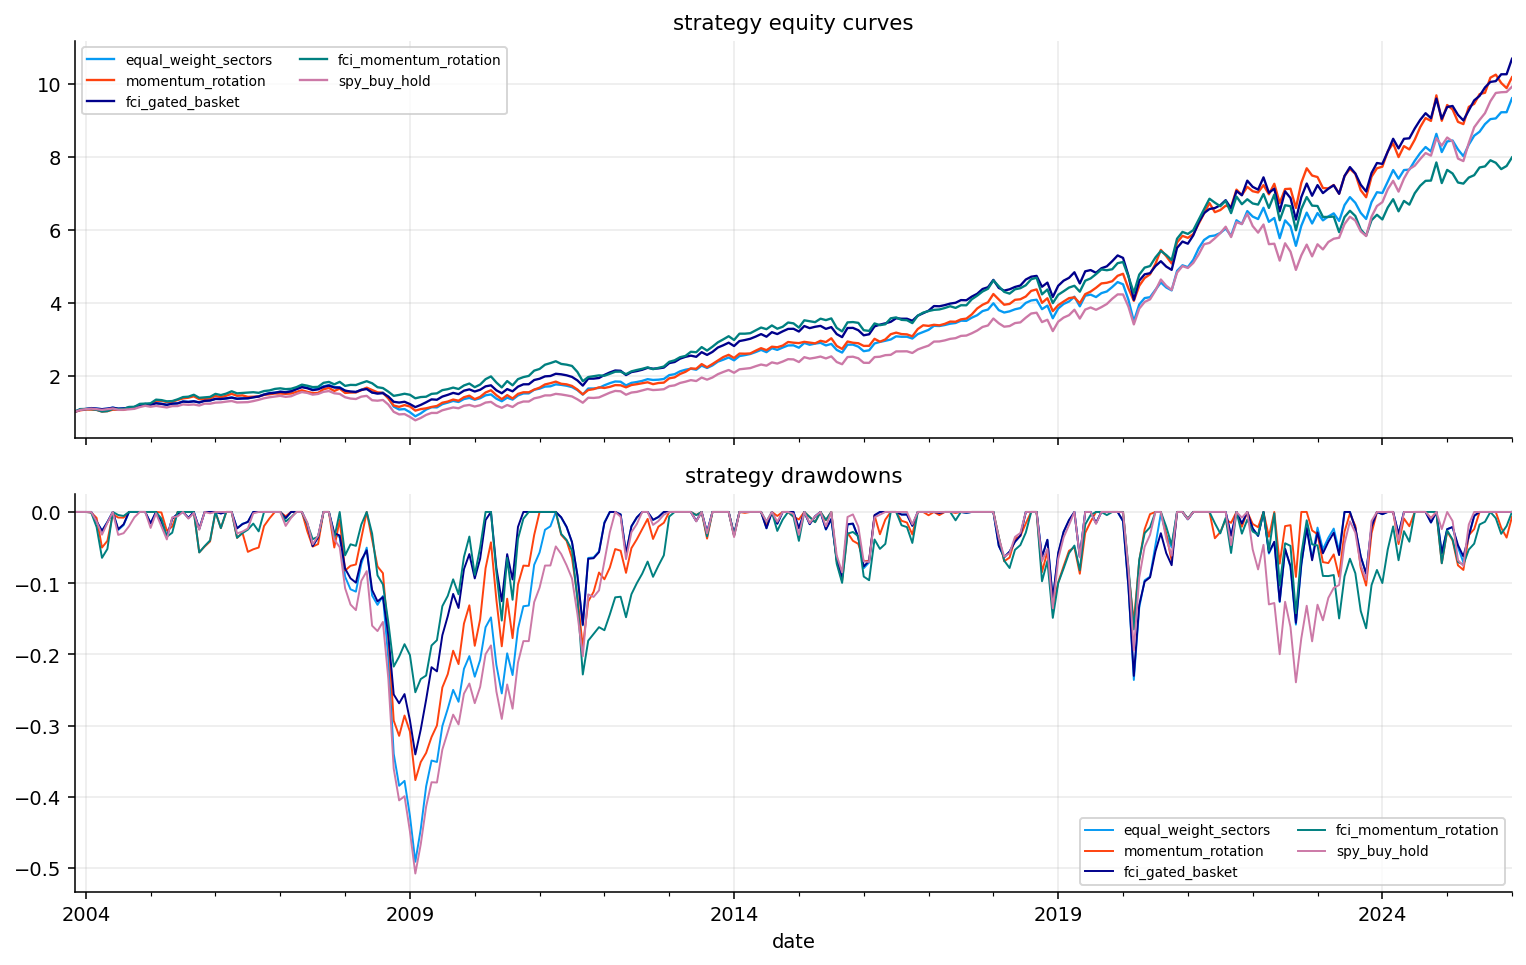

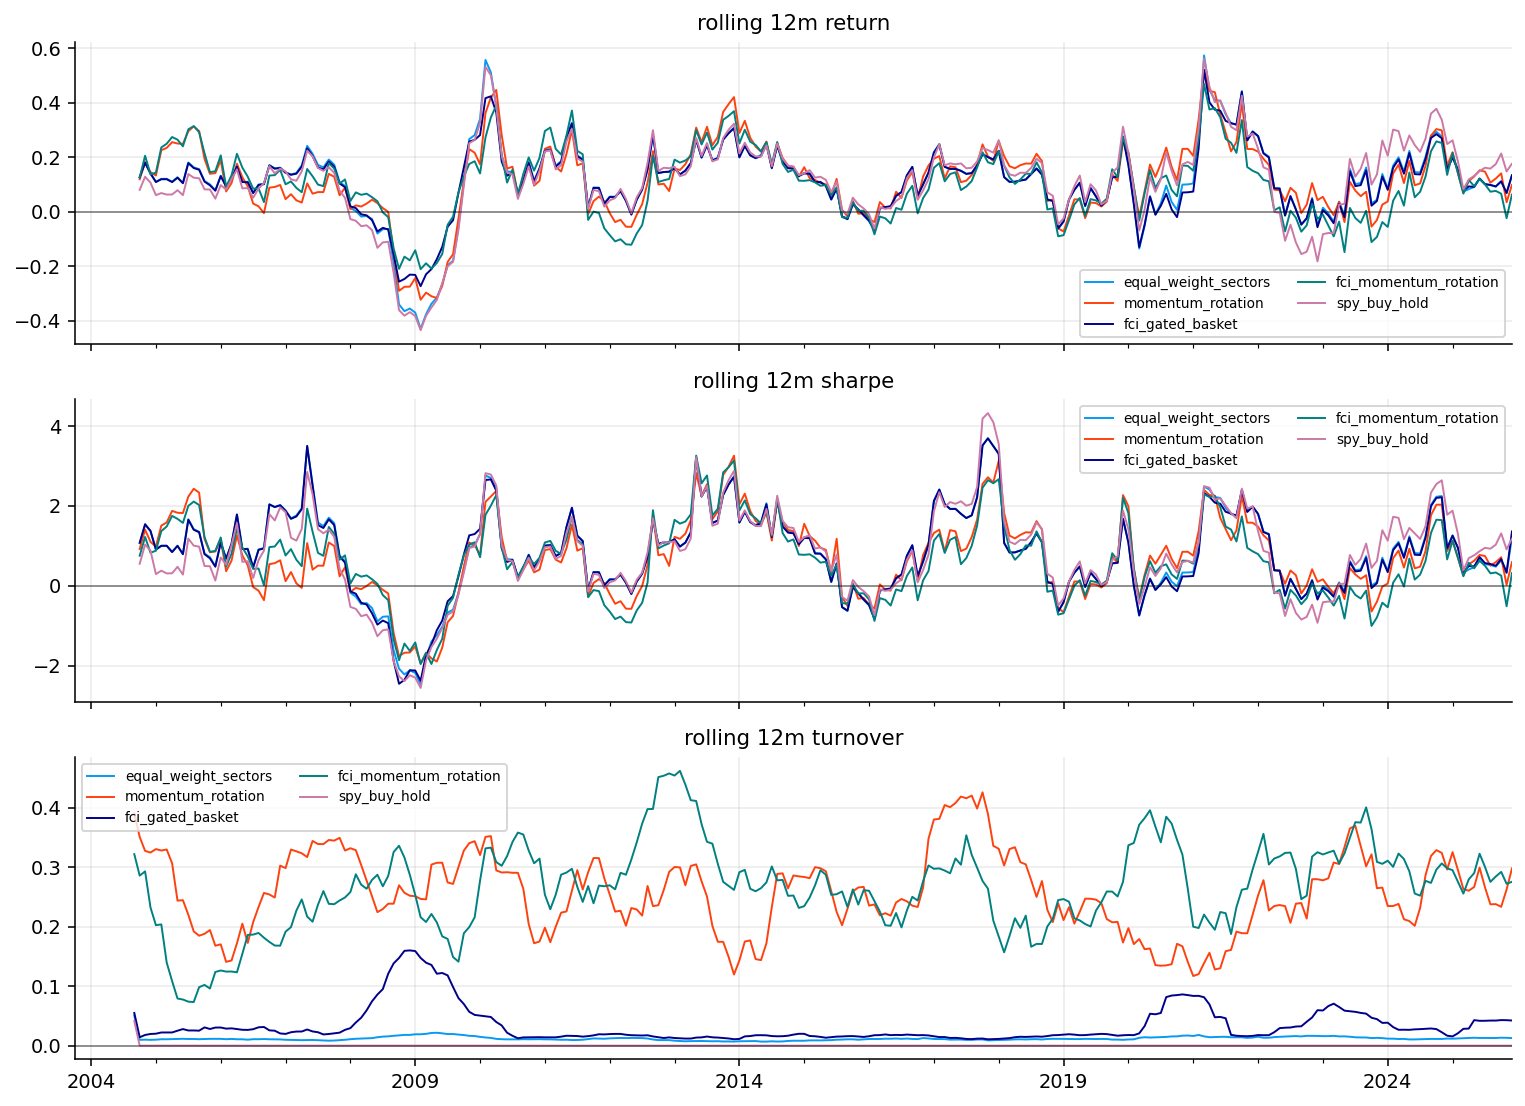

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for j, col in enumerate(strategy_nav_table.columns):
    strategy_nav_table[col].plot(ax=axes[0], lw=1.2, color=colors[j % len(colors)], label=col)
drawdowns = strategy_nav_table.apply(calc_drawdown)
for j, col in enumerate(drawdowns.columns):
    drawdowns[col].plot(ax=axes[1], lw=1.0, color=colors[j % len(colors)], label=col)
axes[0].set_title("strategy equity curves")
axes[1].set_title("strategy drawdowns")
axes[0].legend(ncol=2, fontsize=7)
axes[1].legend(ncol=2, fontsize=7)
for ax in axes:
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for j, col in enumerate(rolling_12m.columns):
    rolling_12m[col].plot(ax=axes[0], lw=1.0, color=colors[j % len(colors)], label=col)
rolling_sharpe = (strategy_return_table - rf_monthly).rolling(12).mean() / strategy_return_table.rolling(12).std() * np.sqrt(12.0)
for j, col in enumerate(rolling_sharpe.columns):
    rolling_sharpe[col].plot(ax=axes[1], lw=1.0, color=colors[j % len(colors)], label=col)
turnover_table = pd.concat({name: result.turnover for name, result in backtest_results.items()}, axis=1)
for j, col in enumerate(turnover_table.columns):
    turnover_table[col].rolling(12).mean().plot(ax=axes[2], lw=1.0, color=colors[j % len(colors)], label=col)
for ax, title in zip(axes, ["rolling 12m return", "rolling 12m sharpe", "rolling 12m turnover"]):
    ax.axhline(0.0, color="black", lw=0.8, alpha=0.5)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()


## 34) Equity Curves, Rolling Metrics, and Turnover

The equity-curve plot shows how the strategies compound through time. The drawdown plot shows where the macro strategies actually add value.

The main visual result is that macro-aware strategies separate most during crisis windows. During calm bull markets, the strategies often move together because they are all mostly invested in risky assets. During 2008, 2020, and 2022, the differences become much larger.

The rolling 12-month return plot shows that FCI momentum sacrifices some upside during strong recoveries. The rolling Sharpe plot shows periods where macro gating improves risk-adjusted performance, especially when volatility rises. The turnover plot shows the cost of rotation: pure momentum and FCI momentum rotate much more than equal-weight or SPY.

Turnover is not just an implementation detail. It is part of the strategy’s economic profile. A strategy with 27% monthly turnover needs enough alpha or risk reduction to justify trading costs. In this project, the 5 bps transaction cost assumption is mild. Higher costs would hurt momentum rotation and FCI momentum more than the FCI-gated basket.


### Stress Windows as Economic Tests

The selected stress windows are not random. They represent different macro shock types.

The **financial crisis** is a credit, housing, labor, and liquidity crisis. A good macro FCI should detect broad stress and reduce risk. The **COVID crash** is a sudden exogenous growth shock with emergency policy easing. A slow macro signal may lag it, so price momentum can matter more. The **inflation/rate shock** is a nominal shock where bonds and equities can fall together. A useful strategy needs inflation-aware defensive assets or sector rotation toward inflation beneficiaries.

This matters because a strategy can look good on average while failing in the specific regime it is supposed to handle. The stress-window table checks whether the strategy works for the right economic reasons.

For example, the FCI momentum strategy does especially well in the financial crisis because broad macro stress was visible and persistent. It helps less in COVID because the shock was too sudden. In 2022, sector momentum and inflation beneficiaries play a major role.


In [55]:
stress_rows = []
for name, dates in crisis_windows.items():
    ret_window = strategy_return_table.loc[dates[0]:dates[1]]
    if len(ret_window) == 0:
        continue
    for strategy in ret_window.columns:
        stress_rows.append({"window": name, "strategy": strategy, "return": float((1.0 + ret_window[strategy]).prod() - 1.0), "max_drawdown": float(drawdown_series(ret_window[strategy], input_kind="returns").min())})
stress_window_table = pd.DataFrame(stress_rows).set_index(["window", "strategy"])
display(stress_window_table.round(4))


return  max_drawdown
window               strategy                                   
financial_crisis     equal_weight_sectors  -0.3713       -0.3599
                     momentum_rotation     -0.2903       -0.2449
                     fci_gated_basket      -0.2115       -0.2031
                     fci_momentum_rotation -0.1479       -0.1165
                     spy_buy_hold          -0.3695       -0.3574
covid_crash          equal_weight_sectors  -0.1227       -0.1455
                     momentum_rotation     -0.0686       -0.0774
                     fci_gated_basket      -0.1193       -0.1401
                     fci_momentum_rotation -0.0674       -0.0948
                     spy_buy_hold          -0.0918       -0.1249
inflation_rate_shock equal_weight_sectors  -0.0619       -0.1583
                     momentum_rotation      0.0152       -0.0912
                     fci_gated_basket      -0.0616       -0.1557
                     fci_momentum_rotation -0.0393       -0.1422
                     spy_buy_hold          -0.1774       -0.2025

## 35) Stress Window Results

The stress-window table is the clearest test of the macro idea.

During the **financial crisis**, SPY loses about **-37.0%**, equal-weight sectors lose about **-37.1%**, and momentum rotation loses about **-29.0%**. The FCI-gated basket loses **-21.2%**, and FCI momentum loses only **-14.8%**. The drawdown reduction is large. This is exactly where a macro stress index should help.

During the **COVID crash**, the shock was extremely fast. FCI-gated loses about **-11.9%**, similar to equal sectors, while momentum and FCI momentum do better, around **-6.9%** and **-6.7%**. The macro system had less time to react because COVID was a sudden event, so price momentum helped more than slow macro gating in that window.

During the **2022 inflation/rate shock**, SPY loses about **-17.7%**, while momentum rotation gains about **1.5%**. FCI momentum loses about **-3.9%**, and equal sectors/gated basket lose about **-6.2%**. This shows that sector selection and inflation-aware rotation were more important than just reducing risk.


In [56]:
latest_date = fci_momentum_weights.index.max()
latest_features = allocation_features.loc[latest_date]
decision_rows = []
for asset in sector_assets + defensive_assets:
    momentum_value = sector_momentum_score.get(asset, pd.Series(0.0, index=strategy_dates)).reindex(strategy_dates).loc[latest_date] if asset in sector_assets else 0.0
    fit_value = macro_fit_score.get(asset, pd.Series(0.0, index=strategy_dates)).loc[latest_date] if asset in sector_assets else 0.0
    support_value = macro_support_score.get(asset, pd.Series(0.0, index=strategy_dates)).loc[latest_date] if asset in sector_assets else 0.0
    penalty_value = recent_risk_penalty.get(asset, pd.Series(0.0, index=strategy_dates)).loc[latest_date] if asset in sector_assets else 0.0
    final_value = final_sector_score.get(asset, pd.Series(0.0, index=strategy_dates)).loc[latest_date] if asset in sector_assets else 0.0
    weight_value = fci_momentum_weights.loc[latest_date, asset] if asset in fci_momentum_weights.columns else 0.0
    if asset in inflation_assets and latest_features["inflation_pressure_block"] > 0.75 and weight_value > 0:
        reason = "inflation hedge"
    elif asset in defensive_assets and latest_features["best_fci_percentile"] > 0.65 and weight_value > 0:
        reason = "defensive stress protection"
    elif asset in rate_sensitive_assets and latest_features["policy_rate_pressure_block"] > 0.75 and fit_value < 0:
        reason = "rate-pressure penalty"
    elif asset in cyclical_sector_assets and latest_features["best_fci_percentile"] < 0.45 and weight_value > 0:
        reason = "risk-on cyclical"
    elif momentum_value < 0 and weight_value <= 1e-8:
        reason = "weak momentum"
    else:
        reason = "macro stress exclusion" if weight_value <= 1e-8 else "risk-on cyclical"
    decision_rows.append({"date": latest_date, "selected fci model": strategy_fci_name, "selected fci value": latest_features["best_fci_value"], "selected fci percentile": latest_features["best_fci_percentile"], "selected fci 3m change": latest_features["best_fci_3m_change"], "dominant macro block": latest_features["dominant_macro_block"], "sector": asset, "momentum_score": momentum_value, "macro_fit_score": fit_value, "macro_support_score": support_value, "recent_risk_penalty": penalty_value, "final_score": final_value, "portfolio_weight": weight_value, "short reason category": reason})
latest_decision_board = pd.DataFrame(decision_rows).sort_values("portfolio_weight", ascending=0)
display(latest_decision_board.round(4))


,date,selected fci model,selected fci value,selected fci percentile,selected fci 3m change,dominant macro block,sector,momentum_score,macro_fit_score,macro_support_score,recent_risk_penalty,final_score,portfolio_weight,short reason category
8,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xly,0.0403,1.1006,-0.5040,-1.7777,0.2848,0.4000,risk-on cyclical
3,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xli,0.7609,0.7068,-0.5040,-1.4127,0.6562,0.3667,risk-on cyclical
4,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xlk,1.4418,-1.1995,-0.5040,3.0926,0.4922,0.2333,risk-on cyclical
2,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xlf,-0.1387,0.7068,-0.5040,-1.4445,0.0730,0.0000,weak momentum
1,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xle,-0.0821,-0.7742,1.7638,1.1999,-0.0918,0.0000,weak momentum
5,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xlp,-1.4599,-0.6888,-0.5040,-0.2562,-1.1243,0.0000,weak momentum
0,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xlb,-0.7140,1.5258,1.7638,0.4703,-0.0060,0.0000,weak momentum
6,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xlu,0.0864,-0.6888,-0.5040,0.5112,-0.1575,0.0000,macro stress exclusion
7,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,xlv,0.0653,-0.6888,-0.5040,-0.3828,-0.1265,0.0000,macro stress exclusion
9,2026-01-31,fci_pca,-0.3795,0.3823,-0.0183,labor_cooling_block,cash,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,macro stress exclusion


## 36) Latest Decision Board

The latest decision board explains the January 2026 allocation. The selected FCI model is **fci_pca**, the selected FCI value is around **-0.38**, and the percentile is about **0.38**. That means the FCI is not tight. The 3-month change is slightly negative, around **-0.018**, so conditions are not rapidly worsening.

The final portfolio weights are:

- **XLY** at 40.0%,
- **XLI** at about 36.7%,
- **XLK** at about 23.3%,
- all defensive assets at zero.

The decision board shows why. XLI has strong momentum and positive final score. XLK has very strong momentum but gets a negative macro-fit score and a high risk penalty, so it receives less than the cap. XLY gets the cap despite modest momentum because its macro fit is strong and recent risk penalty is favorable.

XLF, XLE, XLB, XLP, XLU, and XLV receive zero weights. Some have weak momentum. Some have macro-stress exclusion. The current signal is a concentrated risk-on sector allocation rather than a defensive macro allocation.


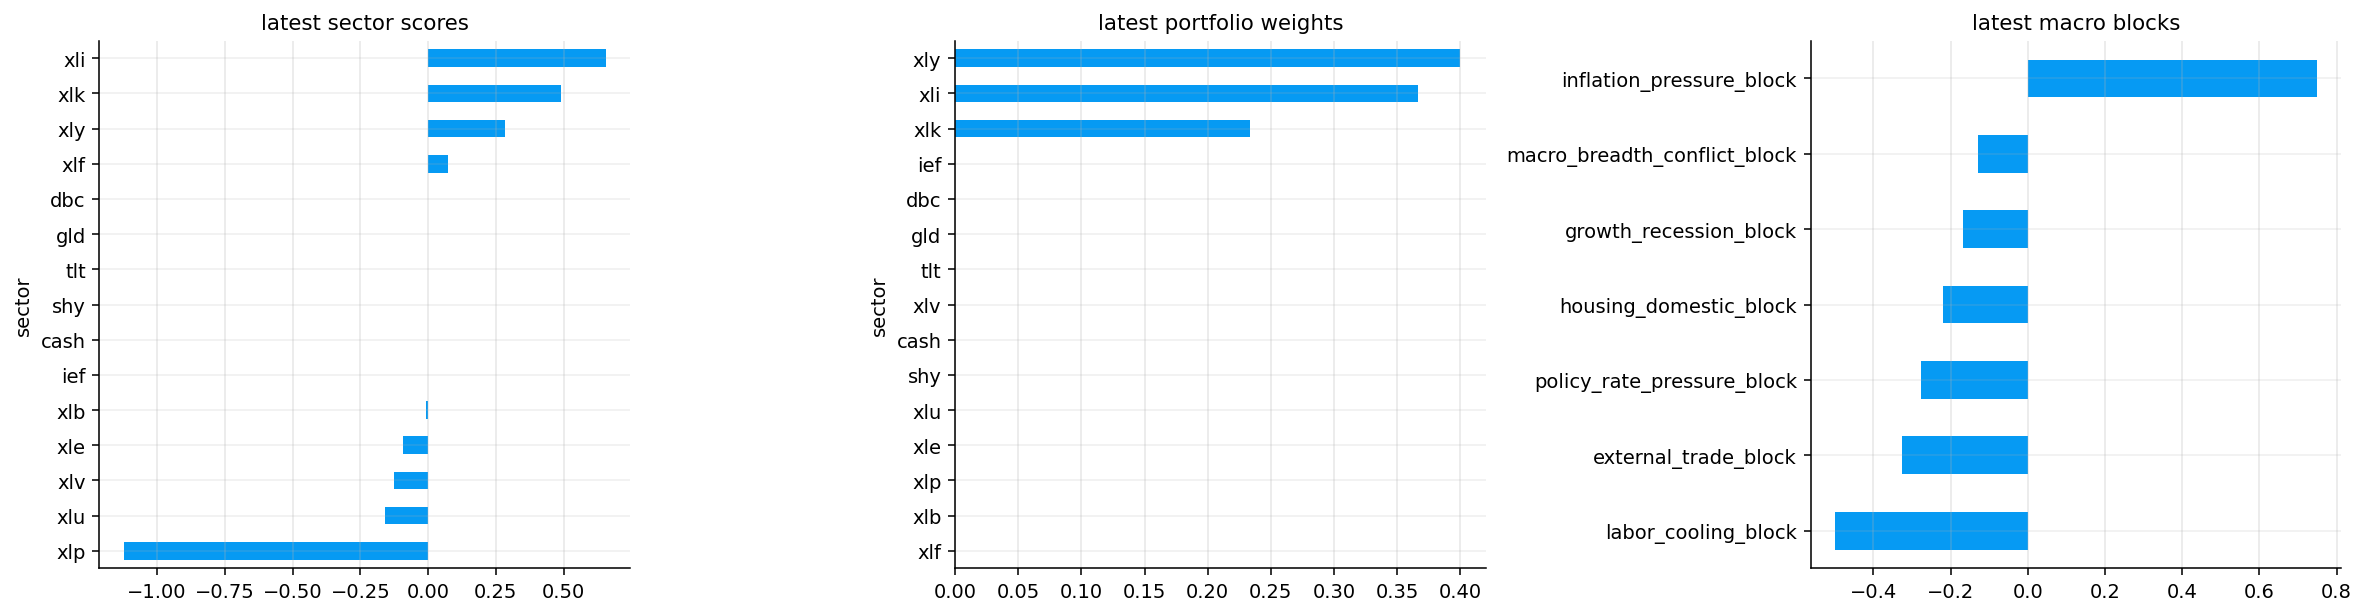

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
latest_decision_board.set_index("sector")["final_score"].sort_values().plot(kind="barh", ax=axes[0])
latest_decision_board.set_index("sector")["portfolio_weight"].sort_values().plot(kind="barh", ax=axes[1])
macro.loc[latest_date, block_cols].sort_values().plot(kind="barh", ax=axes[2])
for ax, title in zip(axes, ["latest sector scores", "latest portfolio weights", "latest macro blocks"]):
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


The latest-score plot confirms the same story visually. The final-score panel ranks the selected sectors above the rest. The portfolio-weight panel shows that the cap binds for XLY, while XLI and XLK receive the remaining risky allocation. The latest macro-block panel shows inflation pressure as the only major positive block, with growth, labor, housing, external trade, and breadth/conflict not showing broad stress.

This is a good example of how the model combines macro and price information. Inflation alone doesn't force a defensive allocation because the selected FCI percentile is not high and the other blocks are not confirming a crisis. Momentum still matters, so the model owns the sectors with the strongest final sector scores.

The risk is concentration. A three-sector portfolio can underperform badly if the macro state changes quickly or if the selected sectors reverse. That concentration is intentional in the strategy design, but it means the strategy should be judged on drawdown, turnover, and stress behavior, not only on average return.


### Reading the US Result Before Moving to Canada

The US run gives a clear hierarchy of ideas.

Macro gating improves the broad sector basket by reducing exposure during tight conditions. Pure momentum improves drawdown relative to equal sectors but rotates heavily. FCI momentum gives the strongest drawdown control but gives up too much return in some risk-on periods. The best overall US balance is the FCI-gated basket because it keeps broad equity participation while reducing exposure when macro stress rises.

The latest US allocation is risk-on because the chosen FCI percentile is not high. The model doesn't move to cash or bonds just because inflation pressure is positive. It waits for broad stress or rising FCI pressure.

That logic is important for the secondary run. In Canada, the same framework may behave differently because commodities and external trade play a larger role. So the secondary application is not just a code-repeat. It tests whether the macro-FCI architecture can adapt to a different economy and sector structure.


## 37) Canada Secondary Application Through the Library

The secondary application repeats the macro-FCI workflow on Canada using the packaged library. This section is important because Canada has a different macro structure from the US.

Canada is more commodity-sensitive, more externally exposed, and more concentrated by sector. Financials, energy, materials, real estate, utilities, staples, and technology play different roles than US sectors. The Canadian economy is also sensitive to global commodity prices, housing, the Canadian dollar, and US demand.

The Canada workflow uses Canadian macro factors, Canadian sector ETFs, broad Canadian equity ETFs, Canadian bond and gold ETFs, and some global signal assets like FXC, UUP, HYG, LQD, and SPY. The data can be reproduced from the corresponding folders inside the repo’s [data folder](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data), especially the Canada macro, Canada sector ETF, core cross-asset, and international hedging ETF folders.

The important point is that the same macro language carries over: inflation pressure, policy pressure, growth recession, labor cooling, housing, external trade, breadth/conflict, FCI models, model scoring, and macro-gated allocation.


### Canadian Asset Roles

The Canadian tradable universe has a very different economic composition:

| ETF | Economic role |
|---|---|
| **XIC.TO / XIU.TO** | Broad Canadian equity exposure |
| **XFN.TO** | Canadian financials, heavily tied to banks, credit, housing, and yield-curve conditions |
| **XEG.TO** | Energy, tied to oil and global commodity cycles |
| **XMA.TO** | Materials, tied to metals, mining, and global industrial demand |
| **XRE.TO** | Real estate, sensitive to rates and Canadian housing conditions |
| **XUT.TO** | Utilities, defensive but rate-sensitive |
| **XST.TO** | Staples, defensive consumption |
| **XIT.TO** | Technology, growth-oriented but smaller and more concentrated than US tech |
| **XSB.TO / XBB.TO / XLB.TO** | short, aggregate, and long Canadian bonds |
| **CGL-C.TO** | Canadian gold exposure, useful for commodity/inflation stress |

This market is a great secondary test because macro conditions should affect sectors differently than in the US. Energy and materials have much larger macro importance, while financials are deeply connected to domestic credit and housing.


,missing_share_in_strategy_window
CGL-C.TO,0.0
XBB.TO,0.0
XEG.TO,0.0
XFN.TO,0.0
XIC.TO,0.0
XIT.TO,0.0
XLB.TO,0.0
XMA.TO,0.0
XRE.TO,0.0
XSB.TO,0.0


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,final_score
model,,,,,,,,,
fci_blend,168,2012-02-29,2026-01-31,0.2318,0.0121,0.7,0.0470,0.5224,0.7125
fci_prob,134,2014-12-31,2026-01-31,0.2506,0.0150,0.3,0.0379,0.5354,0.6125
fci_pls,179,2011-03-31,2026-01-31,0.1700,0.0115,0.4,0.0186,0.8007,0.4250
fci_econ,375,1994-11-30,2026-01-31,0.1221,0.0096,0.5,0.0407,0.6340,0.3875
fci_pca,328,1998-10-31,2026-01-31,0.0624,0.0076,0.9,0.0428,0.6052,0.3625


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,final_score
model,,,,,,,,,
fci_pls,58,2021-04-30,2026-01-31,0.5311,0.0248,1.0,0.0715,0.8417,0.9000
fci_prob,58,2021-04-30,2026-01-31,0.4718,0.0301,0.7,0.0996,0.6297,0.7750
fci_blend,58,2021-04-30,2026-01-31,0.1819,0.0094,0.4,0.0339,0.6595,0.4625
fci_econ,58,2021-04-30,2026-01-31,0.0717,0.0038,0.1,0.0419,0.6387,0.2875
fci_pca,58,2021-04-30,2026-01-31,-0.2349,-0.0150,-0.5,-0.0098,0.7441,0.0750


,full_sample_score_winner,test_sample_score_winner,selected_strategy_fci,selection_rule
0,fci_blend,fci_pls,fci_blend,Best history-eligible FCI selected from the fu...


,strategy_start,strategy_end,strategy_fci,test_start
0,2012-07-31,2026-01-31,fci_blend,2021-04-30


,cagr,vol,sharpe,max_drawdown,calmar,sortino,turnover
Strategy,,,,,,,
equal_weight_sectors,0.1324,0.1297,0.6794,-0.2288,0.5789,0.7794,0.0204
momentum_rotation,0.1340,0.1311,0.6985,-0.1961,0.6834,0.8124,0.2034
fci_gated_basket,0.1167,0.1154,0.6260,-0.2235,0.5220,0.6813,0.1104
fci_momentum_rotation,0.1317,0.1161,0.7551,-0.1912,0.6891,0.8589,0.2189
xic_buy_hold,0.1279,0.1279,0.6612,-0.2248,0.5691,0.7522,0.0042


,date,selected fci model,selected fci value,selected fci percentile,selected fci 3m change,dominant macro block,sector,momentum_score,macro_fit_score,macro_support_score,recent_risk_penalty,final_score,portfolio_weight,short reason category
0,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XFN.TO,0.9797,0.3629,-0.5855,-1.5112,0.7264,0.3962,risk-on cyclical
1,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XEG.TO,-0.2198,0.9218,1.4639,0.6933,0.1532,0.3267,risk-on cyclical
2,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XMA.TO,1.3883,0.9218,1.4639,-0.1263,1.2394,0.2675,risk-on cyclical
8,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XBB.TO,0.0000,0.0000,0.0000,0.0000,0.0000,0.0048,risk-on cyclical
7,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XSB.TO,0.0000,0.0000,0.0000,0.0000,0.0000,0.0048,risk-on cyclical
3,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XRE.TO,-0.6542,0.2490,-0.5855,-1.7426,-0.3468,0.0000,weak momentum
4,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XUT.TO,-0.4619,-1.4091,-0.5855,-0.6682,-0.6072,0.0000,weak momentum
6,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XIT.TO,-0.6786,0.3641,-0.5855,2.7555,-0.5646,0.0000,weak momentum
5,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XST.TO,-0.3535,-1.4103,-0.5855,0.5995,-0.6004,0.0000,weak momentum
9,2026-01-31,fci_blend,-0.6248,0.3353,0.0716,external_trade_block,XLB.TO,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,macro stress exclusion


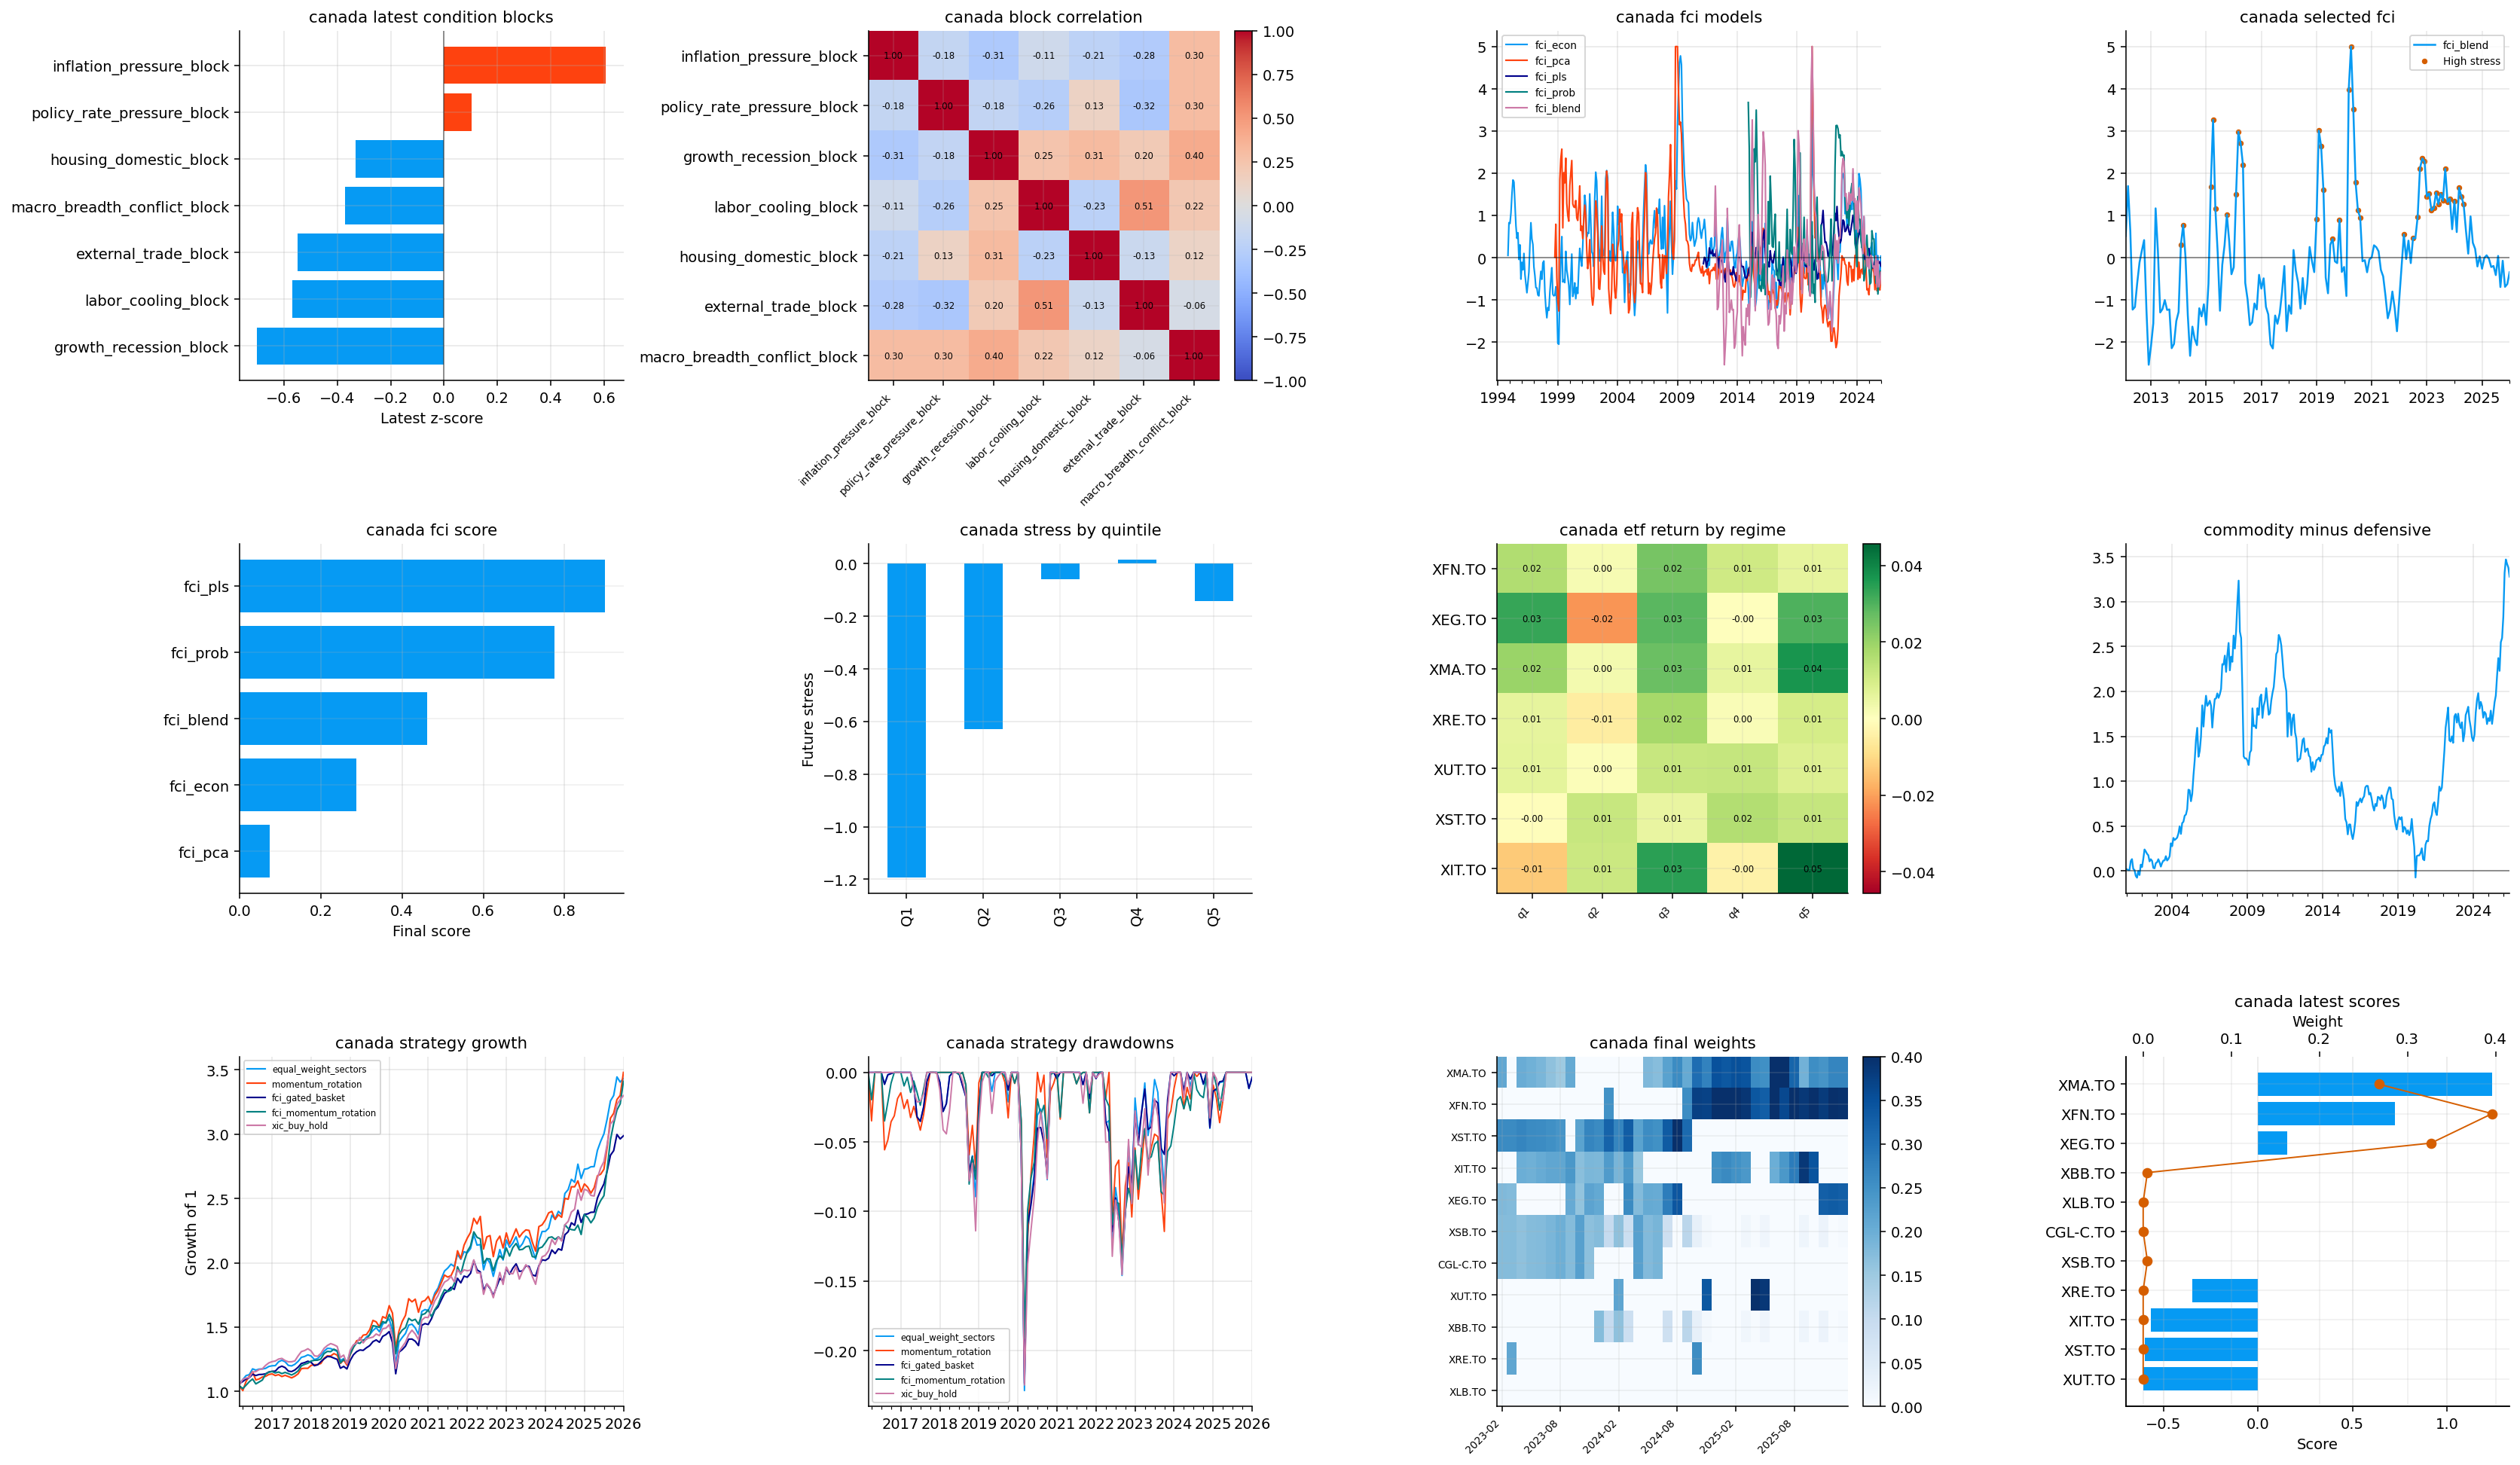

In [58]:
from quantfinlab.dataio import load_macro_factors, load_yfinance_panel
from quantfinlab.portfolio import prices_to_returns
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.portfolio.selection import build_metrics_table, build_trade_table
from quantfinlab.macro.indicators import inflation_level_pressure, inflation_impulse, inflation_acceleration, inflation_diffusion, policy_tightness, policy_shock, real_rate_squeeze, policy_catchup_risk, growth_momentum_stress, growth_acceleration_stress, growth_breadth_stress, survey_warning, labor_cooling, sahm_pressure, housing_impulse_stress, housing_rate_squeeze, external_demand_stress, external_vulnerability, stress_breadth, severe_stress_breadth, stagflation_pressure, goldilocks_support, inflation_pressure_block, policy_rate_pressure_block, growth_recession_block, labor_cooling_block, housing_domestic_block, external_trade_block, macro_breadth_conflict_block
from quantfinlab.macro.models import economic_fci, pca_fci, targeted_pls_fci, stress_probability_fci, blended_fci, fci_percentile, fci_change, future_stress_target, fci_quintile_report, fci_model_scores
from quantfinlab.macro.allocation import equal_sector_weights, momentum_sector_weights, fci_gated_weights, fci_momentum_weights, latest_decision_table
from quantfinlab.plotting.macro import plot_macro_blocks, plot_block_correlation, plot_fci_models, plot_fci_vs_nfci, plot_fci_model_scores, plot_fci_quintile_stress, plot_sector_regime_heatmap, plot_defensive_cyclical_spread, plot_strategy_growth, plot_strategy_drawdowns, plot_strategy_weights, plot_latest_scores

factors = load_macro_factors("../data/canada_macro_factors.csv")
etf_paths = ["../data/canada_sector_etfs.csv", "../data/core_cross_asset_etfs.csv", "../data/international_hedging_etfs.csv"]
min_history = 48
inflation = pd.concat([
    inflation_level_pressure(factors, min_history=min_history),
    inflation_impulse(factors, min_history=min_history),
    inflation_acceleration(factors, min_history=min_history),
    inflation_diffusion(factors, min_history=min_history),
], axis=1)
policy = pd.concat([
    policy_tightness(factors, min_history=min_history),
    policy_shock(factors, min_history=min_history),
], axis=1)
policy["real_rate_squeeze"] = real_rate_squeeze(policy["policy_tightness"], inflation["inflation_impulse"], min_history=min_history)
policy["policy_catchup_risk"] = policy_catchup_risk(inflation["inflation_level_pressure"], policy["policy_tightness"], min_history=min_history)
growth = pd.concat([
    growth_momentum_stress(factors, min_history=min_history),
    growth_acceleration_stress(factors, min_history=min_history),
    growth_breadth_stress(factors, min_history=min_history),
    survey_warning(factors, min_history=min_history),
], axis=1)
labor = pd.concat([
    labor_cooling(factors, min_history=min_history),
    sahm_pressure(factors, min_history=min_history),
], axis=1)
housing = pd.concat([
    housing_impulse_stress(factors, min_history=min_history),
], axis=1)
housing["housing_rate_squeeze"] = housing_rate_squeeze(housing["housing_impulse_stress"], policy["policy_tightness"])
external = pd.concat([
    external_demand_stress(factors, min_history=min_history),
    external_vulnerability(factors, min_history=min_history),
], axis=1)
signals = pd.concat([inflation, policy, growth, labor, housing, external], axis=1)
breadth = pd.concat([
    stress_breadth(signals, min_history=min_history),
    severe_stress_breadth(signals, min_history=min_history),
    stagflation_pressure(signals),
    goldilocks_support(signals),
], axis=1)
signals = pd.concat([signals, breadth], axis=1)
blocks = pd.concat([
    inflation_pressure_block(signals),
    policy_rate_pressure_block(signals),
    growth_recession_block(signals),
    labor_cooling_block(signals),
    housing_domestic_block(signals),
    external_trade_block(signals),
    macro_breadth_conflict_block(signals),
], axis=1)
macro = pd.concat([signals, blocks], axis=1)
macro["n_blocks_available"] = blocks.notna().sum(axis=1)
macro = macro.loc[macro["n_blocks_available"] >= 5]
blocks = macro[blocks.columns]
risky_assets = ["XFN.TO", "XEG.TO", "XMA.TO", "XRE.TO", "XUT.TO", "XST.TO", "XIT.TO"]
defensive_assets = ["XSB.TO", "XBB.TO", "XLB.TO", "CGL-C.TO"]
signal_assets = ["FXC", "UUP", "HYG", "LQD", "SPY"]
tickers = ["XIC.TO", "XIU.TO"] + risky_assets + defensive_assets + signal_assets
prices = load_yfinance_panel(etf_paths, fields=("close",), tickers=tickers, lowercase=False)["close"].ffill(limit=3)
monthly_prices = prices.groupby(prices.index.to_period("M")).last()
monthly_prices.index = monthly_prices.index.to_timestamp("M")
returns_raw = prices_to_returns(monthly_prices, kind="simple")
returns = returns_raw.copy()
target = future_stress_target(returns_raw, asset="XIC.TO", min_history=min_history).reindex(macro.index.union(returns_raw.index)).sort_index()
fci_econ = economic_fci(blocks, min_history=min_history).rename("fci_econ")
fci_pca = pca_fci(blocks, min_history=min_history, min_blocks=5).rename("fci_pca")
fci_pls = targeted_pls_fci(blocks, target["future_stress"], min_history=min_history, n_components=1, min_blocks=5, embargo_months=3).rename("fci_pls")
prob = stress_probability_fci(pd.concat([blocks, fci_econ, fci_pca, fci_pls], axis=1), target["future_stress"], min_history=min_history, embargo_months=3).rename(columns=str.lower)
fci_blend = blended_fci(fci_pls, fci_pca, fci_econ, min_history=12).rename("fci_blend")
fci_models = pd.concat([fci_econ, fci_pca, fci_pls, prob["fci_prob_z"].rename("fci_prob"), fci_blend], axis=1).reindex(macro.index)
full_scoreboard = fci_model_scores(fci_models, target)
all_assets = sorted(set(risky_assets + defensive_assets + ["XIC.TO"]))
first_month = monthly_prices[all_assets].apply(pd.Series.first_valid_index)
start_date = max(macro.index.min(), first_month.max() + pd.offsets.MonthEnd(6))
score_dates = fci_models.index.intersection(returns_raw.index)
score_dates = score_dates[score_dates >= start_date]
split_date = score_dates[int(len(score_dates) * 0.65)] if len(score_dates) else pd.NaT
test_dates = score_dates[score_dates >= split_date]
scoreboard = fci_model_scores(fci_models.reindex(test_dates), target.reindex(test_dates))
history_eligible = full_scoreboard[(full_scoreboard["observations"] >= 120) & (full_scoreboard["first_valid_date"] <= pd.Timestamp("2013-12-31"))]
best_name = history_eligible.index[0] if len(history_eligible) else "fci_pca"
canada_model_choice_table = pd.DataFrame({"full_sample_score_winner": [full_scoreboard.index[0]], "test_sample_score_winner": [scoreboard.index[0]], "selected_strategy_fci": [best_name], "selection_rule": ["Best history-eligible FCI selected from the full-sample scoreboard with at least 120 observations and first valid date no later than 2013-12-31."]})
best_fci = fci_models[best_name].rename(best_name)
best_pct = fci_percentile(best_fci, min_history=min_history).rename("best_fci_percentile")
best_change = fci_change(best_fci, periods=3).rename("best_fci_3m_change")
tradable_macro = macro.shift(1)
features = tradable_macro[["inflation_pressure_block", "policy_rate_pressure_block", "growth_recession_block", "macro_breadth_conflict_block", "goldilocks_support"]].copy()
features["best_fci_percentile"] = best_pct.shift(1)
features["best_fci_3m_change"] = best_change.shift(1)
features["best_fci_value"] = best_fci.shift(1)
dominant_block_values = tradable_macro[blocks.columns].abs()
dominant_macro_block = pd.Series(np.nan, index=dominant_block_values.index, dtype=object)
has_dominant_block = dominant_block_values.notna().any(axis=1)
dominant_macro_block.loc[has_dominant_block] = dominant_block_values.loc[has_dominant_block].idxmax(axis=1)
features["dominant_macro_block"] = dominant_macro_block
features = features.dropna(subset=["best_fci_percentile", "best_fci_3m_change"])
strategy_end = min(features.index.max(), returns_raw.index.max())
dates = features.index.intersection(returns_raw.index)
dates = dates[(dates >= start_date) & (dates <= strategy_end)]
equal_weight = equal_sector_weights(dates, risky_assets, all_assets)
momentum_weight = momentum_sector_weights(returns, risky_assets).reindex(dates).reindex(columns=all_assets).fillna(0.0)
gated_weight, gated_details = fci_gated_weights(features.reindex(dates), risky_assets, defensive_assets, return_details=True)
fci_momentum_weight, details = fci_momentum_weights(returns, features.reindex(dates), risky_assets, defensive_assets, return_details=True)
benchmark_weight = equal_weight.copy() * 0.0
benchmark_weight["XIC.TO"] = 1.0
weights_by_strategy = {"equal_weight_sectors": equal_weight, "momentum_rotation": momentum_weight, "fci_gated_basket": gated_weight, "fci_momentum_rotation": fci_momentum_weight, "xic_buy_hold": benchmark_weight}
strategy_returns = returns_raw.loc[dates.min():strategy_end, all_assets]
missing_share = strategy_returns.isna().mean()
display(missing_share.to_frame("missing_share_in_strategy_window"))
strategy_returns = strategy_returns.fillna(0.0)
results = run_many_weights_backtests(weights_by_strategy, returns=strategy_returns, cost_bps=5.0, weight_timing="next_close")
performance = build_metrics_table(results, rf_daily=rf_monthly, annualization=12.0)
trades = build_trade_table(results)
performance.columns = [str(col).lower().replace(" ", "_") for col in performance.columns]
trades.columns = [str(col).lower().replace(" ", "_") for col in trades.columns]
performance["turnover"] = trades["avg_turnover"]
nav = pd.concat({name: result.net_values for name, result in results.items()}, axis=1)
quintile_report = fci_quintile_report(best_fci, target)
regime_data = pd.concat([best_pct.rename("fci_percentile"), returns[risky_assets].shift(-1)], axis=1).dropna(subset=["fci_percentile"])
regime_data["fci_quintile"] = pd.qcut(regime_data["fci_percentile"].rank(method="first"), 5, labels=["q1", "q2", "q3", "q4", "q5"])
regime_heatmap = regime_data.groupby("fci_quintile", observed=False)[risky_assets].mean()
spread = (1.0 + returns[["XEG.TO", "XMA.TO"]].mean(axis=1).sub(returns[defensive_assets].mean(axis=1), fill_value=0.0)).cumprod() - 1.0
decision = latest_decision_table(features.reindex(dates), fci_momentum_weight, details, selected_fci_model=best_name)
display(full_scoreboard.round(4))
display(scoreboard.round(4))
display(canada_model_choice_table)
display(pd.DataFrame({"strategy_start": [start_date], "strategy_end": [strategy_end], "strategy_fci": [best_name], "test_start": [split_date]}))
display(performance.round(4))
display(decision.round(4))
fig, axes = plt.subplots(3, 4, figsize=(24, 14))
ax = axes.ravel()
plot_macro_blocks(macro, ax=ax[0], title="canada latest condition blocks")
plot_block_correlation(macro, ax=ax[1], title="canada block correlation")
plot_fci_models(fci_models, ax=ax[2], title="canada fci models")
plot_fci_vs_nfci(best_fci, ax=ax[3], title="canada selected fci")
plot_fci_model_scores(scoreboard, ax=ax[4], title="canada fci score")
plot_fci_quintile_stress(quintile_report, ax=ax[5], title="canada stress by quintile")
plot_sector_regime_heatmap(regime_heatmap.transpose(), ax=ax[6], title="canada etf return by regime")
plot_defensive_cyclical_spread(spread, ax=ax[7], title="commodity minus defensive")
plot_strategy_growth(nav, ax=ax[8], title="canada strategy growth")
plot_strategy_drawdowns(nav, ax=ax[9], title="canada strategy drawdowns")
plot_strategy_weights(fci_momentum_weight, ax=ax[10], title="canada final weights")
plot_latest_scores(decision, ax=ax[11], title="canada latest scores")
plt.tight_layout()
plt.show()


The Canada latest block chart shows inflation pressure positive and most other blocks negative. External trade is the dominant macro block in the latest decision table. That makes sense for Canada because external demand and commodity-linked trade matter more than they do for the US.

The Canada block correlation matrix also differs from the US. External trade is more connected to labor cooling, and macro breadth/conflict relates to inflation, policy, and growth. This means a Canadian FCI can’t just be a copy of a US FCI with different tickers. The same methodology is reusable, but the economic interpretation has to be country-specific.

The Canada FCI plot shows very large spikes around the global financial crisis, 2020, and the post-2021 period. The selected FCI is the blend, which has enough history and strong full-sample score.


### Why External Trade Matters More in Canada

External trade has a bigger role in the Canadian application because Canada is more exposed to commodities and foreign demand. Energy and materials are not small satellite sectors; they are core parts of the equity market and national income cycle.

A commodity upswing can improve trade income, support energy/materials earnings, strengthen the currency, and attract capital into Canadian equities. A commodity downturn can do the opposite. This means external trade pressure and commodity-sensitive sector returns are more tightly linked than in the US.

The Canada latest decision table shows **external_trade_block** as the dominant macro block. That doesn't mean the economy is in trade stress; the selected FCI percentile is low. It means the largest absolute macro signal at the latest date comes from the external-trade side. In a Canadian allocation problem, that is exactly the kind of information we want to preserve.

This is also why the secondary run uses international hedging ETFs and global signal assets. Currency and global risk appetite matter more when the local equity market is tied closely to commodities and external demand.


## 38) Canada FCI Model Scores

The full-sample Canada scoreboard ranks **fci_blend** first with a final score around **0.713**. It has a future-stress rank IC around **0.232**, drawdown spread around **0.012**, and volatility spread around **0.047**. The probability FCI is second, with a higher rank IC around **0.251** but lower monotonicity and stability.

The test-sample scoreboard ranks **fci_pls** first with a very high score around **0.900**, followed by fci_prob around **0.775**. This tells us supervised models worked very well in the recent Canada sample. But the strategy selects **fci_blend**, because it is history-eligible and wins the full-sample rule.

That choice is sensible. Canada has fewer independent macro cycles in the tradable ETF sample, and the supervised models can become very sample-dependent after 2021. A blended FCI keeps the supervised information but anchors it with PCA and economic weighting.

The strategy starts in **July 2012** and runs to **January 2026**. This window includes the commodity crash, COVID, the 2022 rate/inflation shock, and the 2023–2025 rebound.


### Why the Canada Model Can Reward Cyclicals Under Easy FCI

When the selected Canada FCI percentile is low, the model does not need a large defensive sleeve. In that state, the main allocation problem becomes sector selection. Canada’s cyclical sectors are not interchangeable.

Financials, energy, and materials respond to different macro channels. Financials care about credit quality, housing, and rate margins. Energy cares about oil and global commodity demand. Materials care about metals, mining, global industrial demand, and sometimes China-sensitive growth expectations. When external trade is the dominant macro block and FCI is easy, the model can reasonably prefer XFN, XEG, and XMA at the same time.

The final sector score still keeps momentum at the center, so macro support alone cannot force a sector into the portfolio. That is why XEG can be selected despite weaker momentum: it receives enough macro fit and support. XMA has strong momentum and macro support, so it becomes a very natural holding. XFN has strong momentum and favorable risk penalty, so it gets the largest weight.

This interaction between macro fit and momentum is the main reason the Canada FCI momentum strategy performs better than a simple gated basket.


## 39) Canada Strategy Results

The Canada performance table is strong. The best risk-adjusted strategy is **fci_momentum_rotation**, with:

- CAGR around **13.17%**,
- volatility around **11.61%**,
- Sharpe around **0.755**,
- max drawdown around **-19.12%**,
- Sortino around **0.859**.

Momentum rotation has the highest CAGR at about **13.40%**, but it has slightly higher volatility and lower Sharpe. Equal-weight sectors and XIC buy-and-hold are also strong, but they have larger drawdowns, around **-22% to -23%**.

The FCI-gated basket is more defensive, with lower volatility but also lower CAGR. In Canada, combining FCI with momentum works better than gating alone because sector selection matters a lot. Energy, materials, financials, and technology can diverge strongly depending on commodity and external-demand regimes.

This is an important contrast with the US run. In the US, the FCI-gated basket was the cleanest overall Sharpe improvement. In Canada, FCI momentum is stronger because macro conditions map more directly into sector leadership.


The latest Canada decision board selects **XFN.TO**, **XEG.TO**, and **XMA.TO**, with small residual weights in XBB.TO and XSB.TO. The selected FCI model is **fci_blend**, with value around **-0.625** and percentile around **0.335**. Conditions are relatively easy, and the 3-month change is small positive.

The portfolio weights are:

- **XFN.TO** about **39.6%**,
- **XEG.TO** about **32.7%**,
- **XMA.TO** about **26.8%**,
- small bond weights around **0.5%** each for XBB and XSB.

This is a risk-on, commodity/cyclical Canadian allocation. XFN has strong momentum and favorable risk penalty. XMA has very strong momentum and strong macro fit. XEG has weaker momentum but strong macro support and macro fit because energy benefits from inflation/commodity sensitivity. XRE, XUT, XST, and XIT are excluded mainly because their momentum and final scores are weaker.


### Canada Macro Interpretation

The Canada return-by-regime heatmap shows that sector leadership changes with the FCI. Energy and materials can perform well even when some stress measures are elevated, because commodity-linked sectors benefit from certain inflation and external-demand regimes. Financials can also lead when conditions are easy and credit remains stable.

The commodity-minus-defensive plot rises strongly in commodity-friendly periods, especially after 2020. That explains why a macro-aware Canada strategy needs commodity interpretation. A generic defensive/risk-on split is not enough. In Canada, energy and materials can act like macro assets, not just equity sectors.

The Canada strategy growth and drawdown plots show that fci_momentum_rotation controls drawdowns while keeping strong upside participation. The latest weights plot shows a clear move toward materials, financials, and energy in the recent period, with less reliance on defensive bonds or gold.

That secondary result strengthens the project. The same FCI architecture works in another market, but the economic content changes. In the US, the strategy mainly uses macro stress to gate sector risk. In Canada, the FCI also helps identify commodity-linked leadership.


### Canada Compared With the US Allocation Problem

The US sector universe is broad and dominated by technology, health care, financials, discretionary, and other large diversified sectors. Canada is more concentrated. Financials, energy, and materials carry much more macro meaning. This changes how we interpret the same FCI machinery.

In the US, inflation pressure may support energy and materials, but those sectors are not always large enough to define the whole market. In Canada, energy and materials are central. External trade and commodity prices affect not only sector returns but also the currency, national income, and investor perception of the whole equity market.

This is why the Canada latest allocation toward XFN, XEG, and XMA is economically coherent. It says the macro state is not broadly stressed, external trade is the dominant block, and commodity/cyclical sectors have enough momentum or macro fit to lead.

The Canadian strategy result also shows that macro-aware momentum can work better when macro regimes map clearly into sector leadership. Energy and materials are not just cyclical sectors here; they are macro transmission assets.


### Ending the Project at the Secondary Analysis

The Canada implementation closes the workflow by showing the full macro pipeline in a second economy: macro signals, blocks, FCI models, model scoring, regime interpretation, allocation, backtest, and latest decision diagnostics.

The central lesson is that macro modeling becomes useful when it stays interpretable. We can see whether stress comes from inflation, policy, growth, labor, housing, external trade, or breadth. We can compare different index-construction methods. We can test whether high FCI readings actually lead to worse future market conditions. Then we can translate the result into portfolio decisions with clear allocation rules.

For this project, the strongest parts are the block construction, the model comparison, and the sector/regime interpretation. The macro data doesn't give a perfect forecast, but it gives a structured regime map that pure price momentum and static sector allocation don't have.
